In [2]:
%load_ext autoreload
%autoreload 2
from trainingTools import NFTrainer, loadData, loadMeans
import helper_functions as hf
from functools import partial
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import h5py
#torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Background

Loading train sample


  0%|          | 0/80 [00:00<?, ?it/s]


100000 training events
Training flow BKG_noRho
Iteration 10 Complete
Loss:  14.192405700683594
Iteration 20 Complete
Loss:  13.13388729095459
Iteration 30 Complete
Loss:  12.732657432556152
Iteration 40 Complete
Loss:  12.5918550491333
Iteration 50 Complete
Loss:  12.491094589233398
Iteration 60 Complete
Loss:  12.424714088439941
Iteration 70 Complete
Loss:  12.357158660888672
Iteration 80 Complete
Loss:  12.349513053894043
Iteration 90 Complete
Loss:  12.28481674194336
Iteration 100 Complete
Loss:  12.13991641998291
Iteration 110 Complete
Loss:  12.039332389831543
Iteration 120 Complete
Loss:  11.932552337646484
Iteration 130 Complete
Loss:  11.847565650939941
Iteration 140 Complete
Loss:  11.803287506103516
Iteration 150 Complete
Loss:  11.753583908081055
Iteration 160 Complete
Loss:  11.75130844116211
Iteration 170 Complete
Loss:  11.792403221130371
Loading test sample


  4%|▍         | 3/80 [00:03<01:19,  1.03s/it]


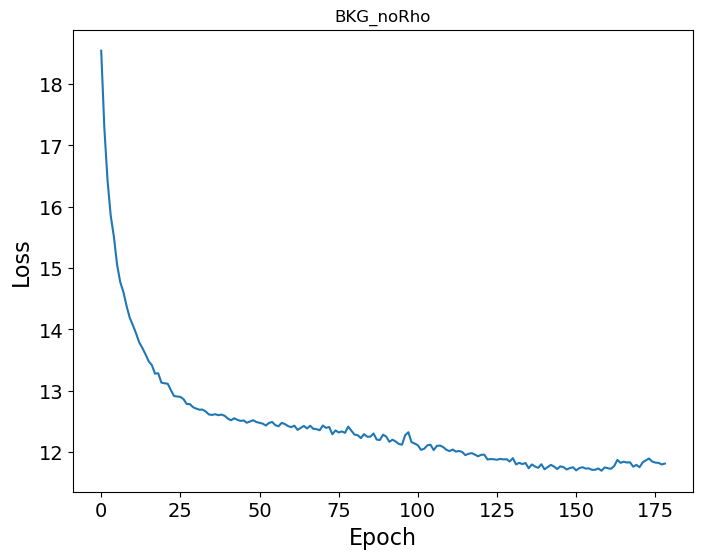

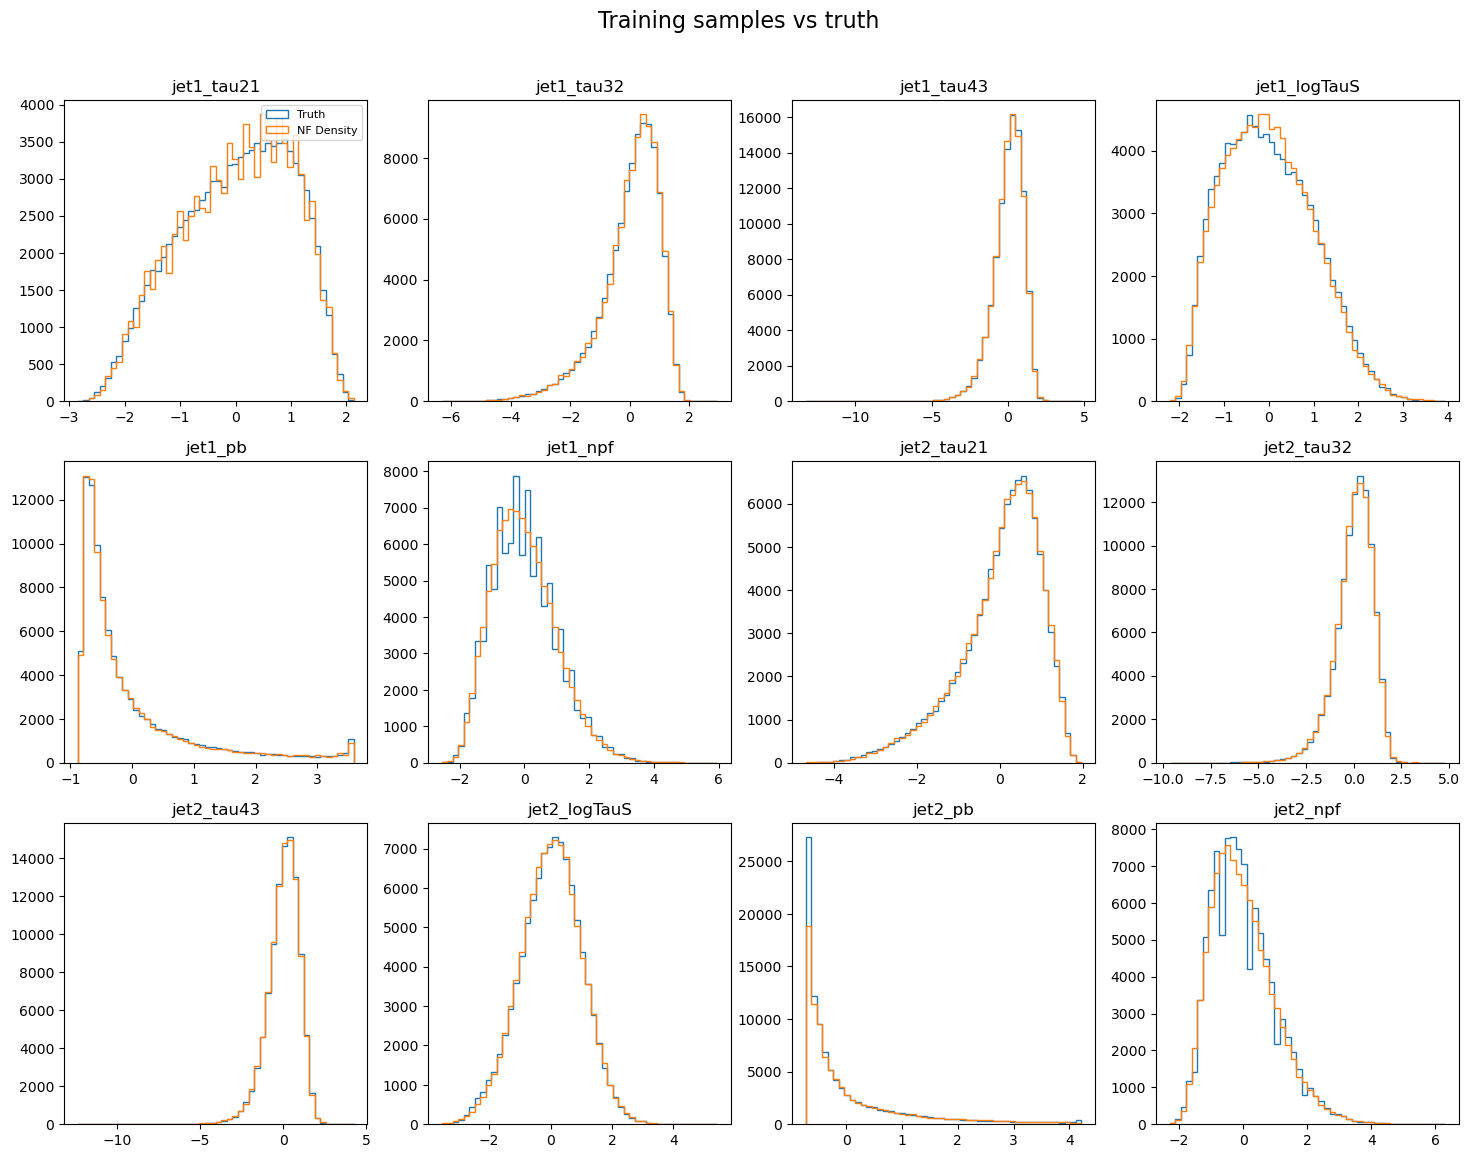

Loading test sample


  4%|▍         | 3/80 [00:01<00:26,  2.94it/s]


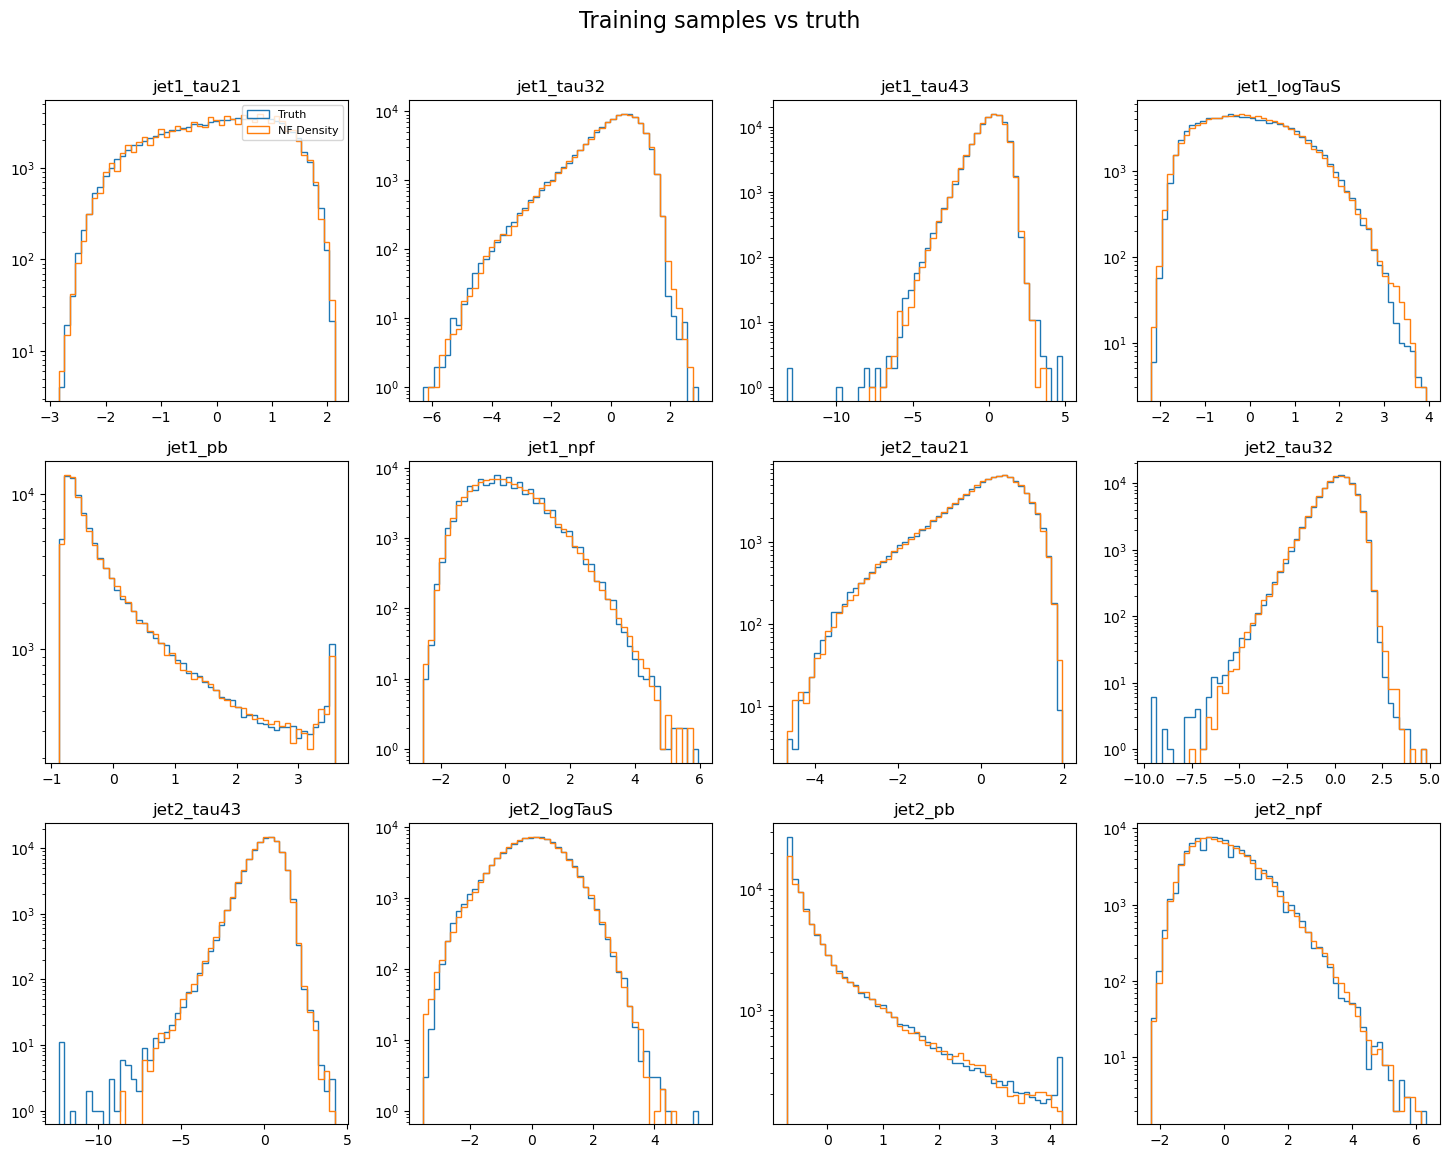

In [7]:
# Background
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "BKG"
modelName = "BKG_noRho"
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


100%|██████████| 1/1 [00:00<00:00, 25.38it/s]

83409 training events
Training flow BKG_mjjFlat_noRho


Iteration 10 Complete
Loss:  14.98966121673584
Iteration 20 Complete
Loss:  13.956673622131348
Iteration 30 Complete
Loss:  13.428686141967773
Iteration 40 Complete
Loss:  13.171990394592285
Iteration 50 Complete
Loss:  13.054254531860352
Iteration 60 Complete
Loss:  13.012728691101074
Iteration 70 Complete
Loss:  12.829147338867188
Iteration 80 Complete
Loss:  12.8930025100708
Iteration 90 Complete
Loss:  12.81173038482666
Iteration 100 Complete
Loss:  12.734745979309082
Iteration 110 Complete
Loss:  12.515825271606445
Iteration 120 Complete
Loss:  12.412110328674316
Iteration 130 Complete
Loss:  12.326950073242188
Iteration 140 Complete
Loss:  12.19225025177002
Iteration 150 Complete
Loss:  12.165444374084473
Iteration 160 Complete
Loss:  12.151663780212402
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 104.36it/s]


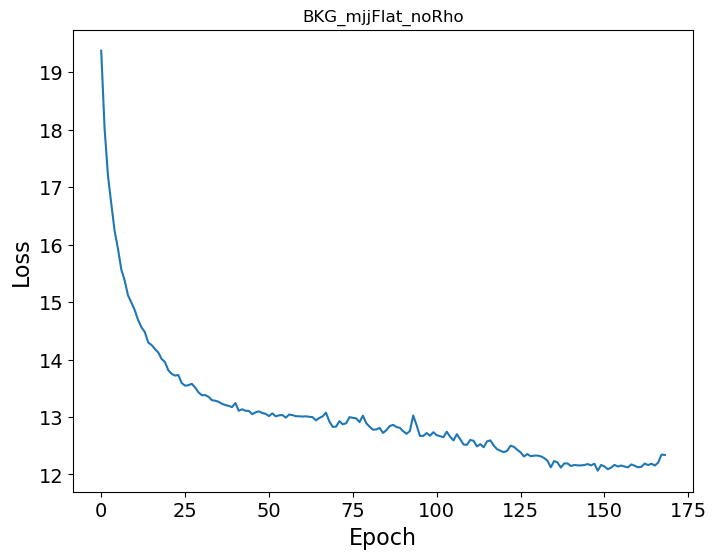

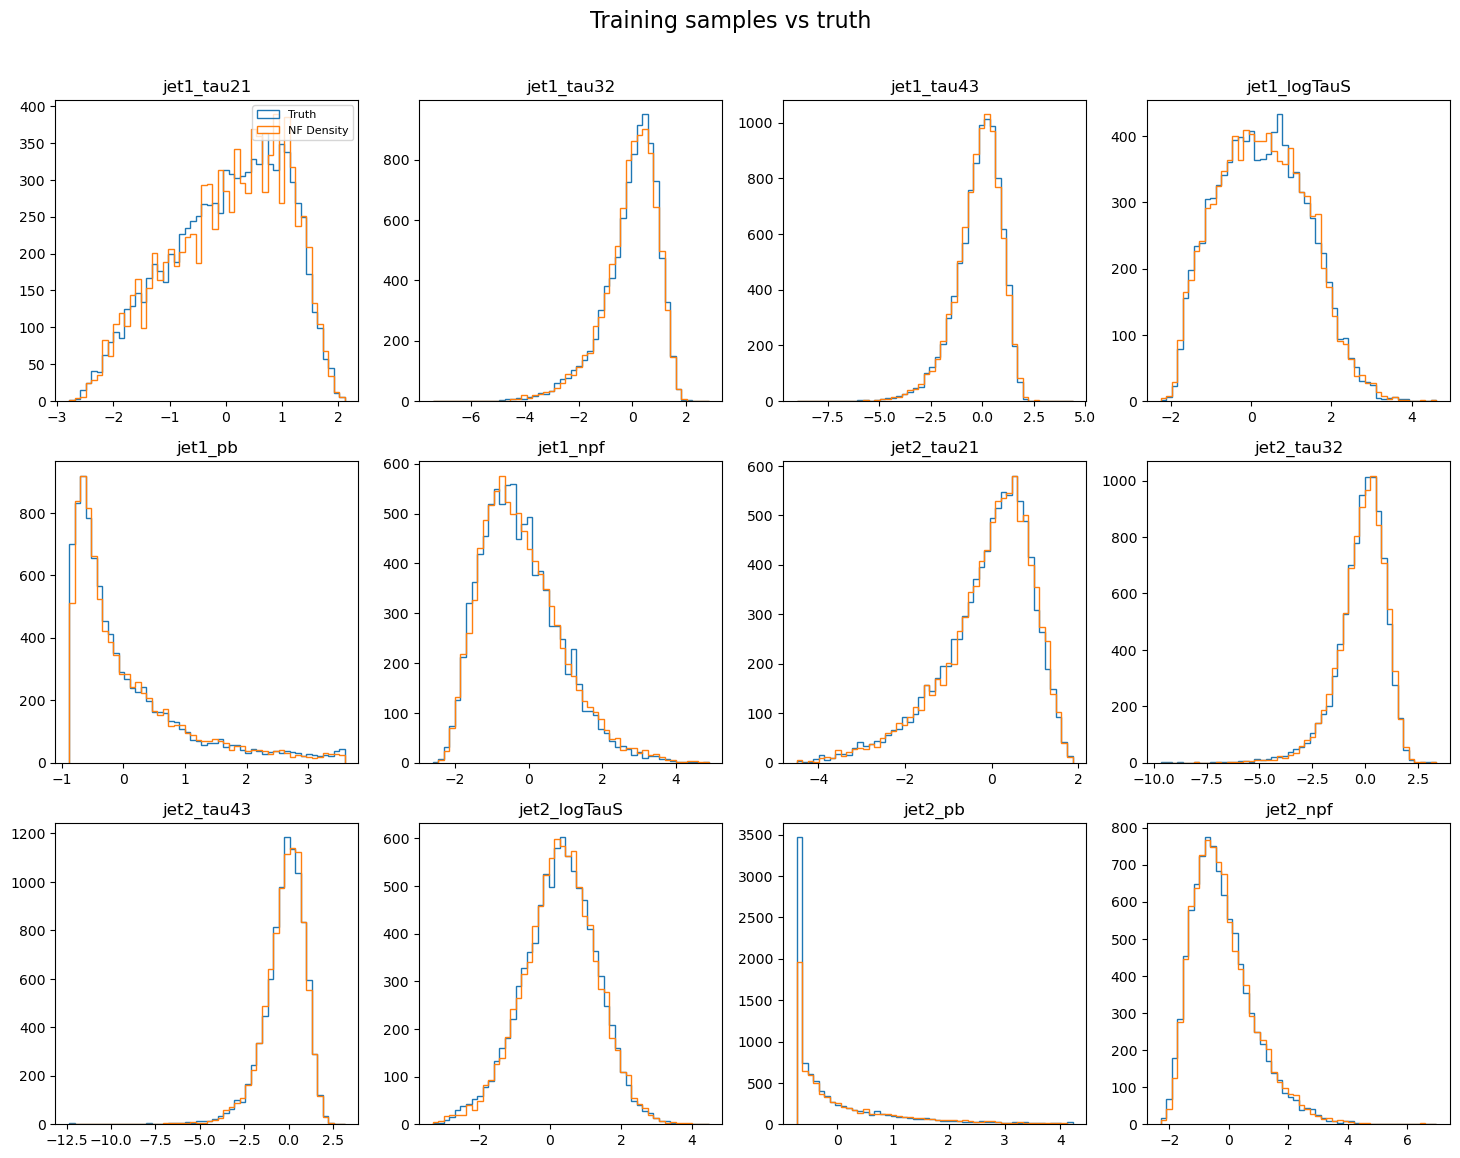

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 153.46it/s]


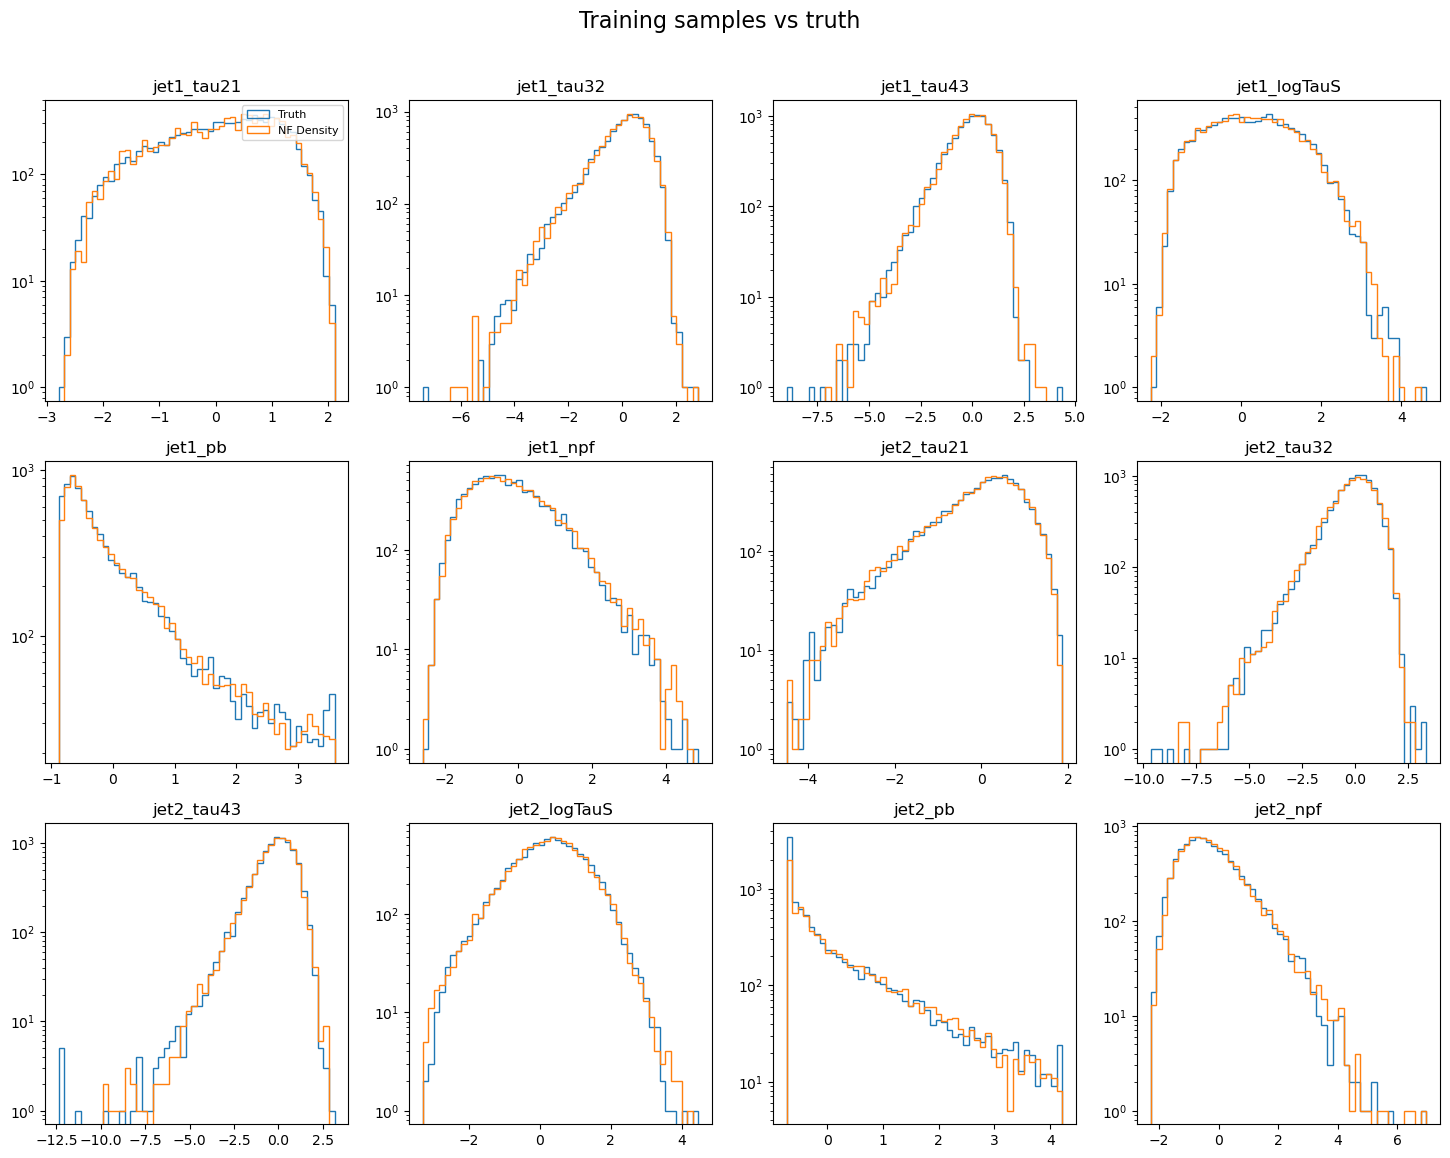

In [8]:
# Mjj-flattened background
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "BKG_mjjFlat"
modelName = "BKG_mjjFlat_noRho"
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=8000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

# Data Sideband

Loading train sample


  0%|          | 0/40 [00:04<?, ?it/s]


100000 training events
Training flow DATA_noRho
Iteration 10 Complete
Loss:  13.991793632507324
Iteration 20 Complete
Loss:  13.083999633789062
Iteration 30 Complete
Loss:  12.675971984863281
Iteration 40 Complete
Loss:  12.539369583129883
Iteration 50 Complete
Loss:  12.449573516845703
Iteration 60 Complete
Loss:  12.419707298278809
Iteration 70 Complete
Loss:  12.396385192871094
Iteration 80 Complete
Loss:  12.342570304870605
Iteration 90 Complete
Loss:  12.245147705078125
Iteration 100 Complete
Loss:  12.302154541015625
Iteration 110 Complete
Loss:  12.028035163879395
Iteration 120 Complete
Loss:  12.127218246459961
Iteration 130 Complete
Loss:  11.900429725646973
Iteration 140 Complete
Loss:  11.848292350769043
Iteration 150 Complete
Loss:  11.816839218139648
Iteration 160 Complete
Loss:  11.820012092590332
Iteration 170 Complete
Loss:  11.89034652709961
Loading test sample


 12%|█▎        | 5/40 [00:23<02:43,  4.68s/it]


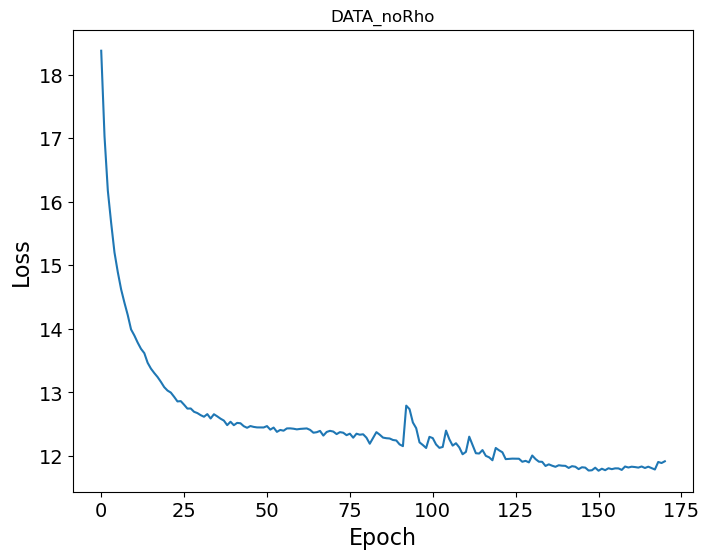

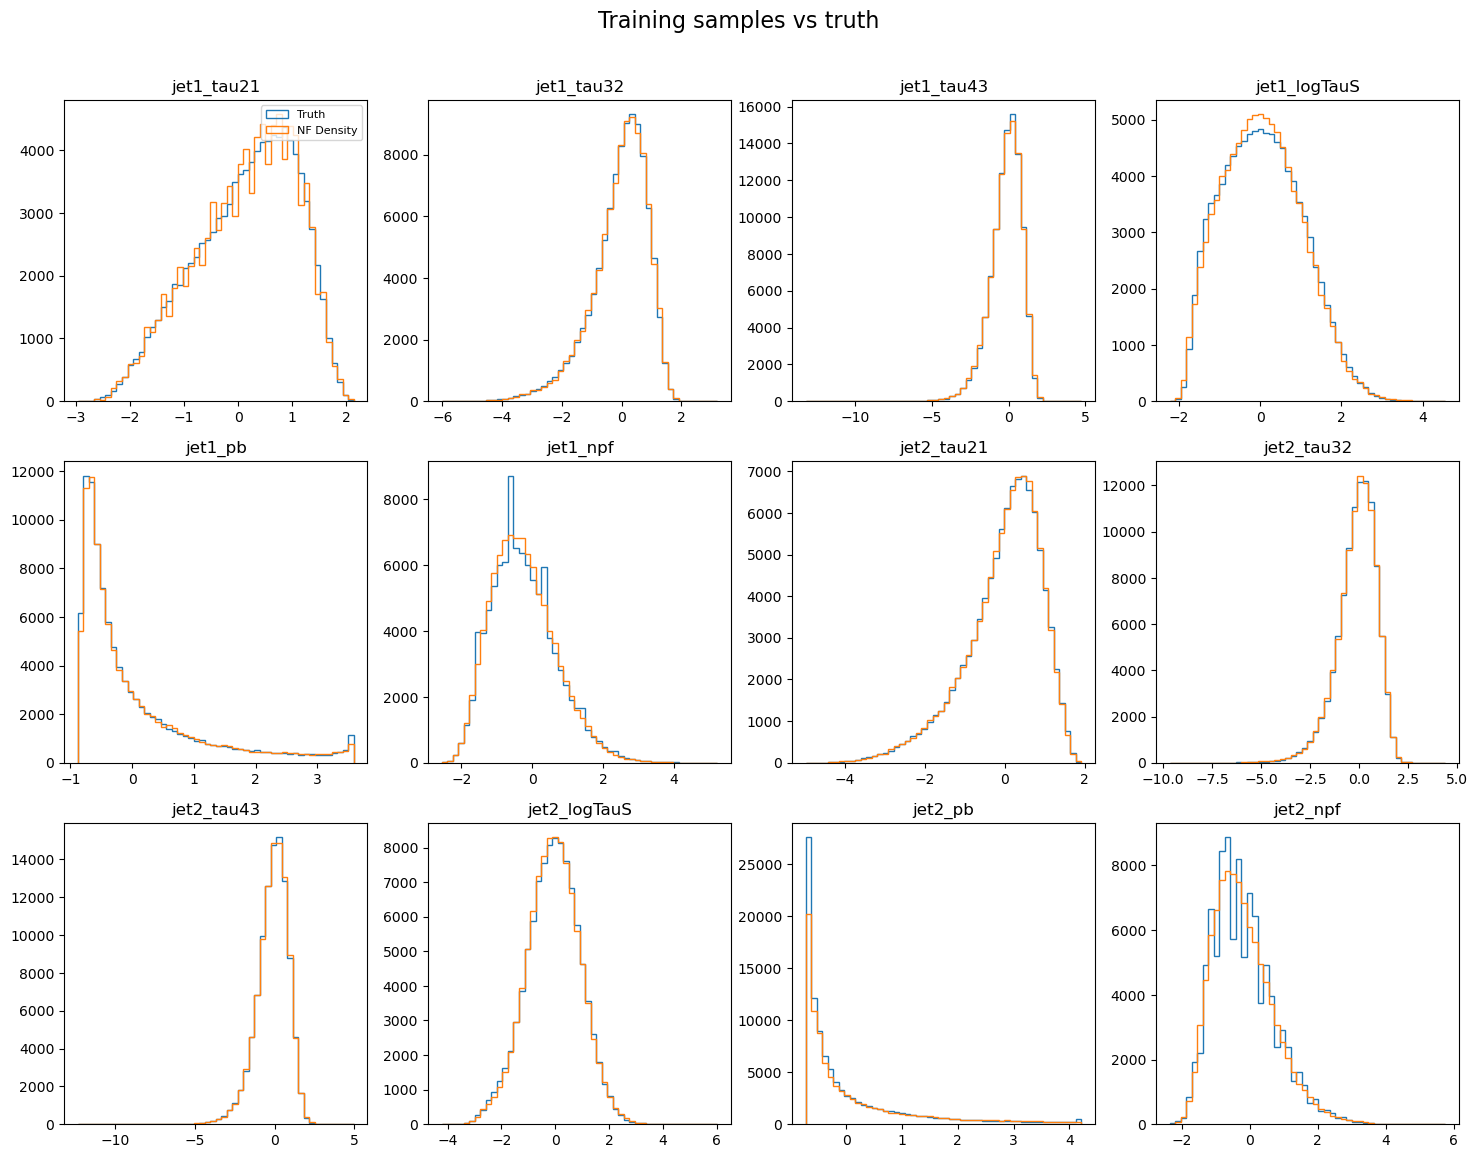

Loading test sample


 12%|█▎        | 5/40 [00:24<02:50,  4.88s/it]


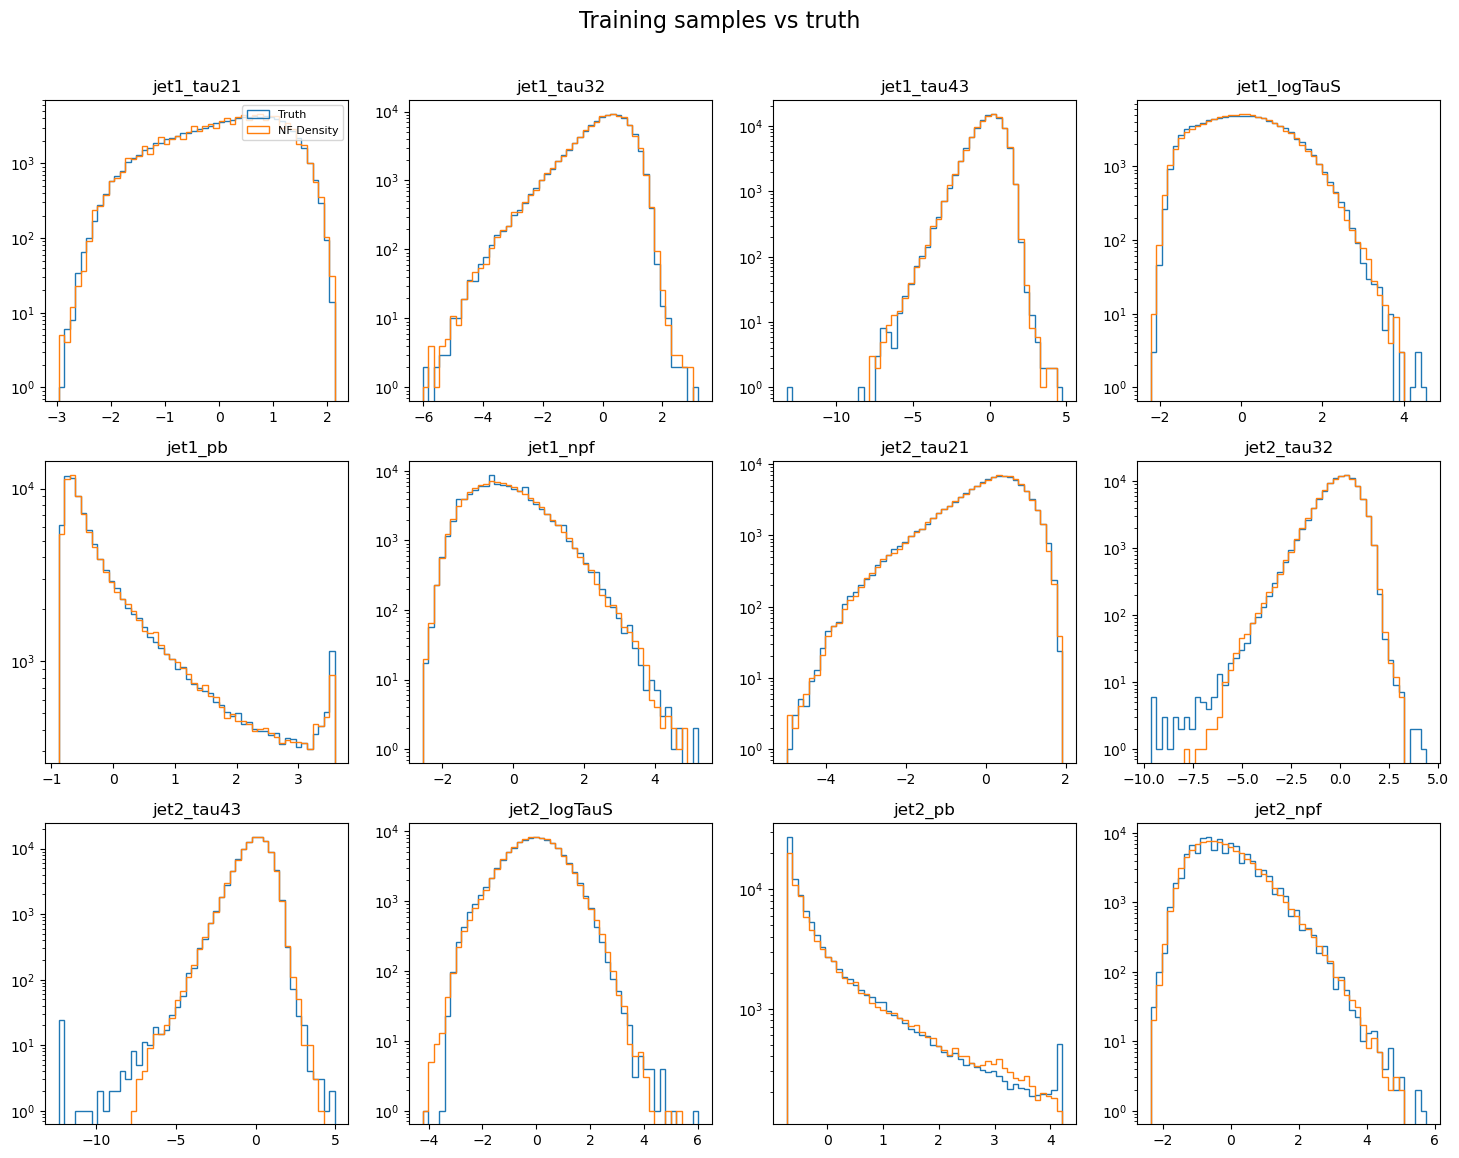

In [5]:
# Background
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "DATA"
modelName = "DATA_noRho"
reference = "BKG" # normalizing to Monte Carlo mean/std just for consistency w/ other trainings
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=True,
                    modelName=modelName) # Adding sideband cut pre-training!
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

# Mjj-flattened data sideband

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]

100000 training events
Training flow DATA_noRho_mjjFlat


Iteration 10 Complete
Loss:  14.769930839538574
Iteration 20 Complete
Loss:  13.834332466125488
Iteration 30 Complete
Loss:  13.426143646240234
Iteration 40 Complete
Loss:  13.230765342712402
Iteration 50 Complete
Loss:  13.105376243591309
Iteration 60 Complete
Loss:  13.096765518188477
Iteration 70 Complete
Loss:  13.042878150939941
Iteration 80 Complete
Loss:  12.93701171875
Iteration 90 Complete
Loss:  12.892640113830566
Iteration 100 Complete
Loss:  13.165470123291016
Iteration 110 Complete
Loss:  12.71242618560791
Iteration 120 Complete
Loss:  12.821229934692383
Iteration 130 Complete
Loss:  12.530352592468262
Iteration 140 Complete
Loss:  12.371305465698242
Iteration 150 Complete
Loss:  12.353132247924805
Iteration 160 Complete
Loss:  12.31403923034668
Iteration 170 Complete
Loss:  12.49264144897461
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 124.91it/s]


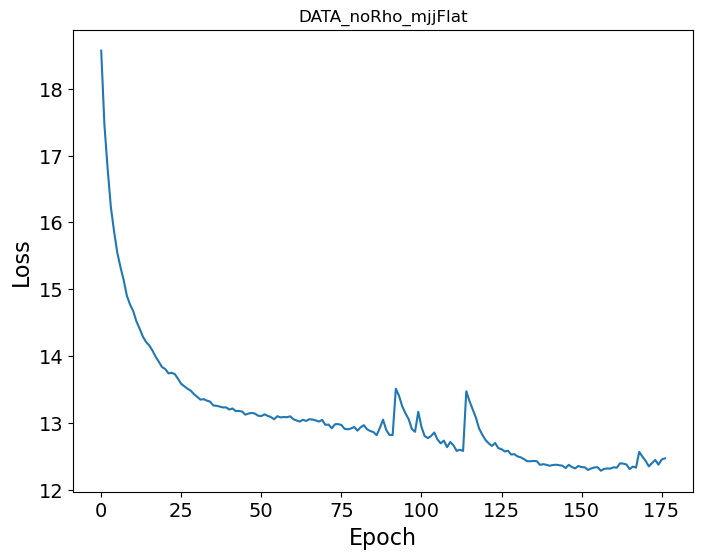

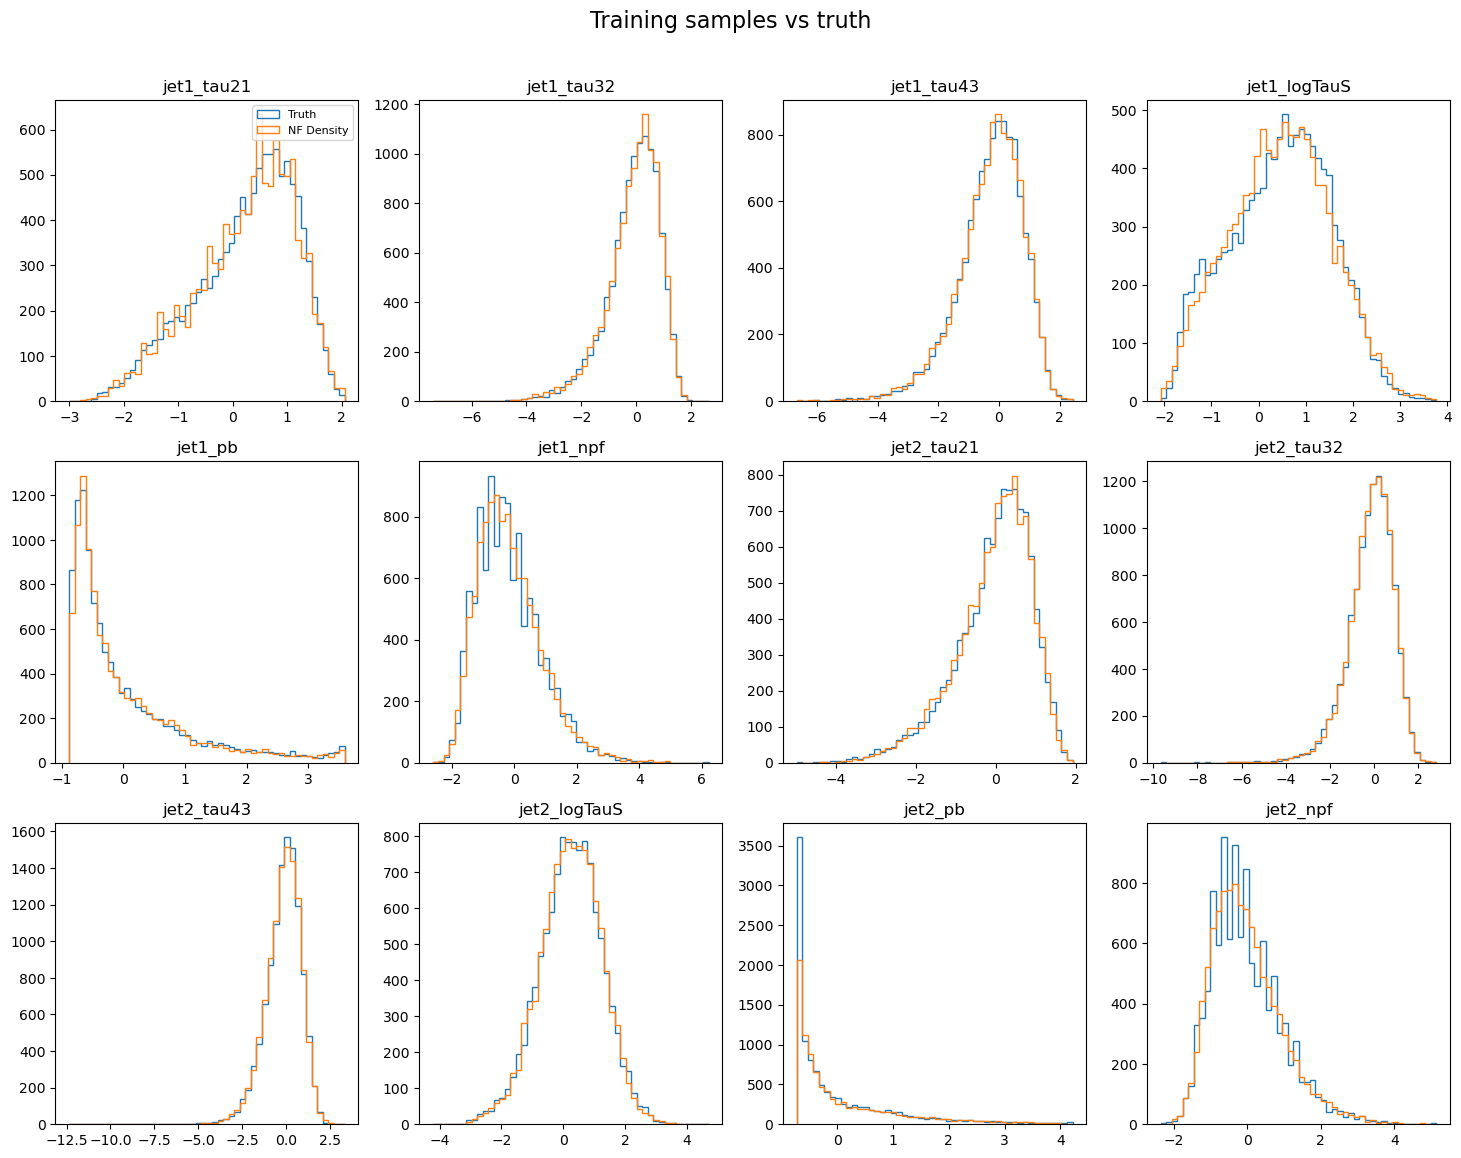

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 119.68it/s]


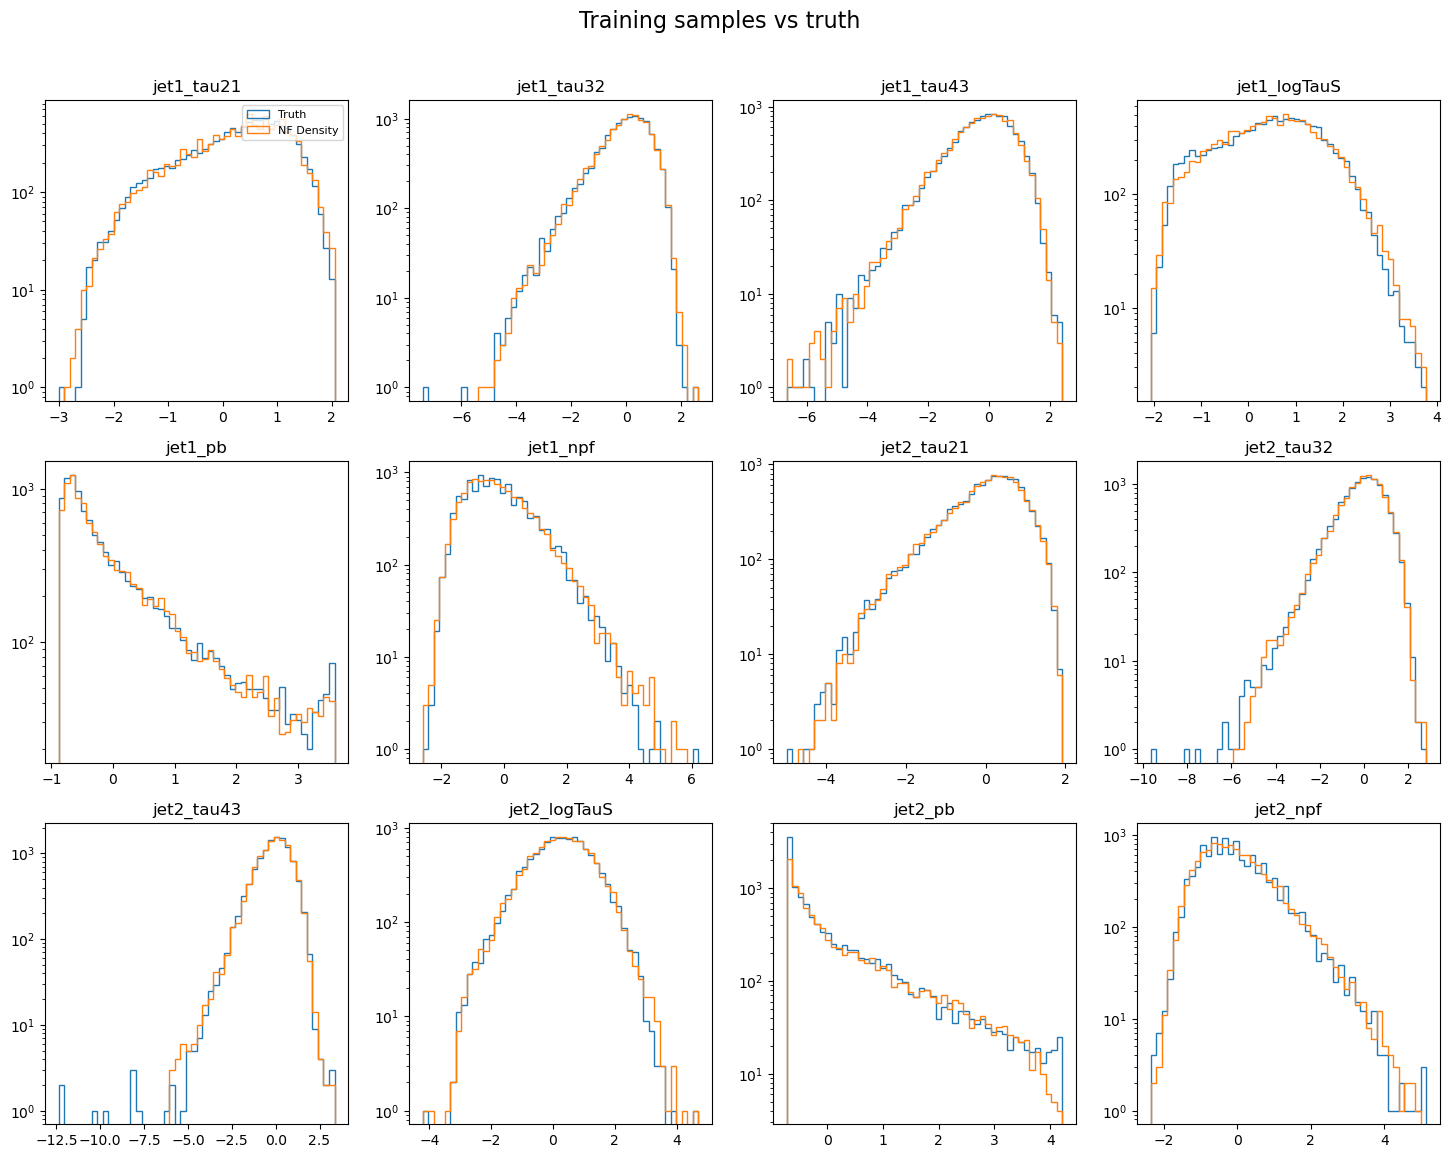

In [9]:
# Background
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

sample = "DATA_mjjFlat"
modelName = "DATA_noRho_mjjFlat"
reference = "BKG" # normalizing to Monte Carlo mean/std just for consistency w/ other trainings
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName) # sideband cut already applied to mjj-flattened data
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

# XYY3000_Y170_Yp170

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  4.22it/s]


99916 training events
Training flow XYY3000_Y170_Yp170
Iteration 10 Complete
Loss:  13.015999794006348
Iteration 20 Complete
Loss:  11.878229141235352
Iteration 30 Complete
Loss:  11.587357521057129
Iteration 40 Complete
Loss:  11.419060707092285
Iteration 50 Complete
Loss:  11.34347152709961
Iteration 60 Complete
Loss:  11.288346290588379
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 70.23it/s]


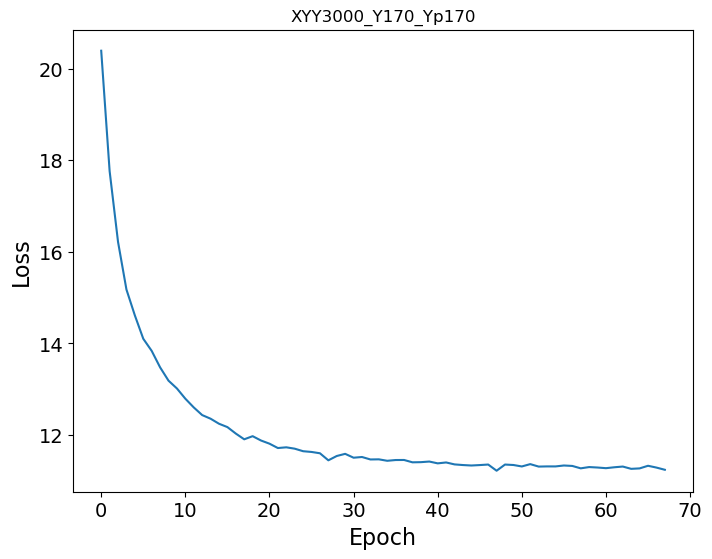

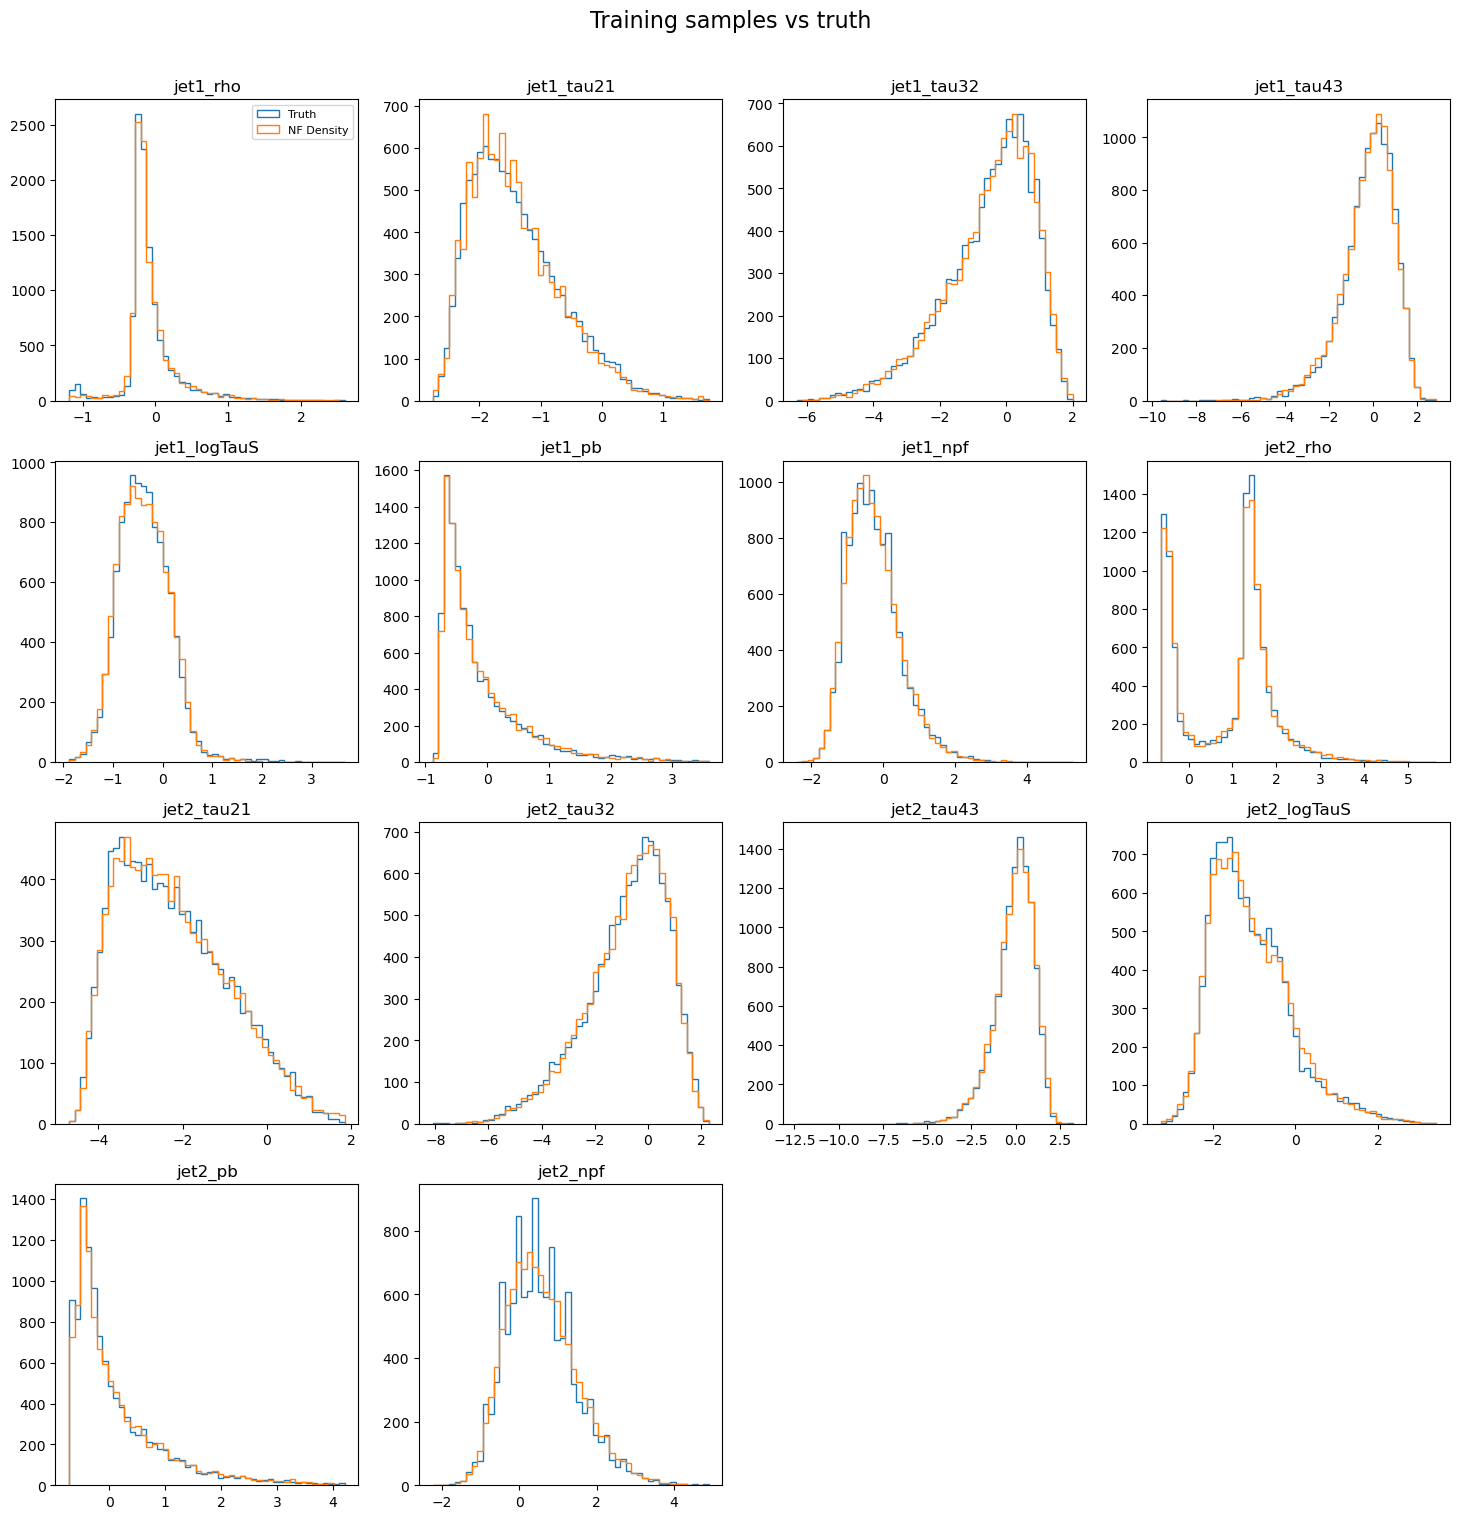

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 77.56it/s]


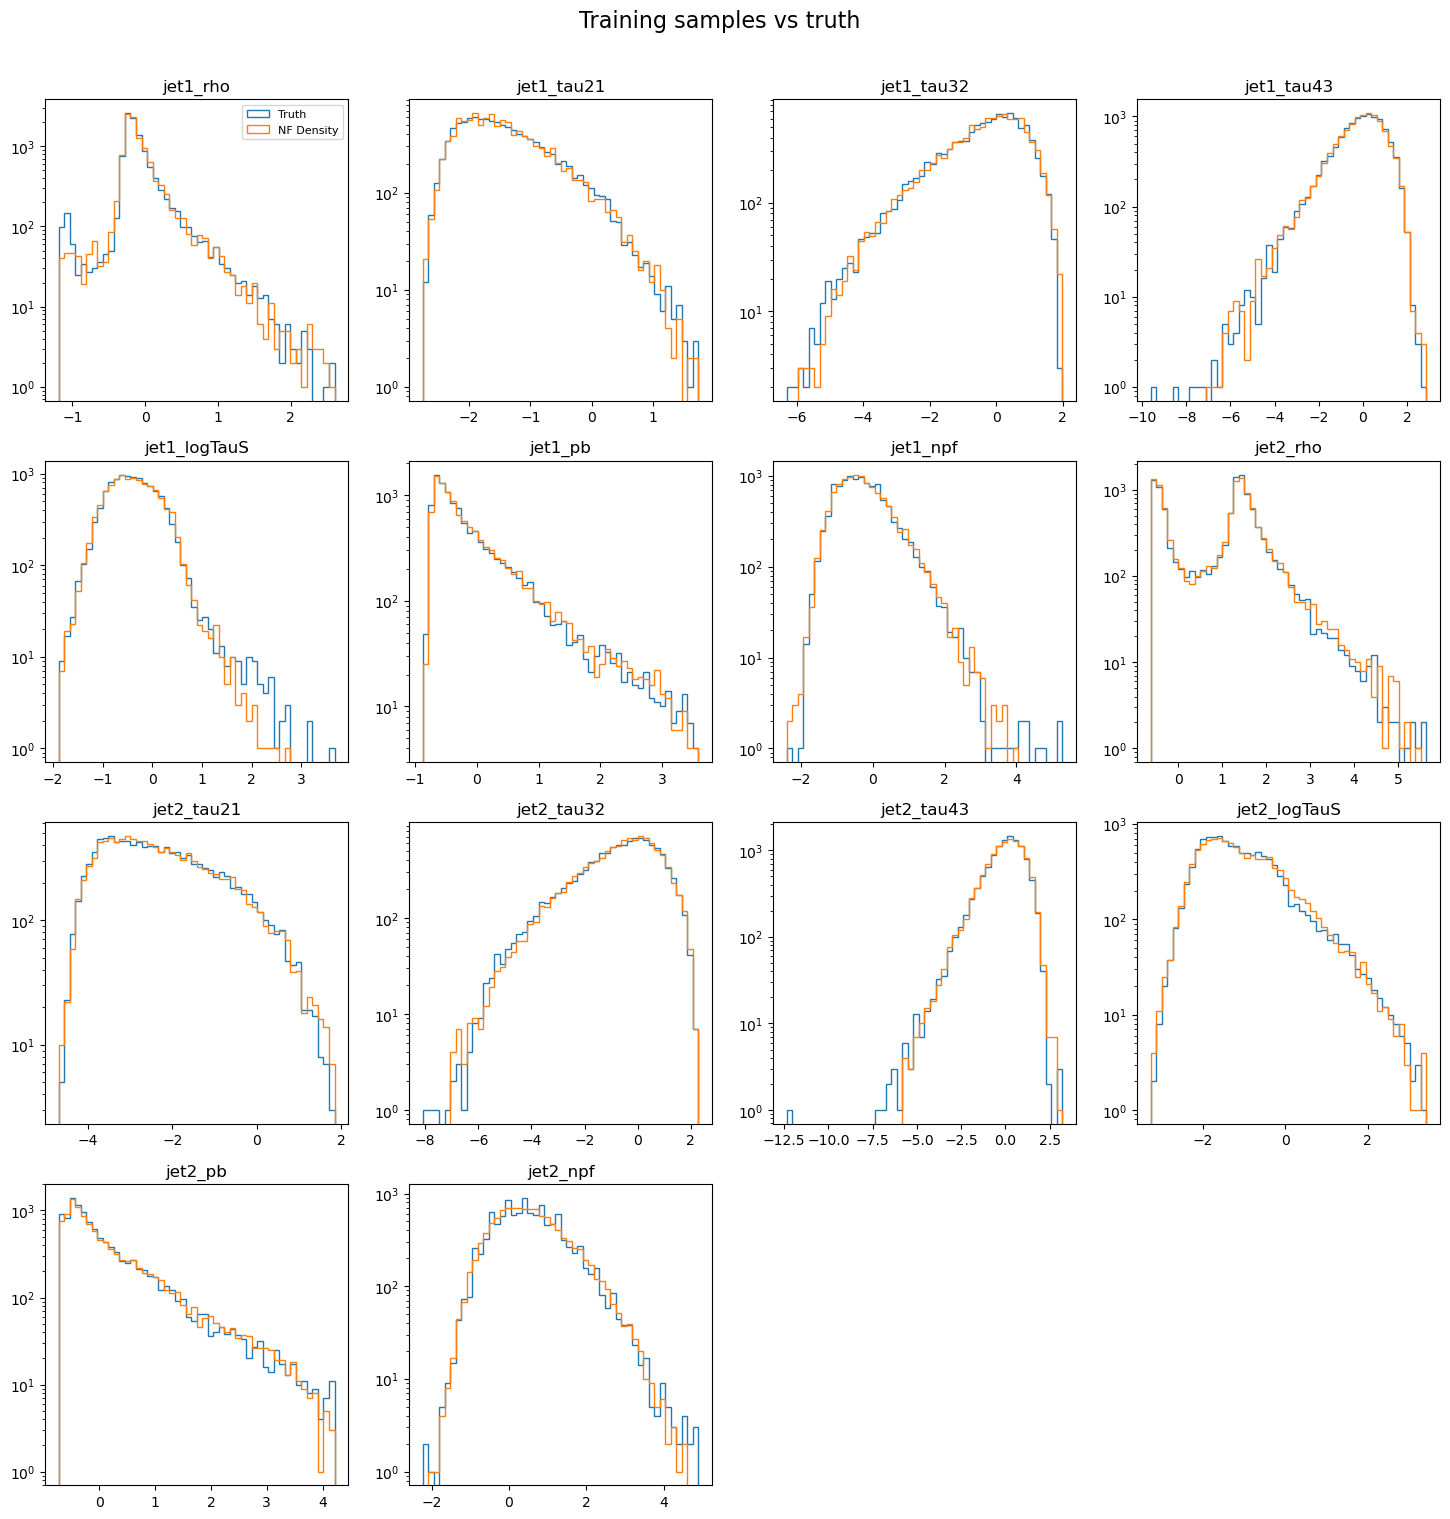

In [5]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "XYY3000_Y170_Yp170"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=5000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


  0%|          | 0/1 [00:00<?, ?it/s]


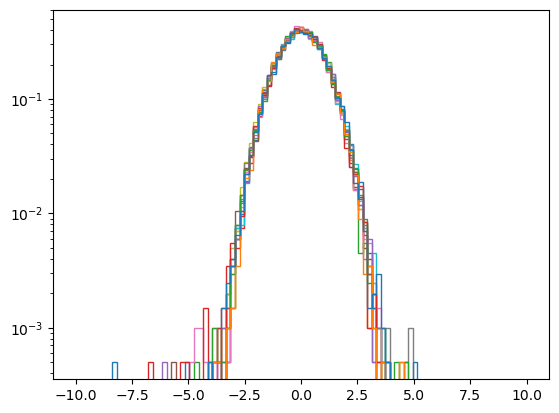

In [6]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# Wp3000_B400_T170

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  4.00it/s]


87874 training events
Training flow Wp3000_B400_T170
Iteration 10 Complete
Loss:  18.1024112701416
Iteration 20 Complete
Loss:  16.910945892333984
Iteration 30 Complete
Loss:  16.547943115234375
Iteration 40 Complete
Loss:  16.375797271728516
Iteration 50 Complete
Loss:  16.322458267211914
Iteration 60 Complete
Loss:  16.28937530517578
Iteration 70 Complete
Loss:  16.253339767456055
Iteration 80 Complete
Loss:  16.167011260986328
Iteration 90 Complete
Loss:  16.044912338256836
Iteration 100 Complete
Loss:  15.951177597045898
Iteration 110 Complete
Loss:  15.841410636901855
Iteration 120 Complete
Loss:  15.790477752685547
Iteration 130 Complete
Loss:  15.708772659301758
Iteration 140 Complete
Loss:  15.68675708770752
Iteration 150 Complete
Loss:  15.674847602844238
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 71.29it/s]


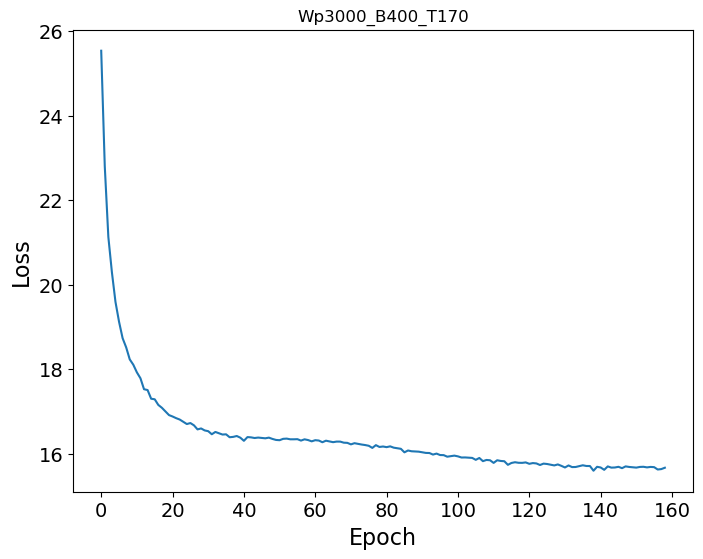

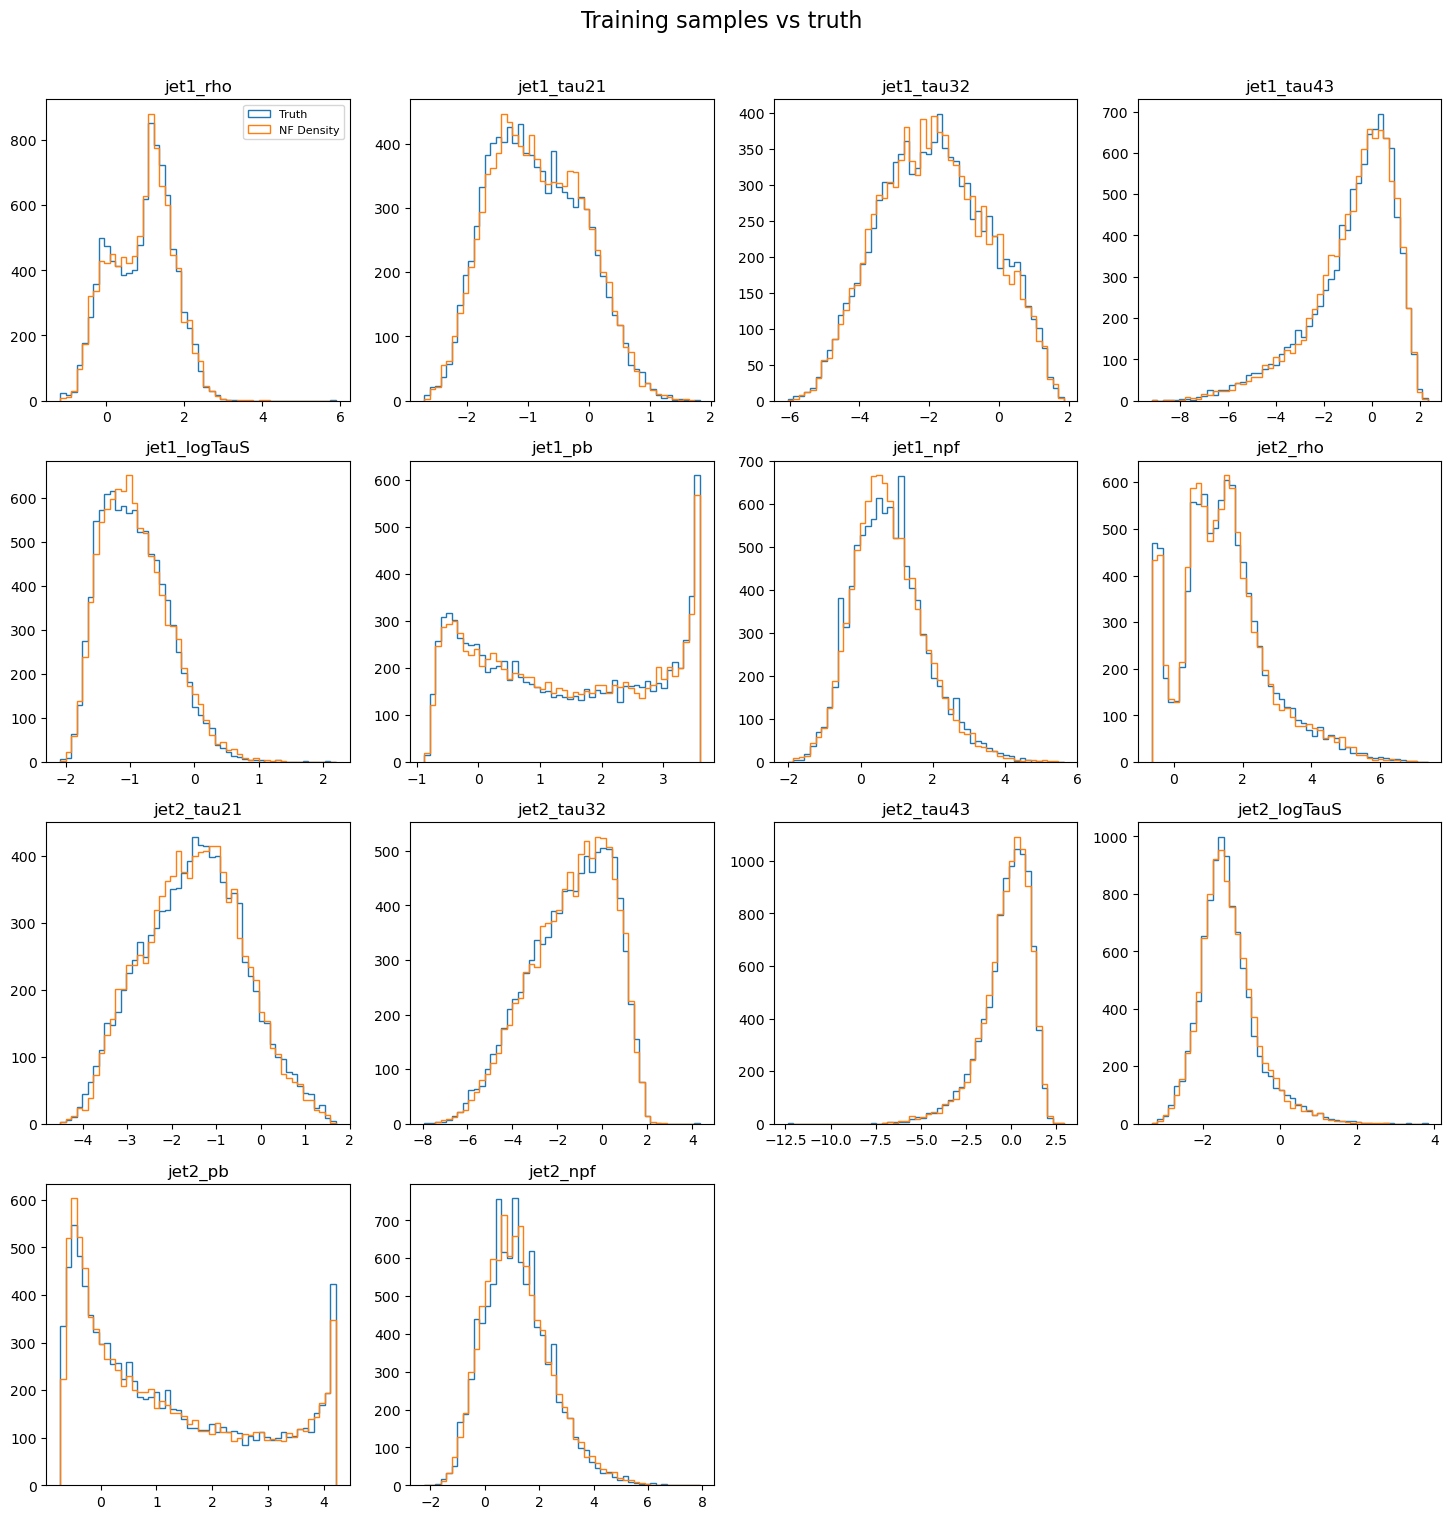

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 83.67it/s]


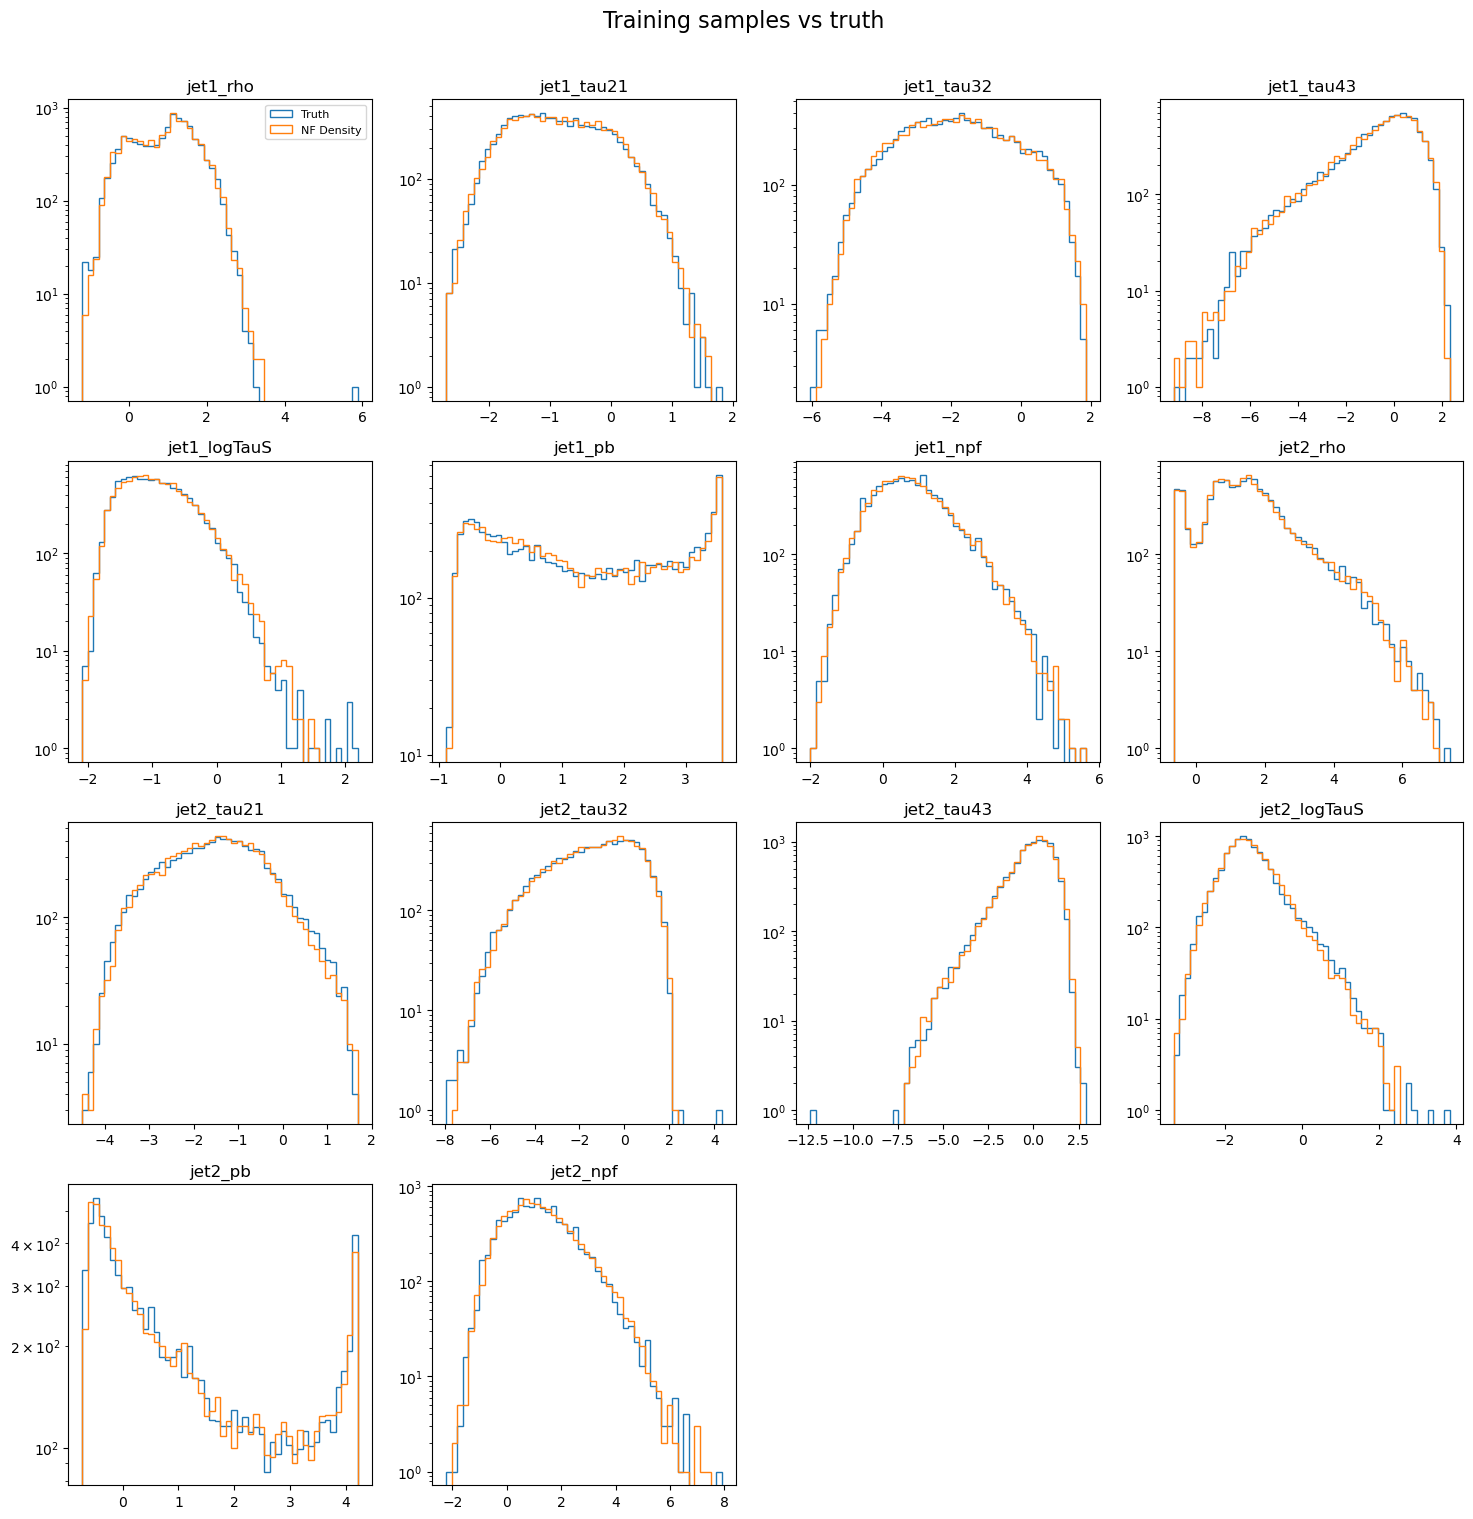

In [7]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "Wp3000_B400_T170"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=5000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 78.28it/s]


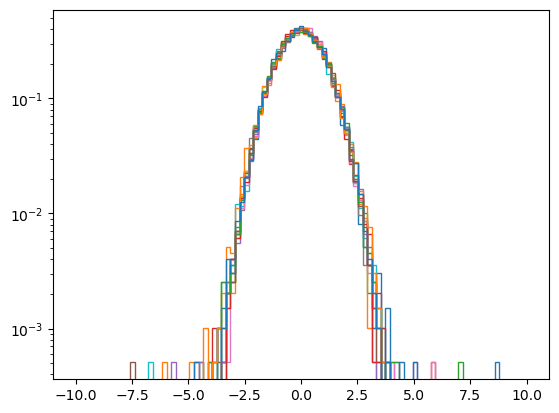

In [8]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# Qstar2000_W400

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  4.91it/s]


74583 training events
Training flow Qstar2000_W400
Iteration 10 Complete
Loss:  14.18510913848877
Iteration 20 Complete
Loss:  12.646563529968262
Iteration 30 Complete
Loss:  12.023409843444824
Iteration 40 Complete
Loss:  11.631145477294922
Iteration 50 Complete
Loss:  11.541202545166016
Iteration 60 Complete
Loss:  11.449594497680664
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 88.45it/s]


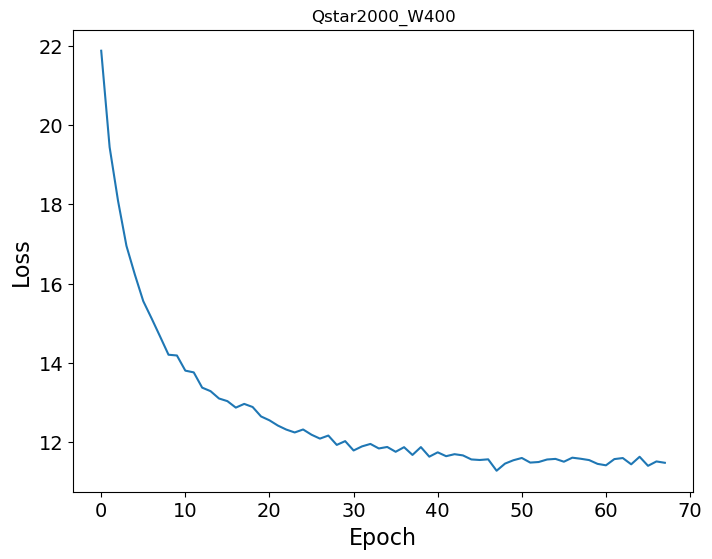

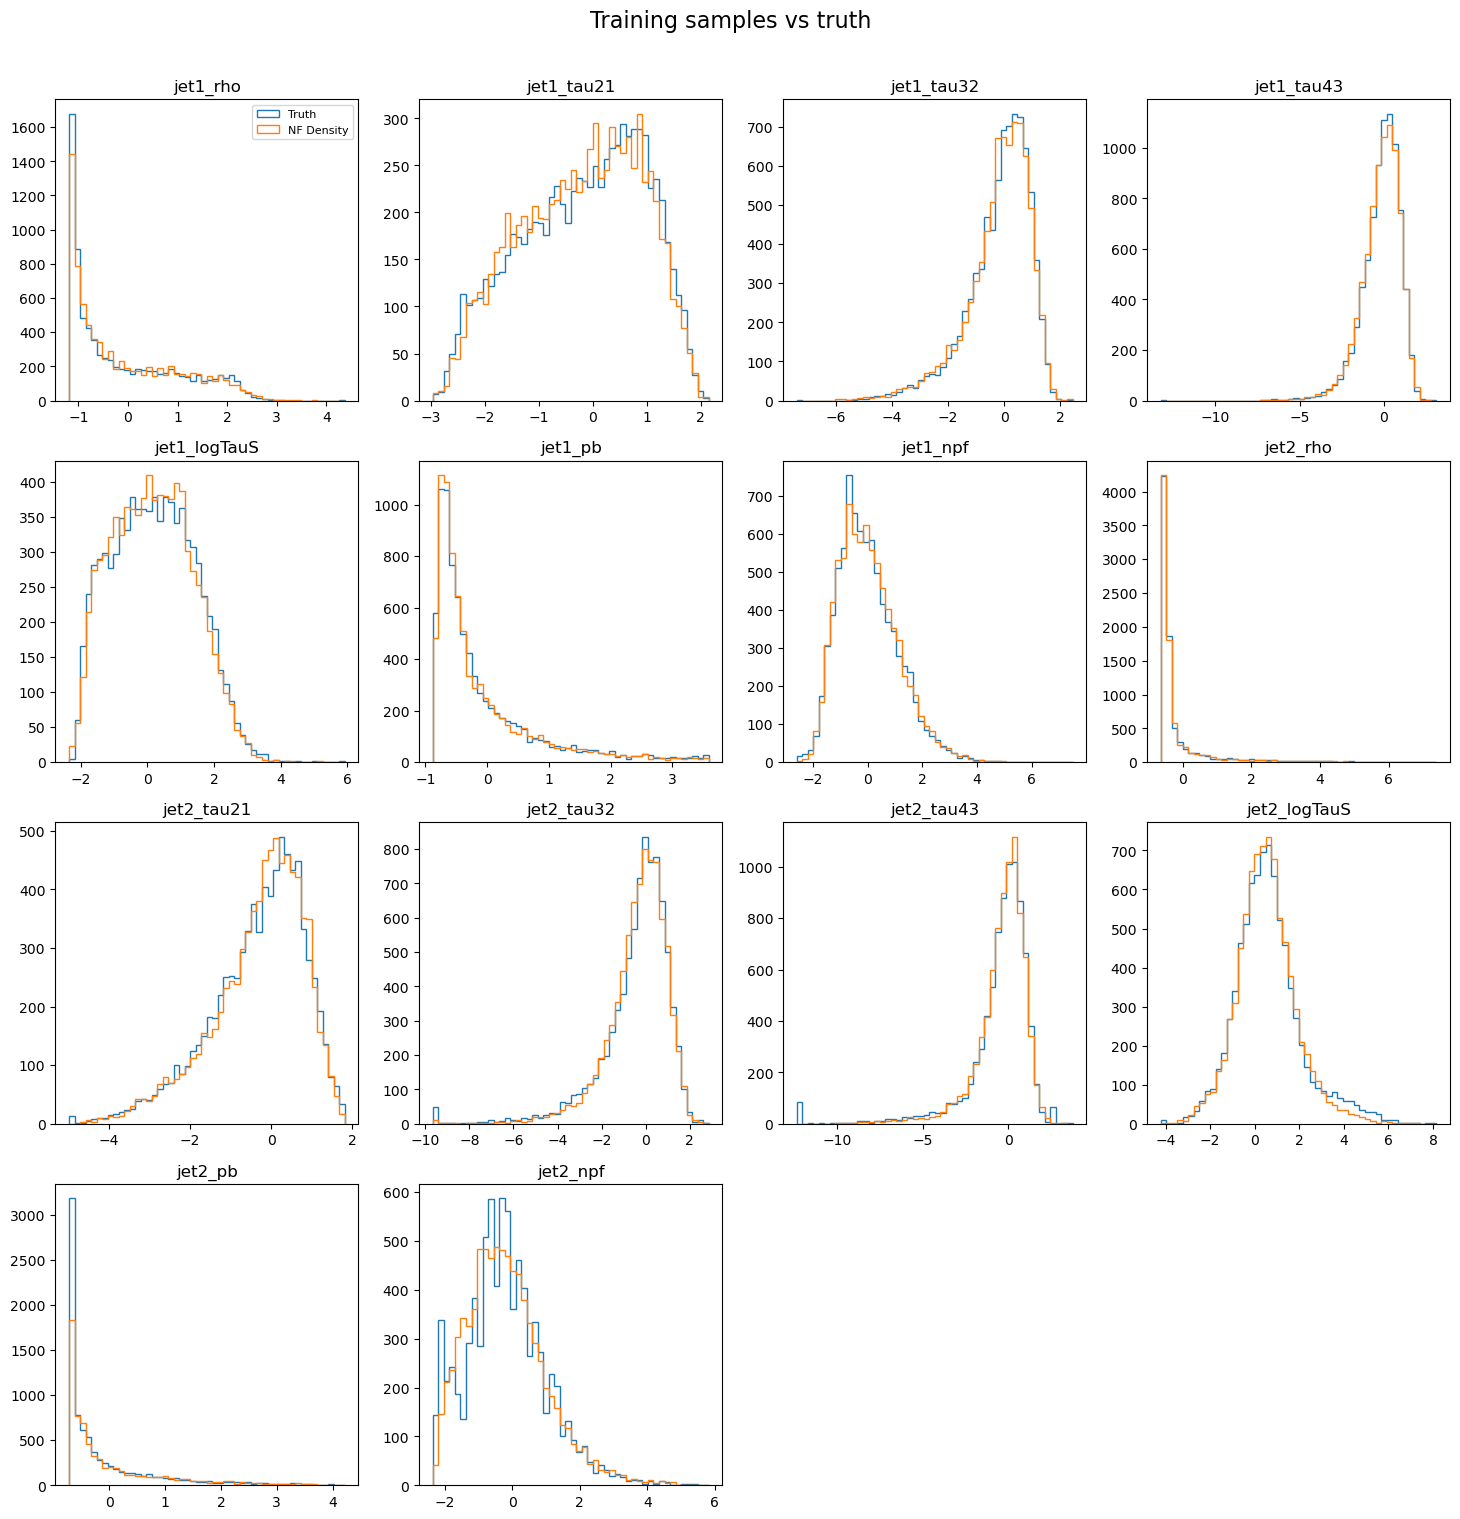

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 88.46it/s]


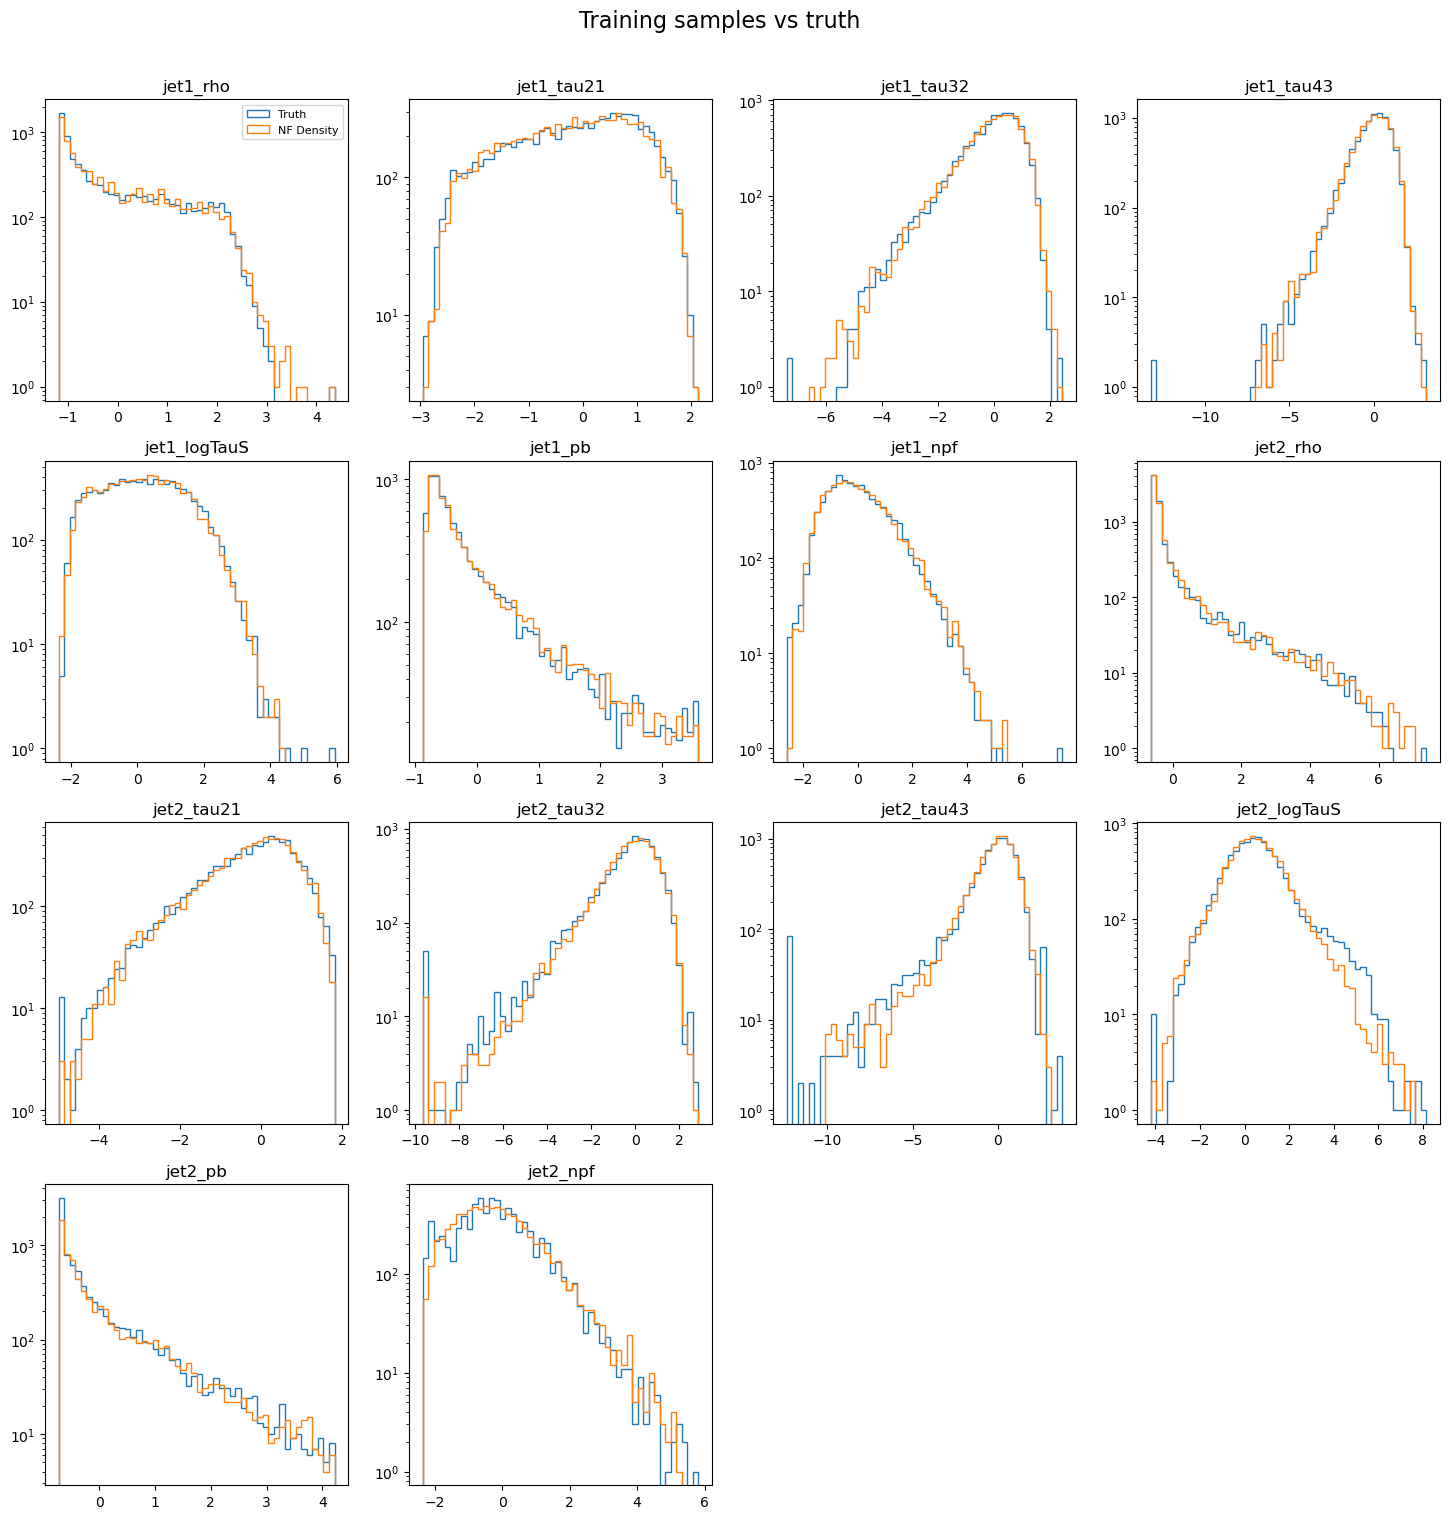

In [9]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "Qstar2000_W400"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=3000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 87.58it/s]


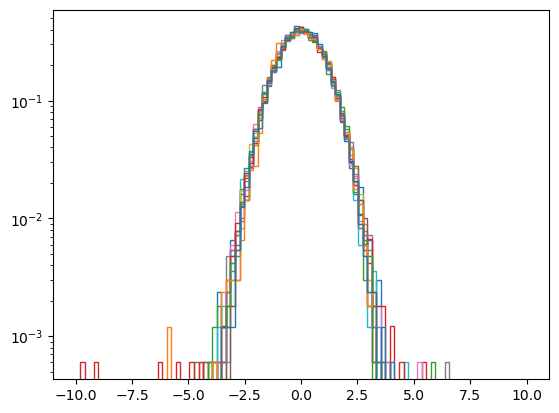

In [10]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# Wkk3000_R400

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  3.83it/s]


72497 training events
Training flow Wkk3000_R400
Iteration 10 Complete
Loss:  17.133583068847656
Iteration 20 Complete
Loss:  15.437718391418457
Iteration 30 Complete
Loss:  14.698690414428711
Iteration 40 Complete
Loss:  13.862885475158691
Iteration 50 Complete
Loss:  14.113377571105957
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 87.19it/s]


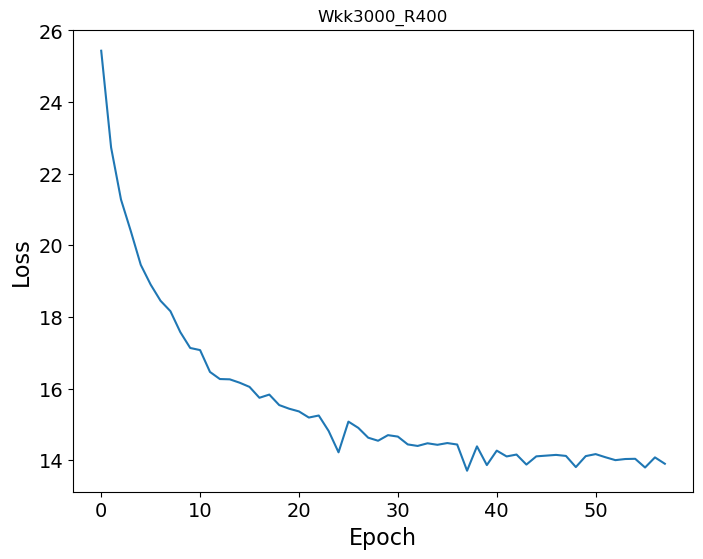

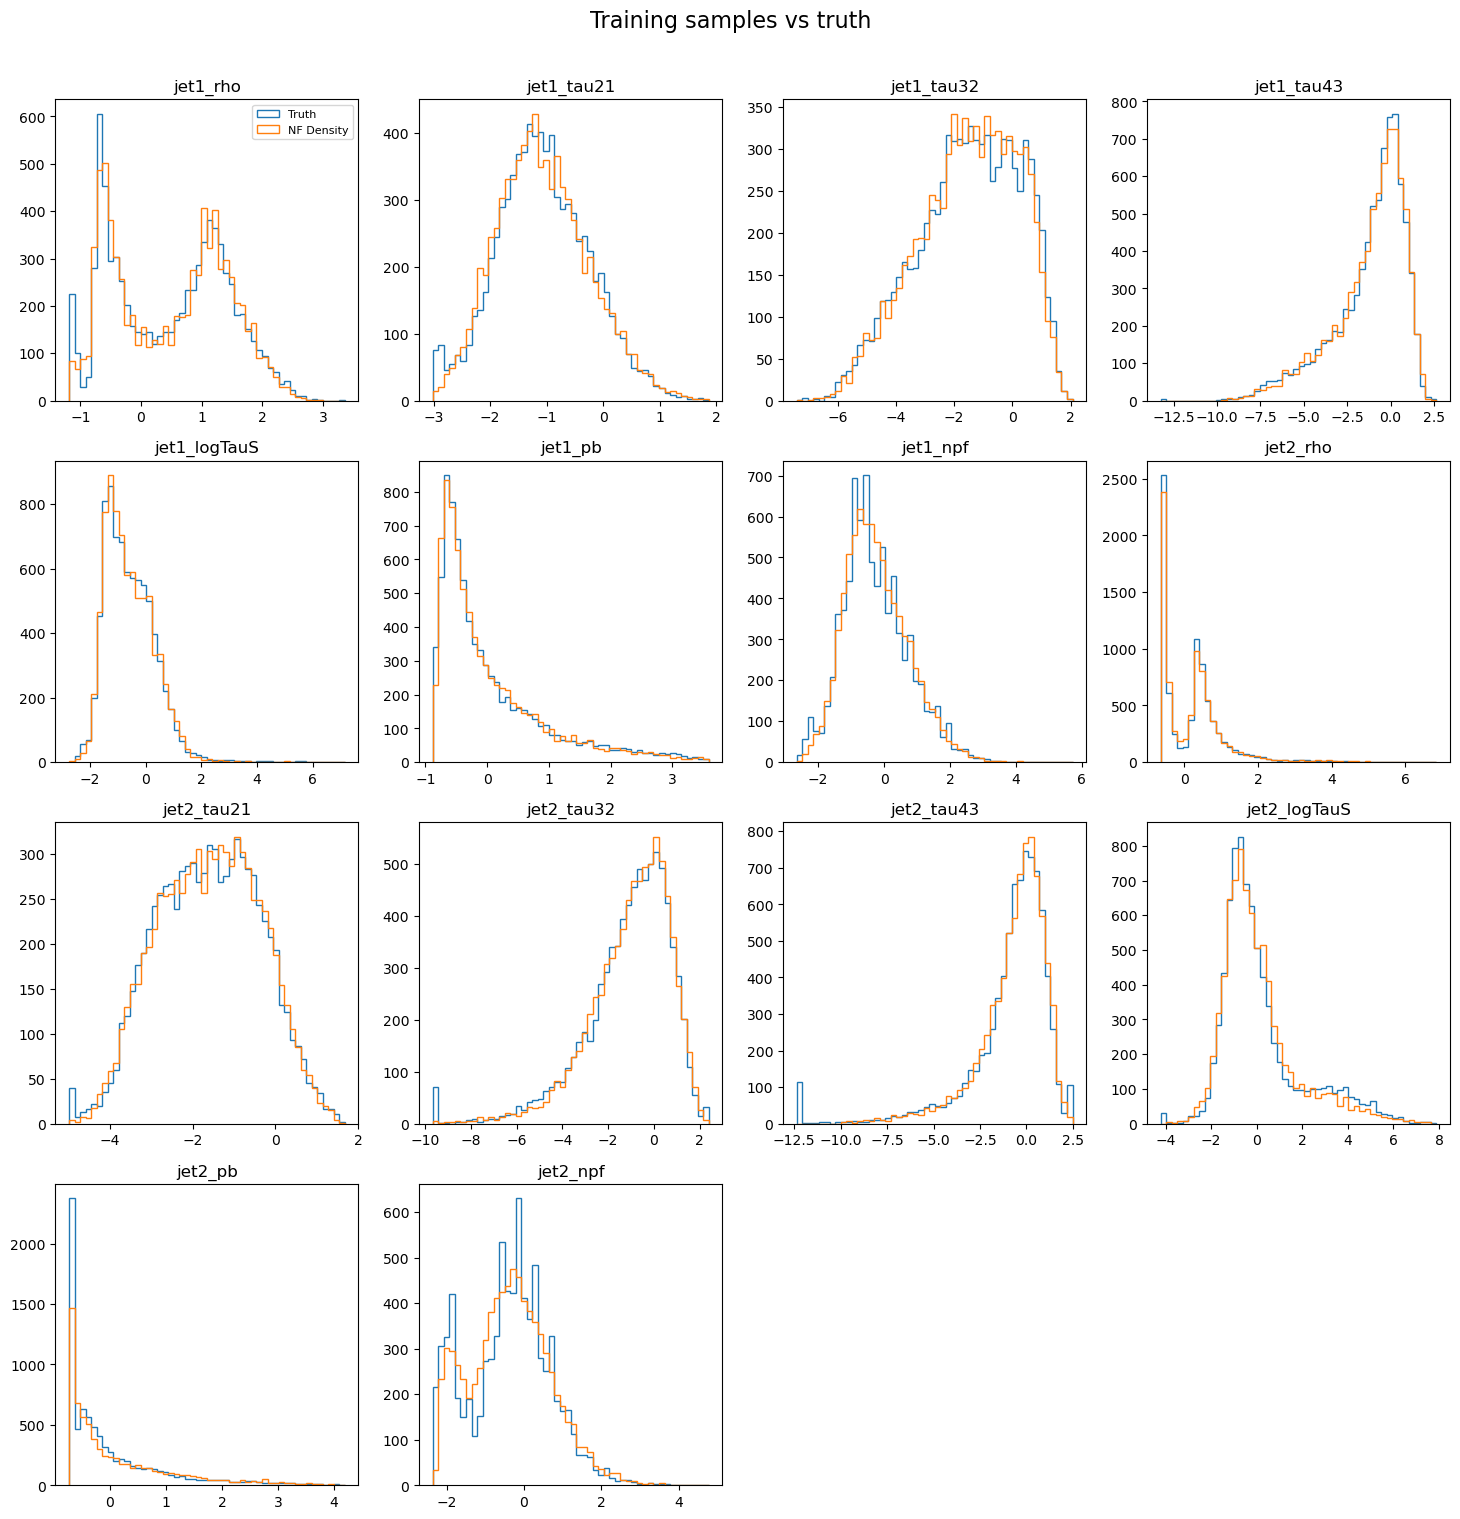

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 82.49it/s]


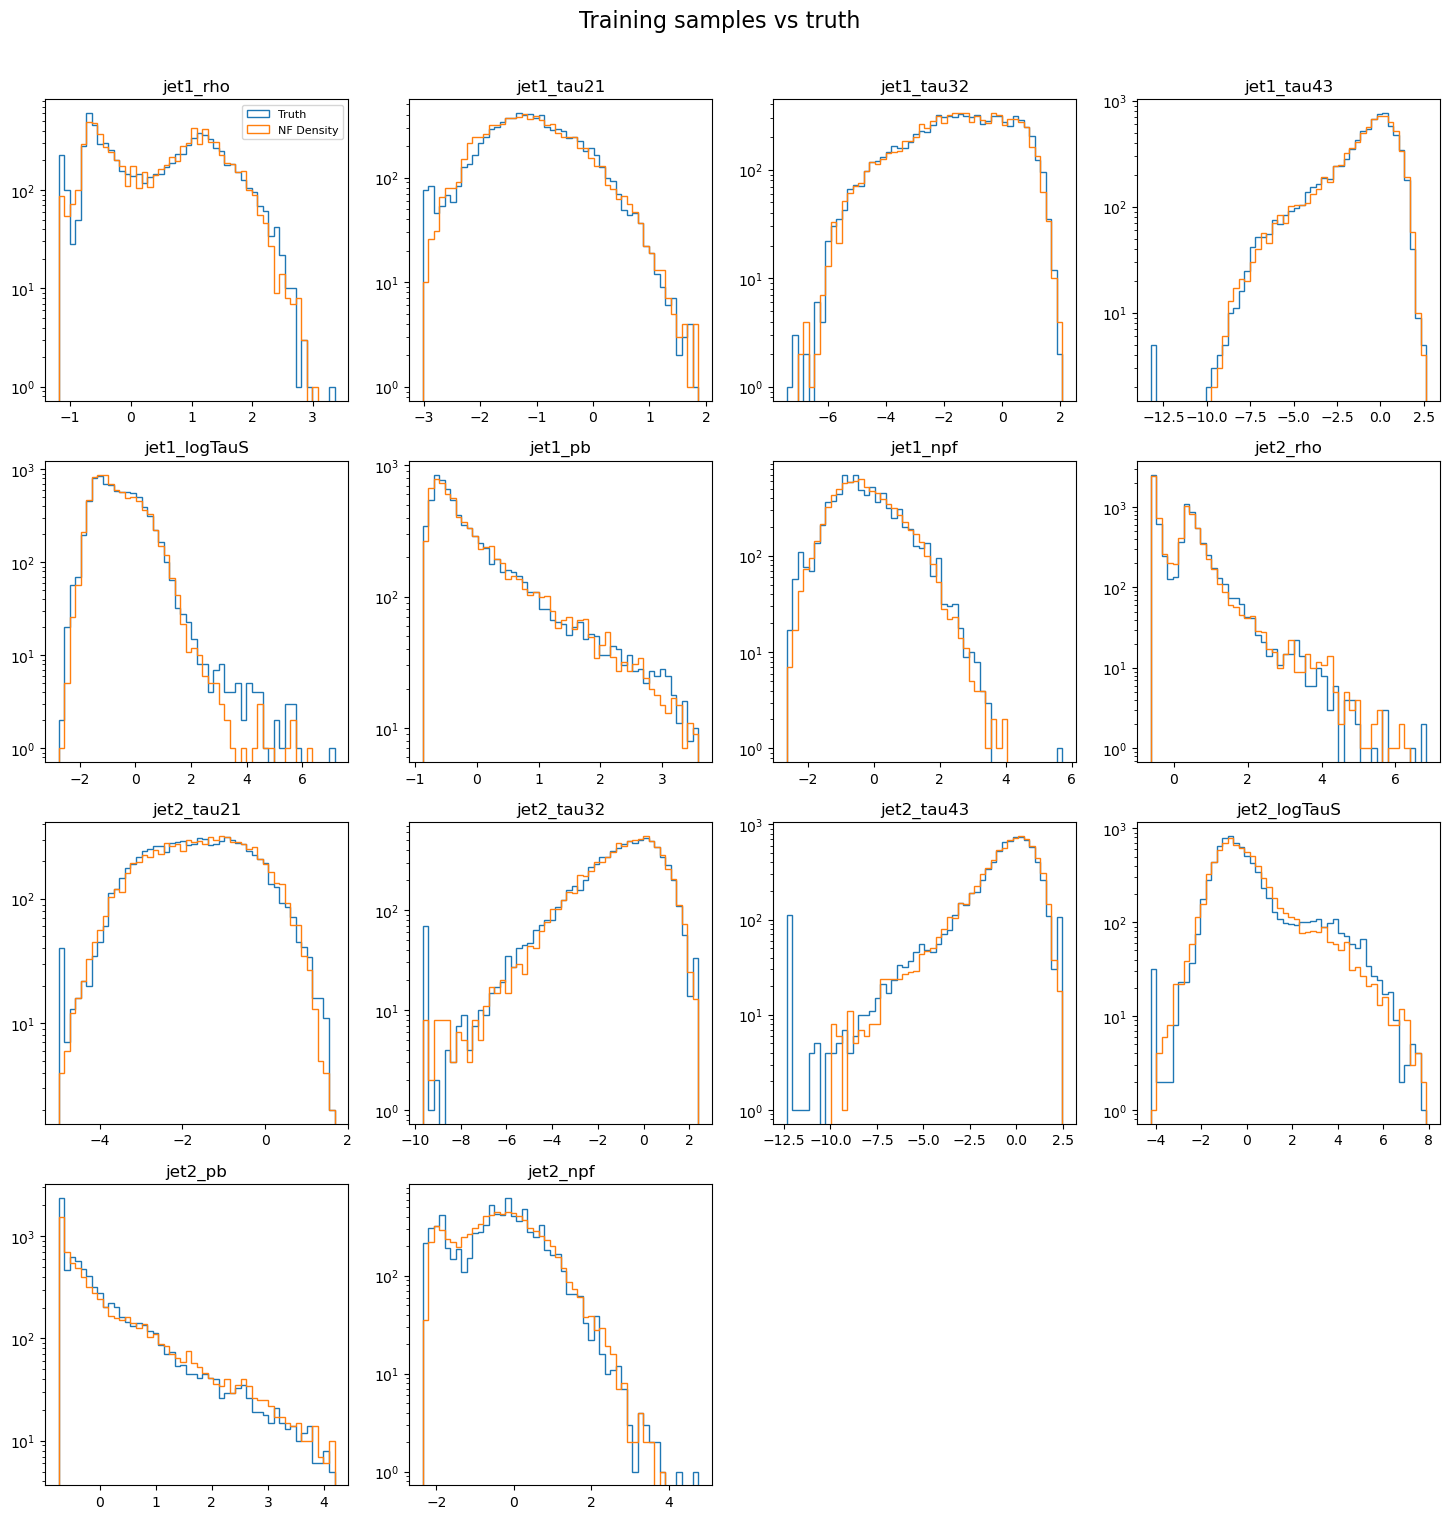

In [11]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":200,"num_layers":6,
             "num_bins":100,"num_blocks_per_layer":5,"tails":"linear"}
sample = "Wkk3000_R400"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=3000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 96.23it/s]


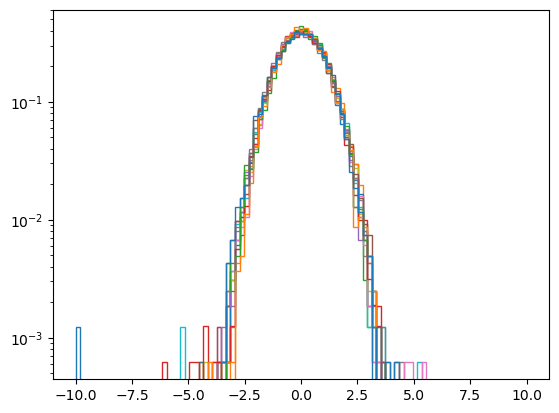

In [12]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# RSG3000

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  5.18it/s]


89615 training events
Training flow RSG3000
Iteration 10 Complete
Loss:  15.00536823272705
Iteration 20 Complete
Loss:  14.178593635559082
Iteration 30 Complete
Loss:  13.9805326461792
Iteration 40 Complete
Loss:  13.883454322814941
Iteration 50 Complete
Loss:  13.800968170166016
Iteration 60 Complete
Loss:  13.826950073242188
Iteration 70 Complete
Loss:  13.709858894348145
Iteration 80 Complete
Loss:  13.700390815734863
Iteration 90 Complete
Loss:  13.625679969787598
Iteration 100 Complete
Loss:  13.54954719543457
Iteration 110 Complete
Loss:  13.486231803894043
Iteration 120 Complete
Loss:  13.429265022277832
Iteration 130 Complete
Loss:  13.437551498413086
Iteration 140 Complete
Loss:  13.319075584411621
Iteration 150 Complete
Loss:  13.323195457458496
Iteration 160 Complete
Loss:  13.296489715576172
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 69.89it/s]


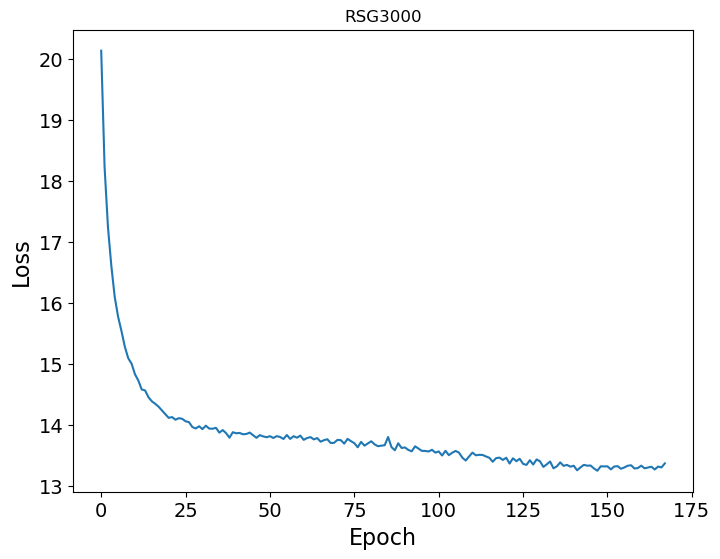

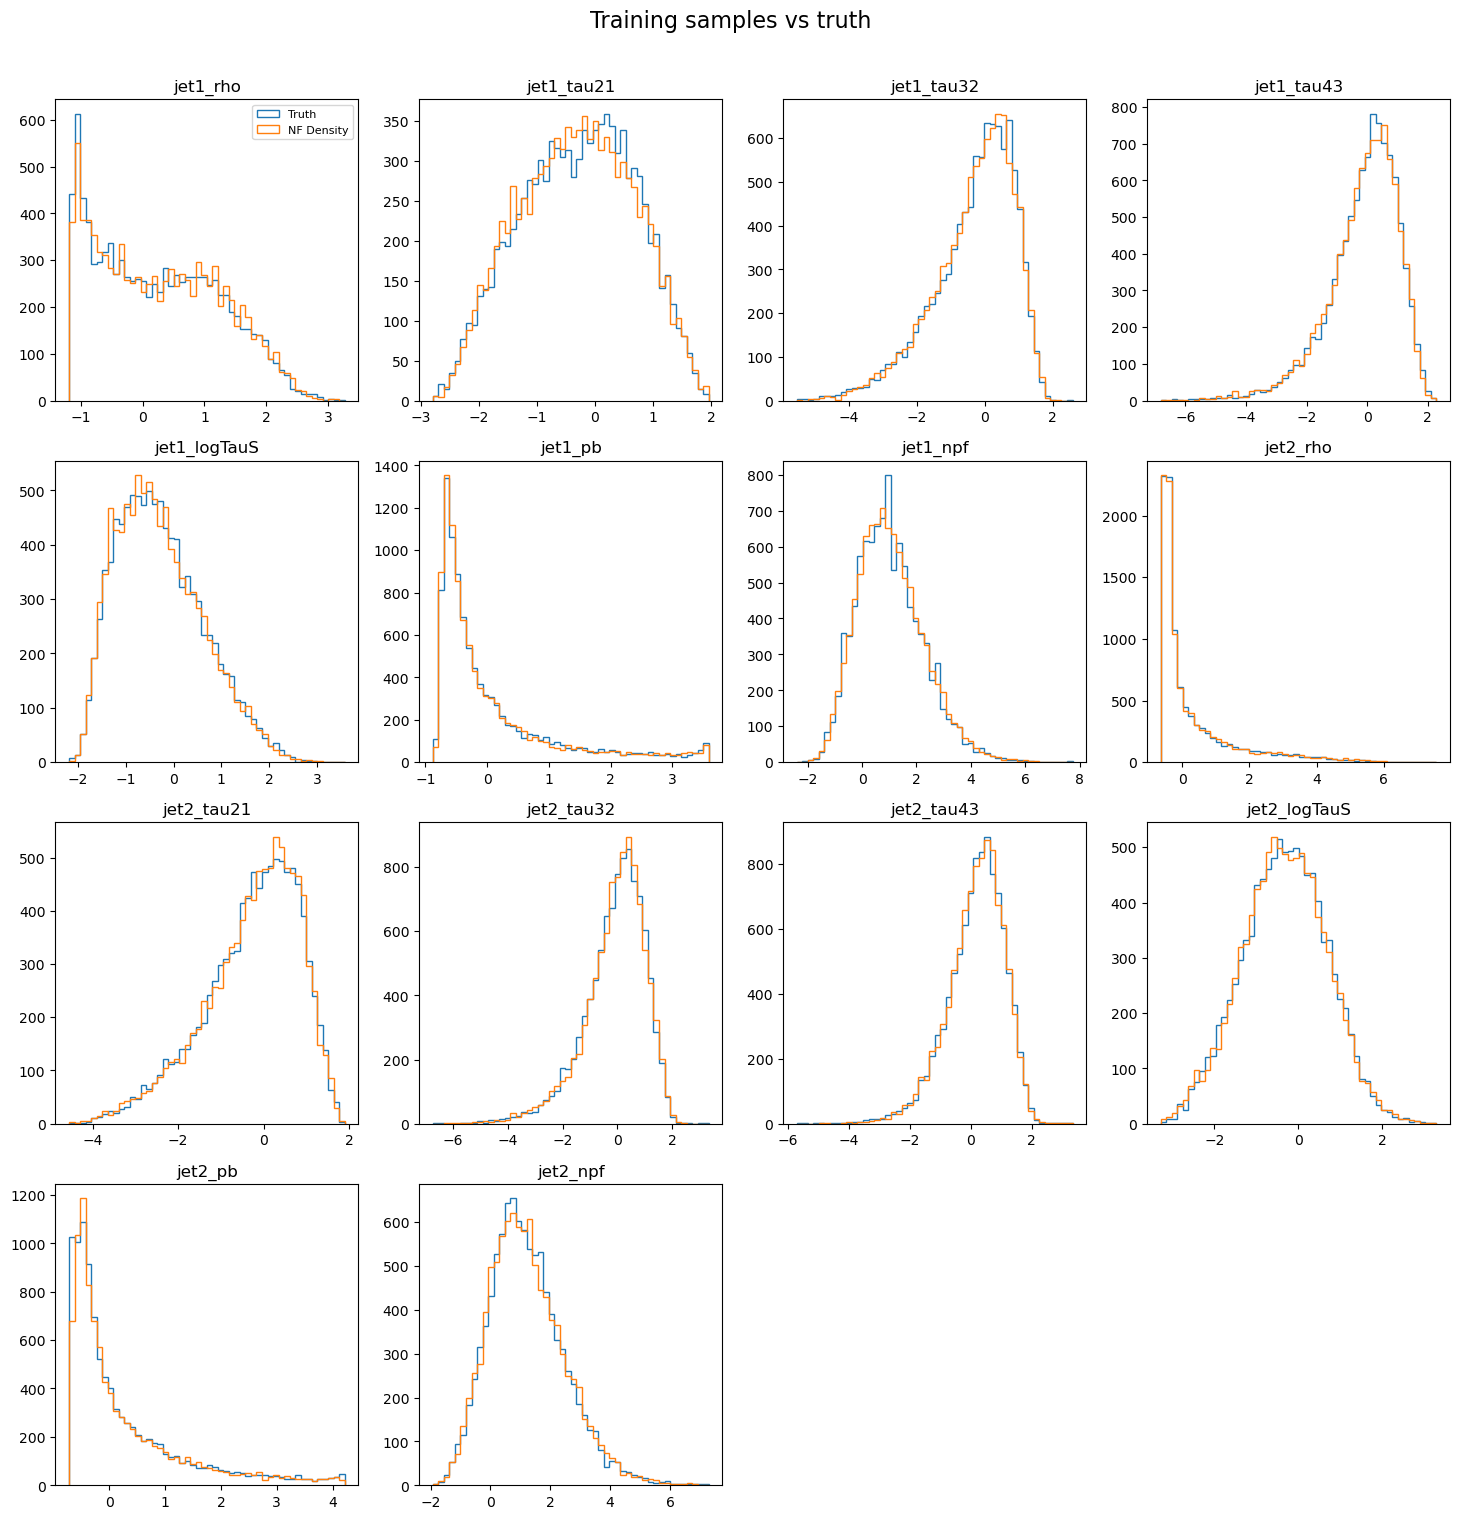

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 68.67it/s]


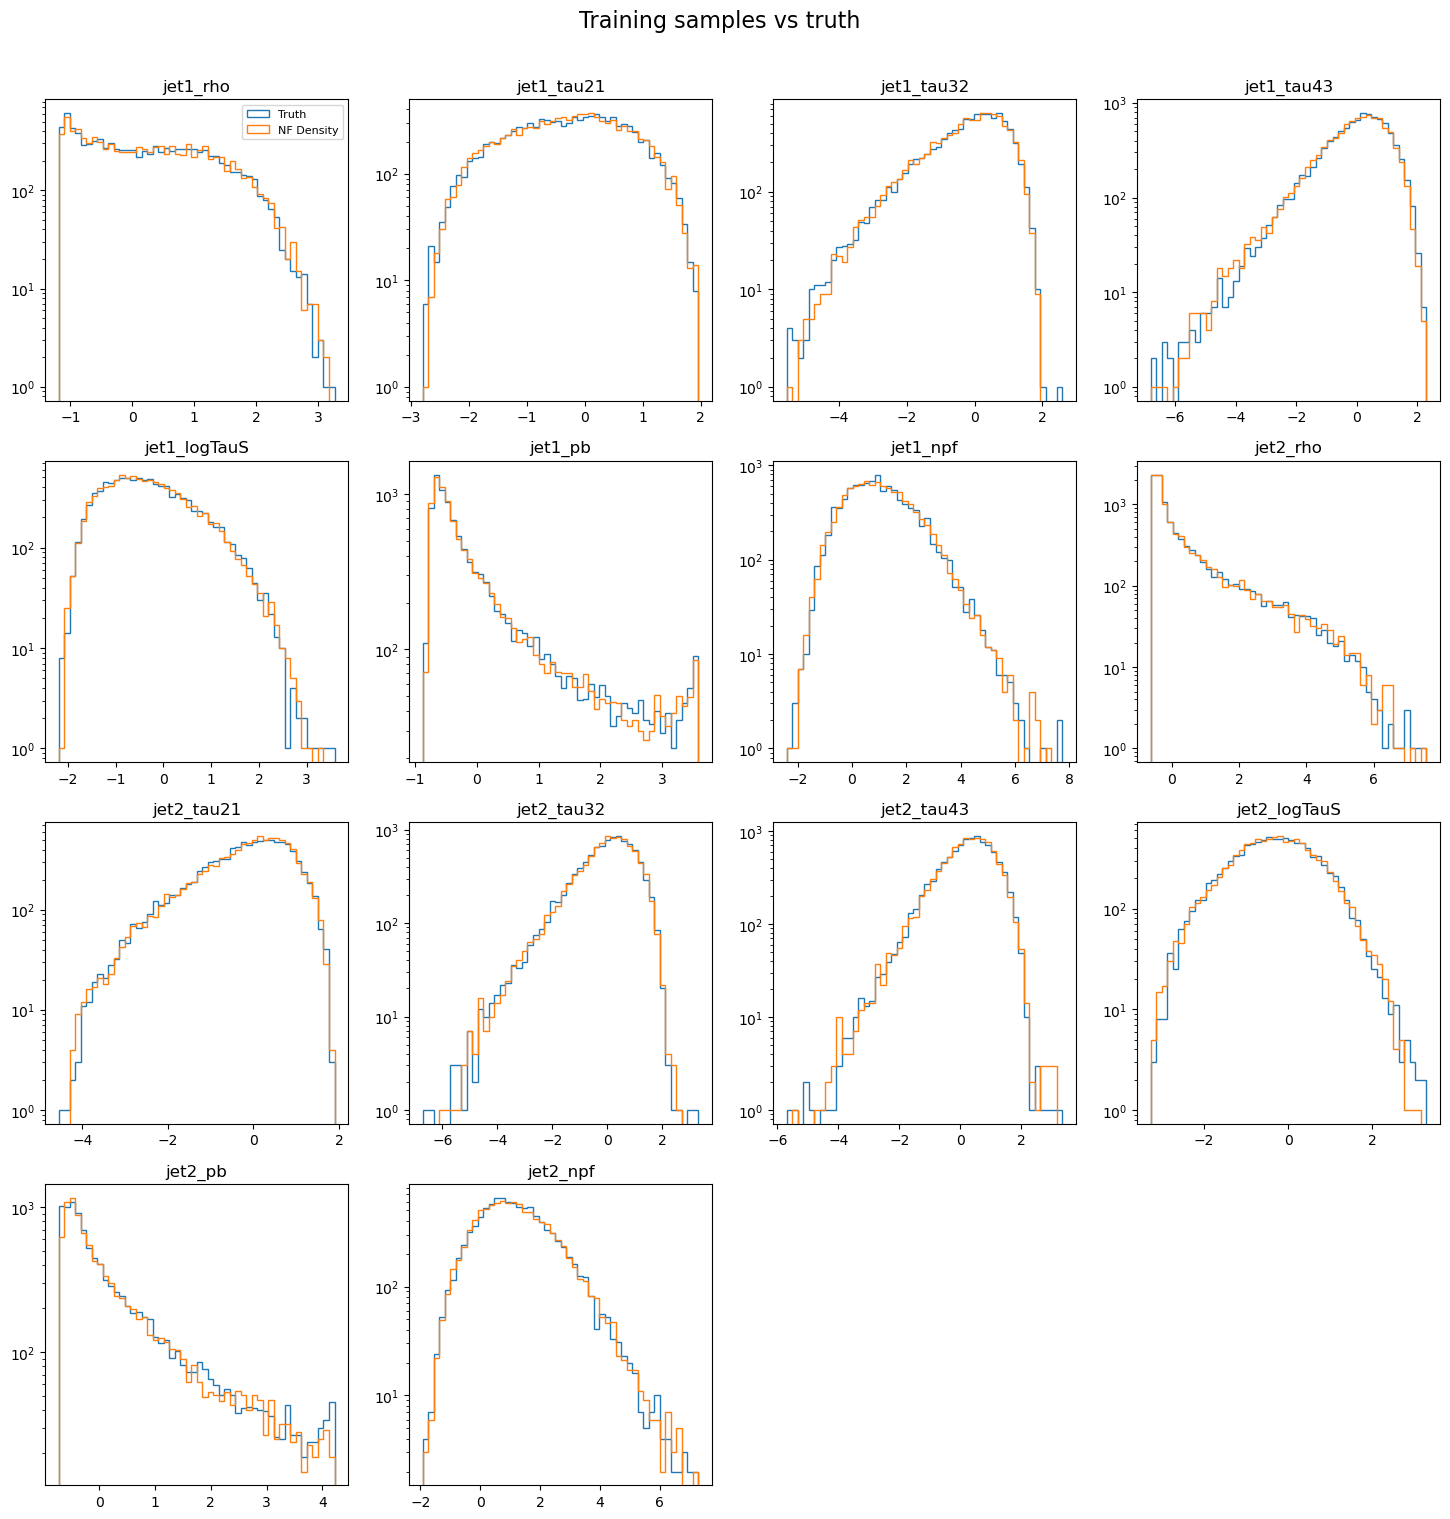

In [13]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":160,"num_layers":4,
             "num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "RSG3000"
reference = "BKG"
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=3000,n_epoch=200,patience=20,learning_rate=1e-4,T_max=50,eta_min=1e-5,print_interval=10)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 89.67it/s]


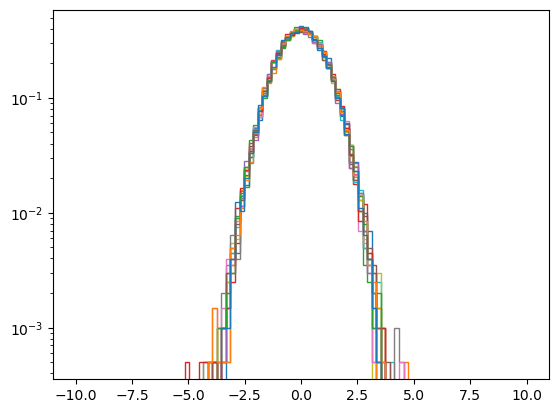

In [14]:
test = trainer.get_model().to(device)
data = trainer.loadData(10000,mode='test')
with torch.no_grad():
    samples = test.transform_to_noise(torch.tensor(data,dtype=torch.float32)).detach().cpu().numpy()
h = plt.hist(samples,histtype='step',density=True,bins=np.linspace(-10,10,100))
del test, data, samples
torch.cuda.empty_cache()
plt.yscale('log')

# 2017 Mixed Samples

114418 training events
Training flow XYY_X3000_Y80_UL17-and-Wp3000_B400_UL17-and-Qstar2000_W400_UL17
Iteration 10 Complete
Loss:  15.012701034545898
Iteration 20 Complete
Loss:  14.50737476348877
Iteration 30 Complete
Loss:  14.220305442810059
Iteration 40 Complete
Loss:  14.075905799865723
Iteration 50 Complete
Loss:  13.923693656921387
Iteration 60 Complete
Loss:  13.871459007263184
Iteration 70 Complete
Loss:  13.696602821350098
Iteration 80 Complete
Loss:  13.636523246765137
Iteration 90 Complete
Loss:  13.483439445495605
Iteration 100 Complete
Loss:  13.453718185424805
Iteration 110 Complete
Loss:  13.306290626525879
Iteration 120 Complete
Loss:  13.313313484191895
Iteration 130 Complete
Loss:  13.214077949523926
Iteration 140 Complete
Loss:  13.15955638885498
Iteration 150 Complete
Loss:  13.019516944885254
Iteration 160 Complete
Loss:  13.062255859375
Iteration 170 Complete
Loss:  12.981705665588379
Iteration 180 Complete
Loss:  12.920781135559082
Iteration 190 Complete
Loss:  1

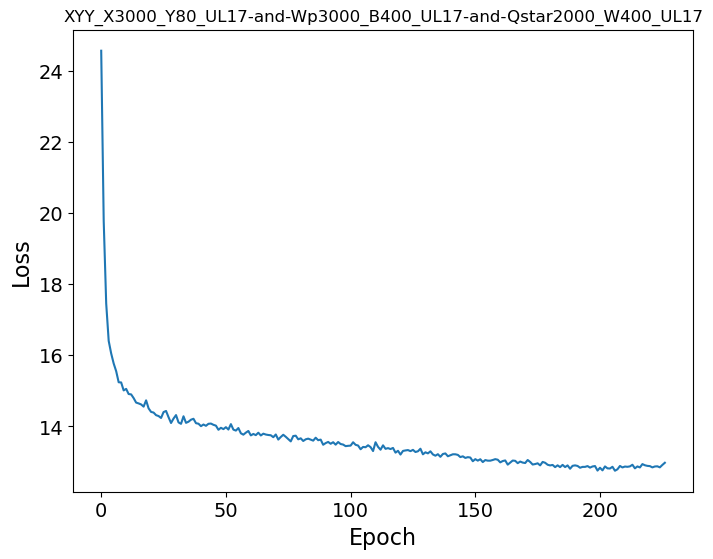

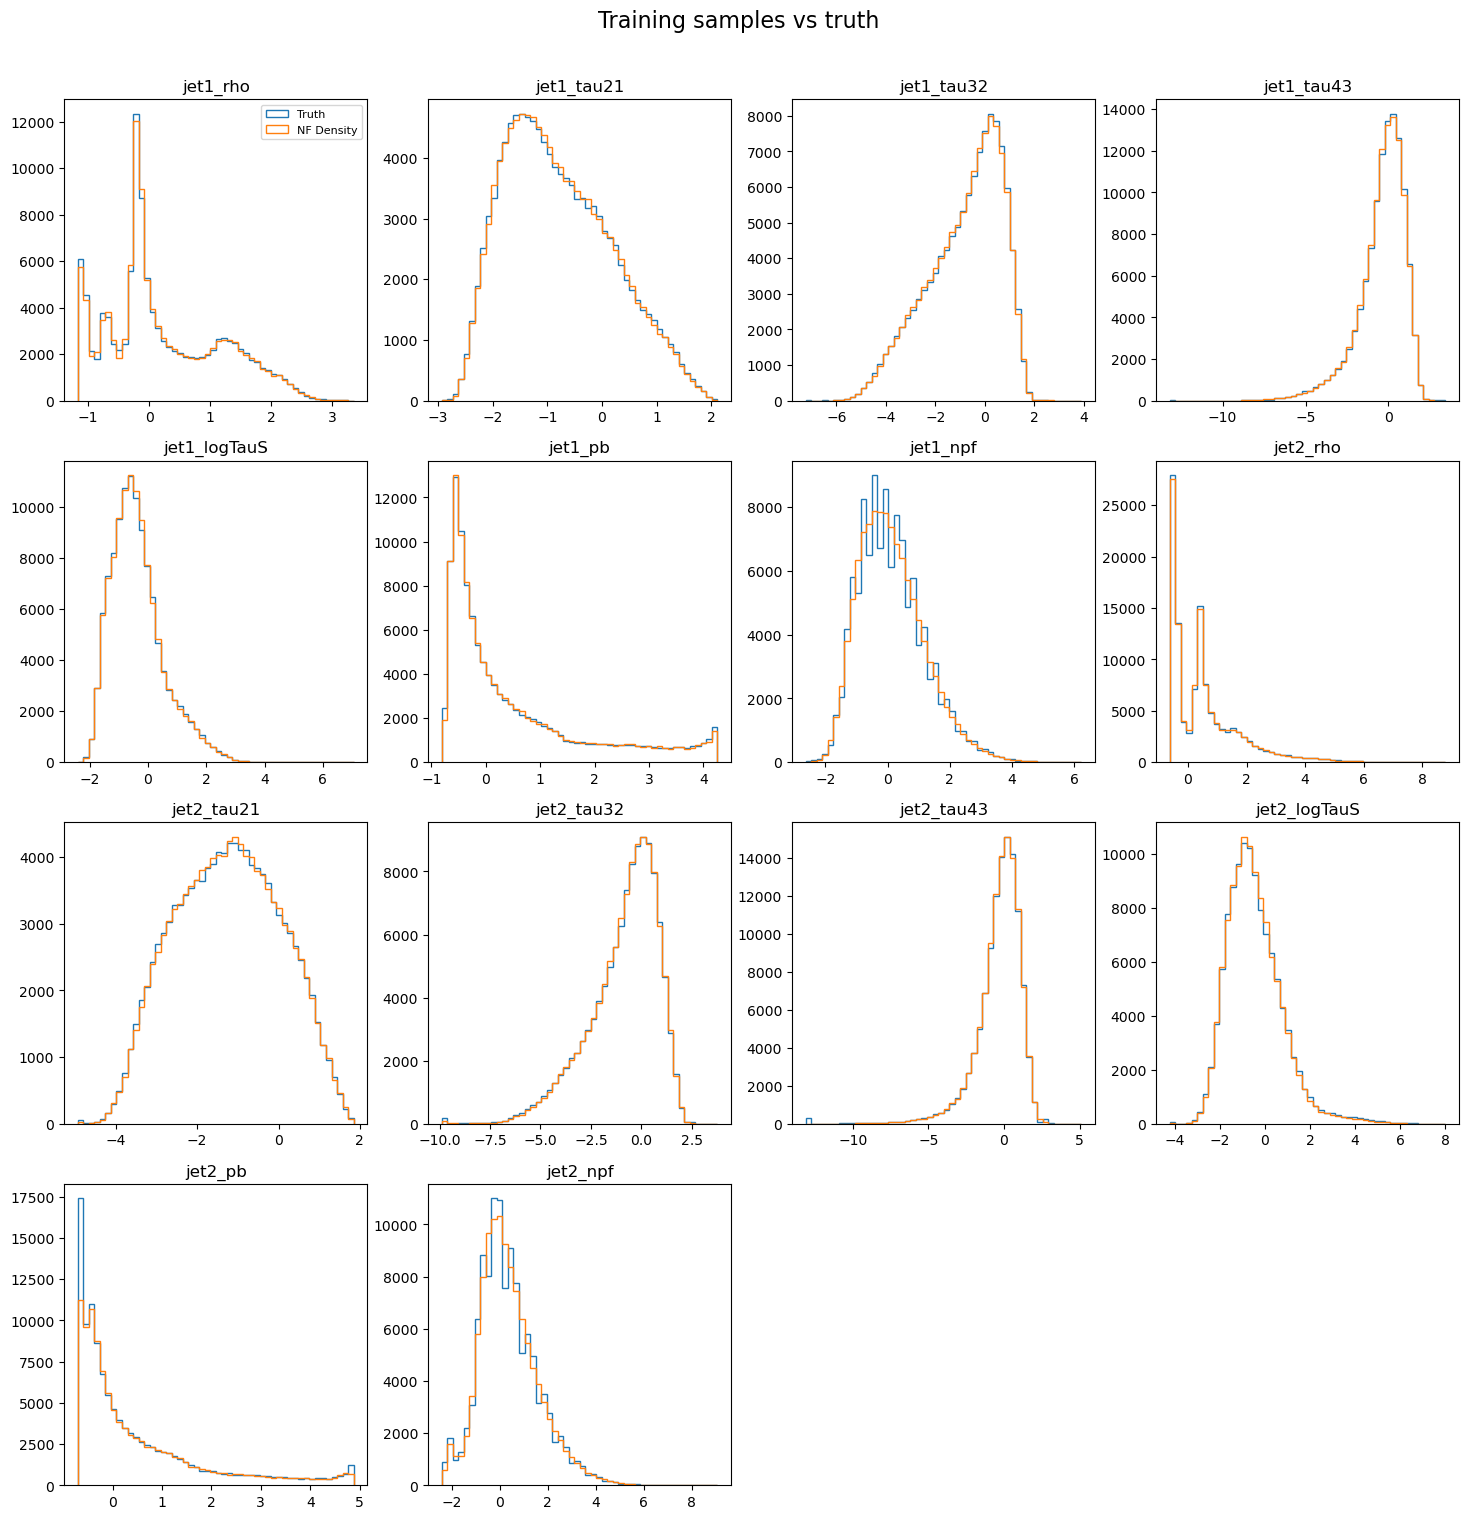

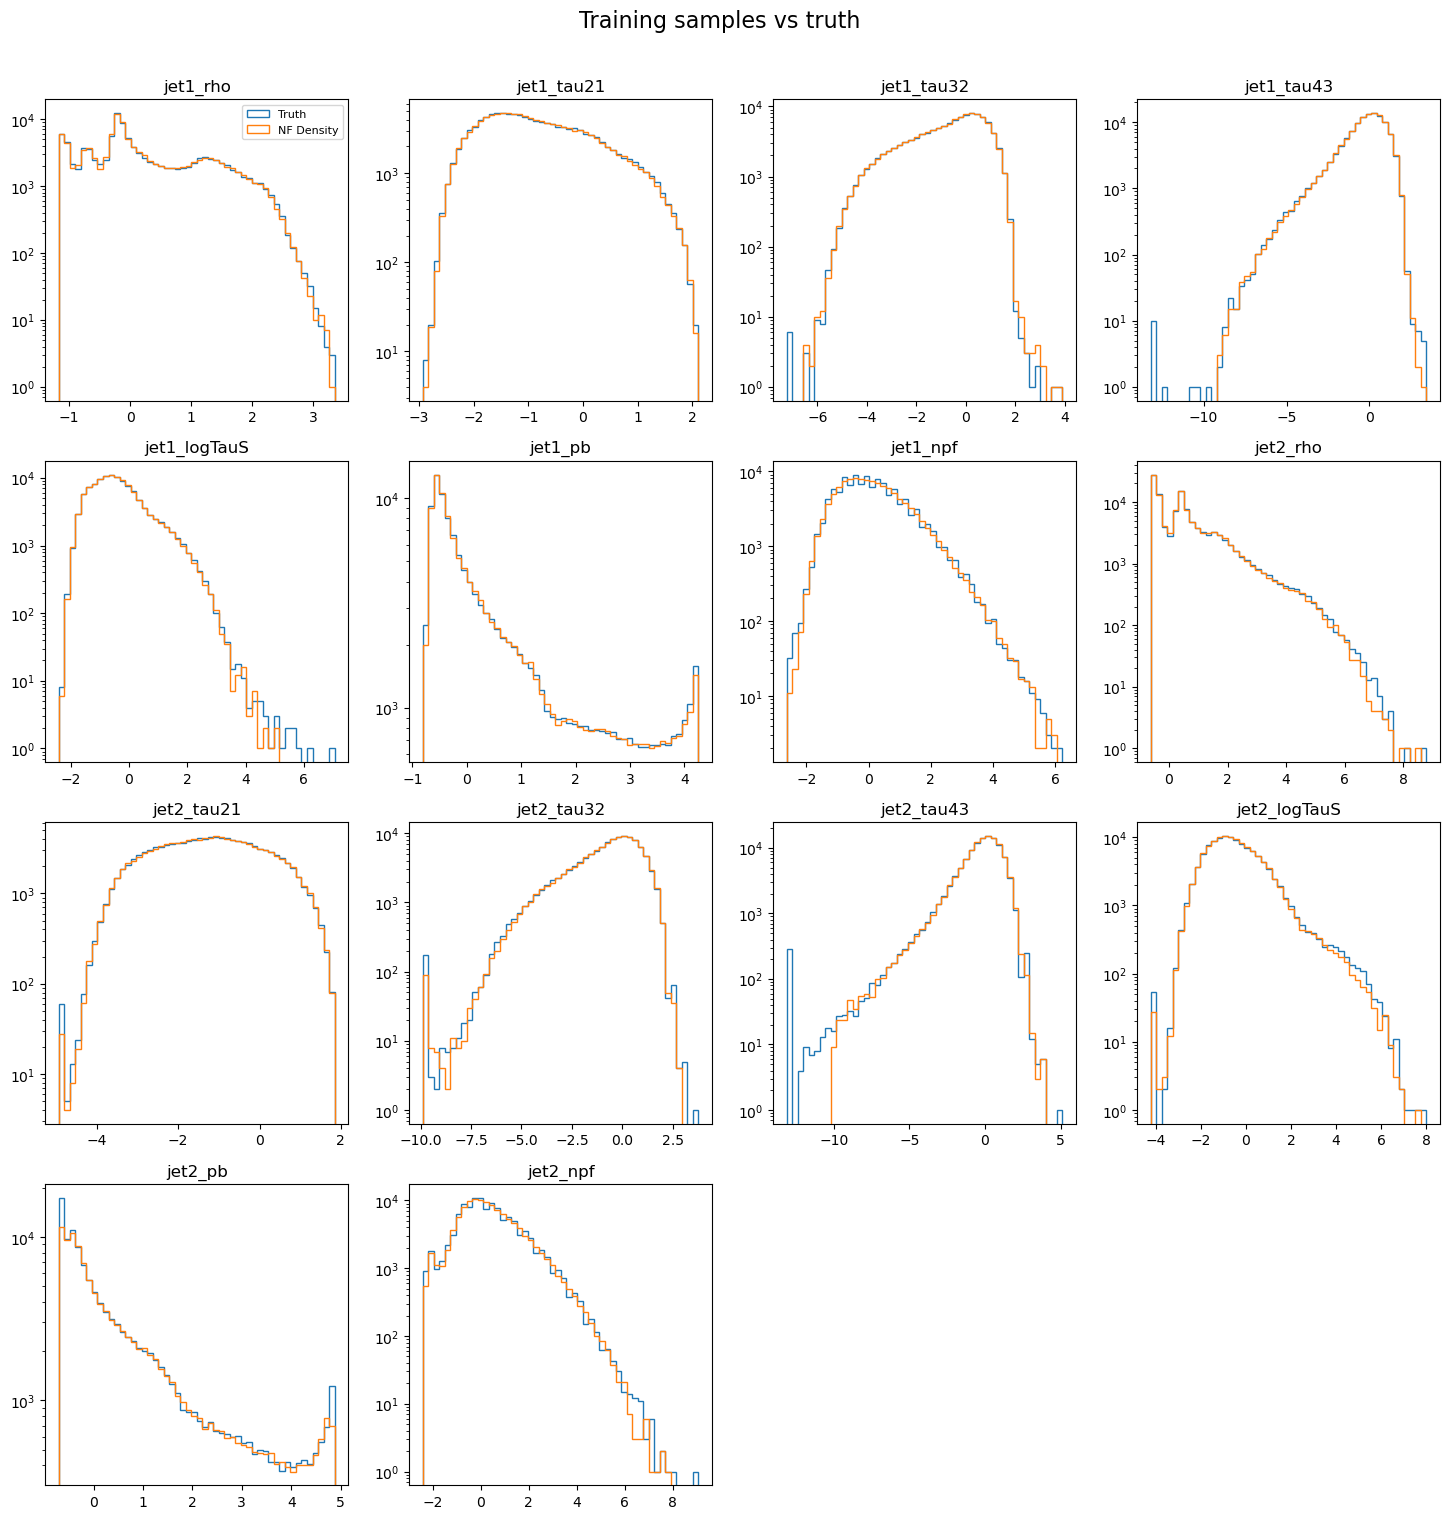

In [2]:
# XYY_X3000_Y80_UL17 + Wp3000_B400_UL17 + Qstar2000_W400_UL17
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":250,
             "num_layers":6,"num_bins":40,"num_blocks_per_layer":4}
sample = ["XYY_X3000_Y80_UL17","Wp3000_B400_UL17","Qstar2000_W400_UL17"]
reference = "QCDBKG"
year = 2017
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 1000000
trainer = NFTrainer(sample,reference,year,variables,nTrain=nTrain,NF_kwargs=NF_kwargs)
trainer.train(bs=10000,n_epoch=400,patience=20,learning_rate=1e-3,eta_min=1e-5,print_interval=10,clip=15)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

# Combined trainings based on daughter mass, 2 & 3 TeV resonances

In [10]:
from samples import daughterGroups_2and3TeV
print(daughterGroups_2and3TeV.keys())

dict_keys(['M25-25', 'M25-80', 'M25-170', 'M25-400', 'M80-80', 'M80-170', 'M80-400', 'M170-170', 'M170-400', 'M400-400'])


Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


100000 training events
Training flow M25-25_noRho
Iteration 10 Complete
Loss:  13.78077507019043
Iteration 20 Complete
Loss:  12.882967948913574
Iteration 30 Complete
Loss:  12.489179611206055
Iteration 40 Complete
Loss:  12.327198028564453
Iteration 50 Complete
Loss:  12.222293853759766
Iteration 60 Complete
Loss:  12.187568664550781
Iteration 70 Complete
Loss:  12.121227264404297
Iteration 80 Complete
Loss:  12.022789001464844
Iteration 90 Complete
Loss:  11.894920349121094
Iteration 100 Complete
Loss:  11.899168014526367
Iteration 110 Complete
Loss:  11.775192260742188
Iteration 120 Complete
Loss:  11.681395530700684
Iteration 130 Complete
Loss:  11.612767219543457
Iteration 140 Complete
Loss:  11.538846015930176
Iteration 150 Complete
Loss:  11.541378021240234
Iteration 160 Complete
Loss:  11.485368728637695
Iteration 170 Complete
Loss:  11.639097213745117
Iteration 180 Complete
Loss:  11.575109481811523
Loading test sample


100%|██████████| 1/1 [00:00<00:00,  5.21it/s]


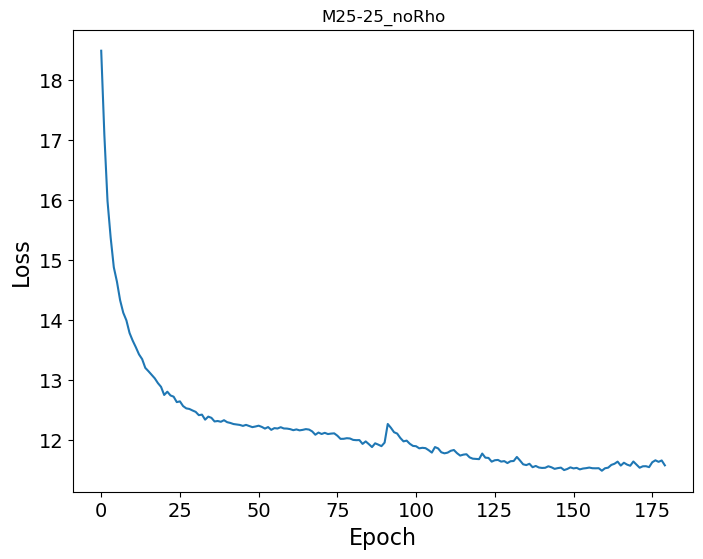

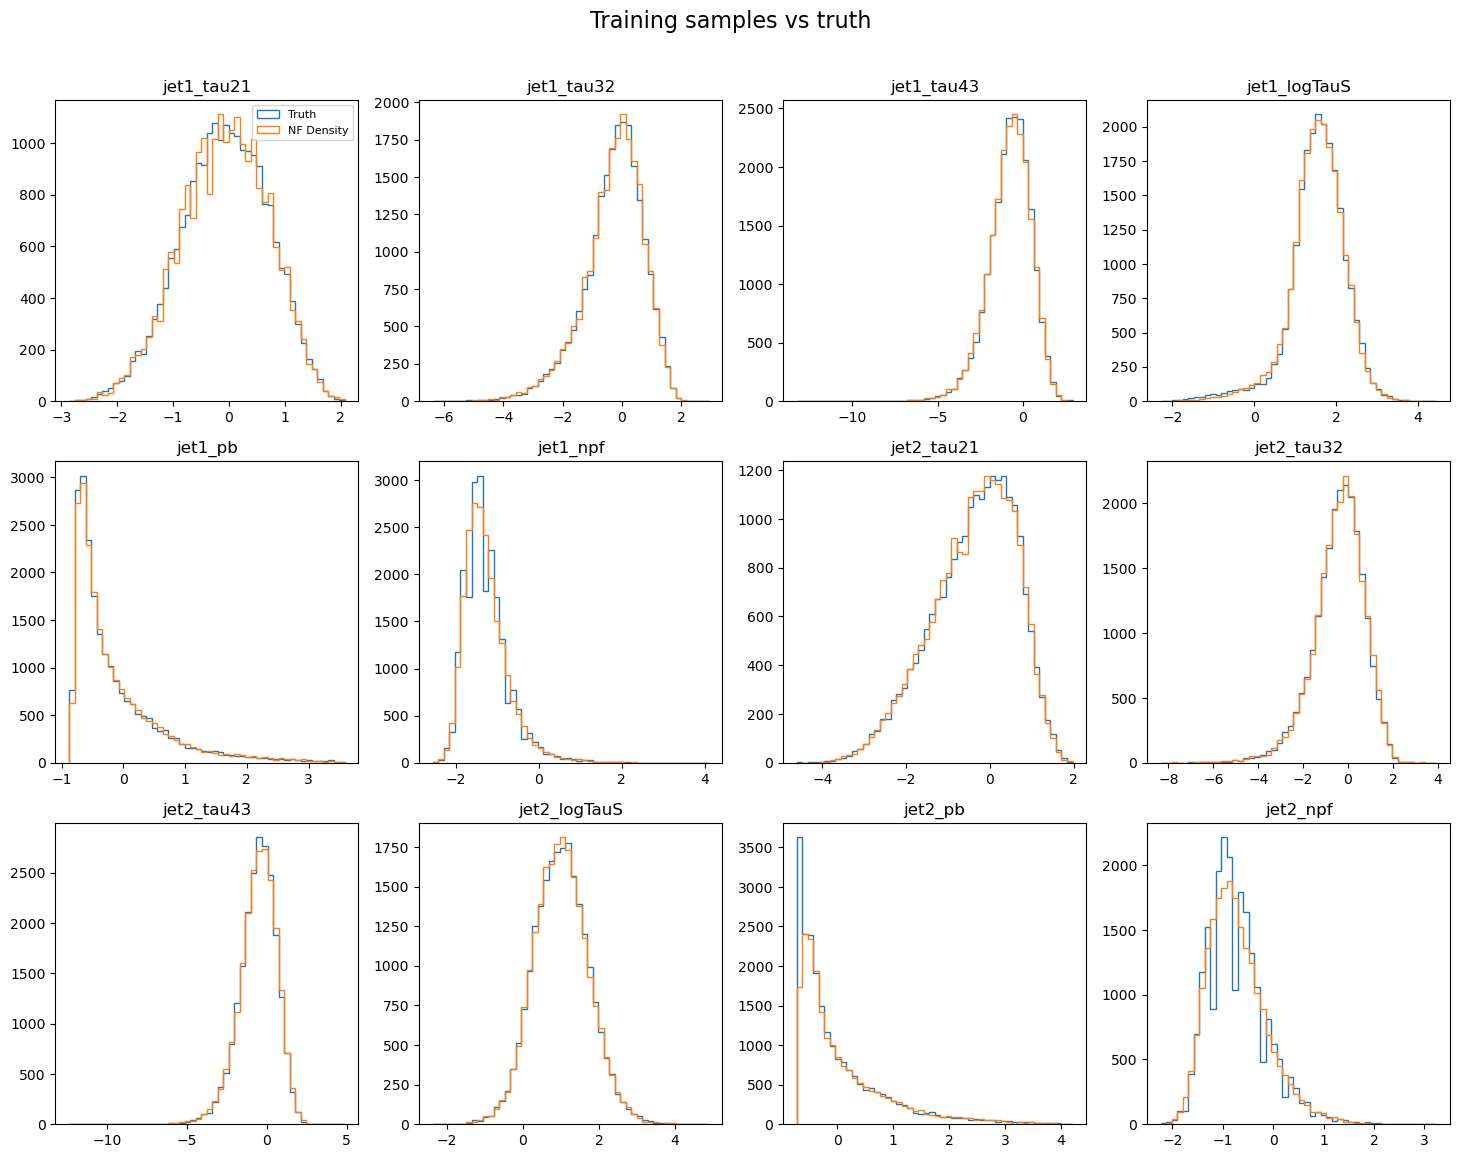

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 83.17it/s]


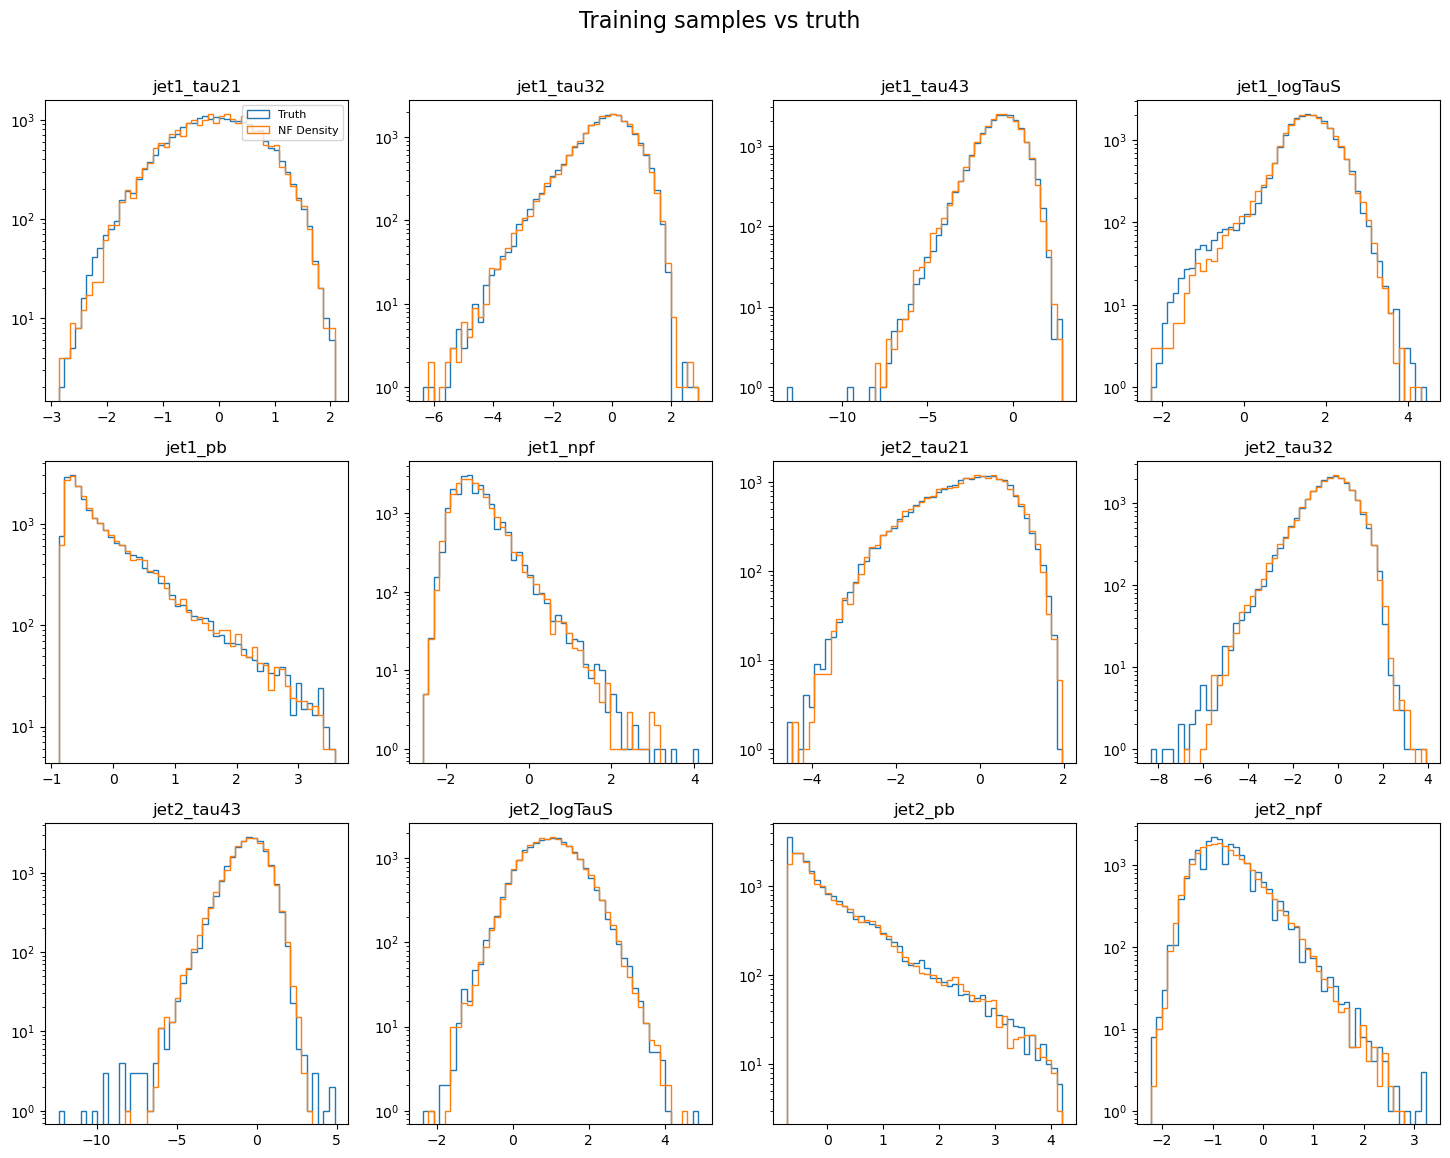

In [11]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M25-25"
modelName = "M25-25_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


99999 training events
Training flow M25-80_noRho
Iteration 10 Complete
Loss:  14.277141571044922
Iteration 20 Complete
Loss:  13.395774841308594
Iteration 30 Complete
Loss:  13.032417297363281
Iteration 40 Complete
Loss:  12.89132308959961
Iteration 50 Complete
Loss:  12.835352897644043
Iteration 60 Complete
Loss:  12.777724266052246
Iteration 70 Complete
Loss:  12.695243835449219
Iteration 80 Complete
Loss:  12.571160316467285
Iteration 90 Complete
Loss:  12.60940933227539
Iteration 100 Complete
Loss:  12.443778038024902
Iteration 110 Complete
Loss:  12.287053108215332
Iteration 120 Complete
Loss:  12.267030715942383
Iteration 130 Complete
Loss:  12.403010368347168
Iteration 140 Complete
Loss:  12.296510696411133
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 84.17it/s]


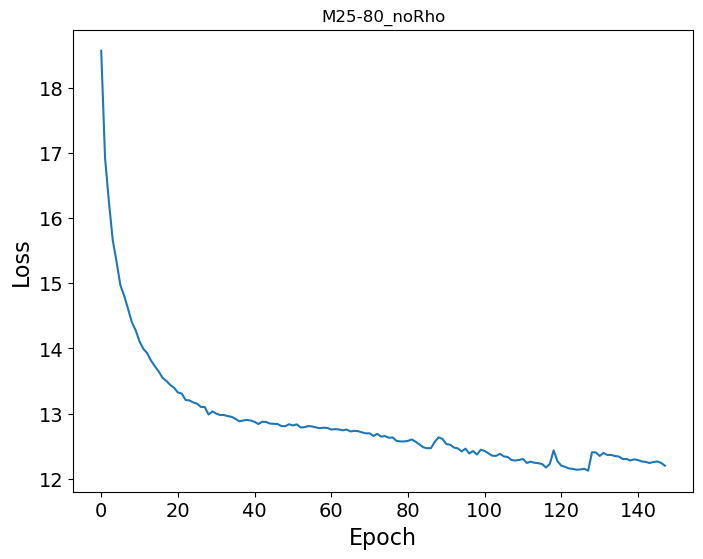

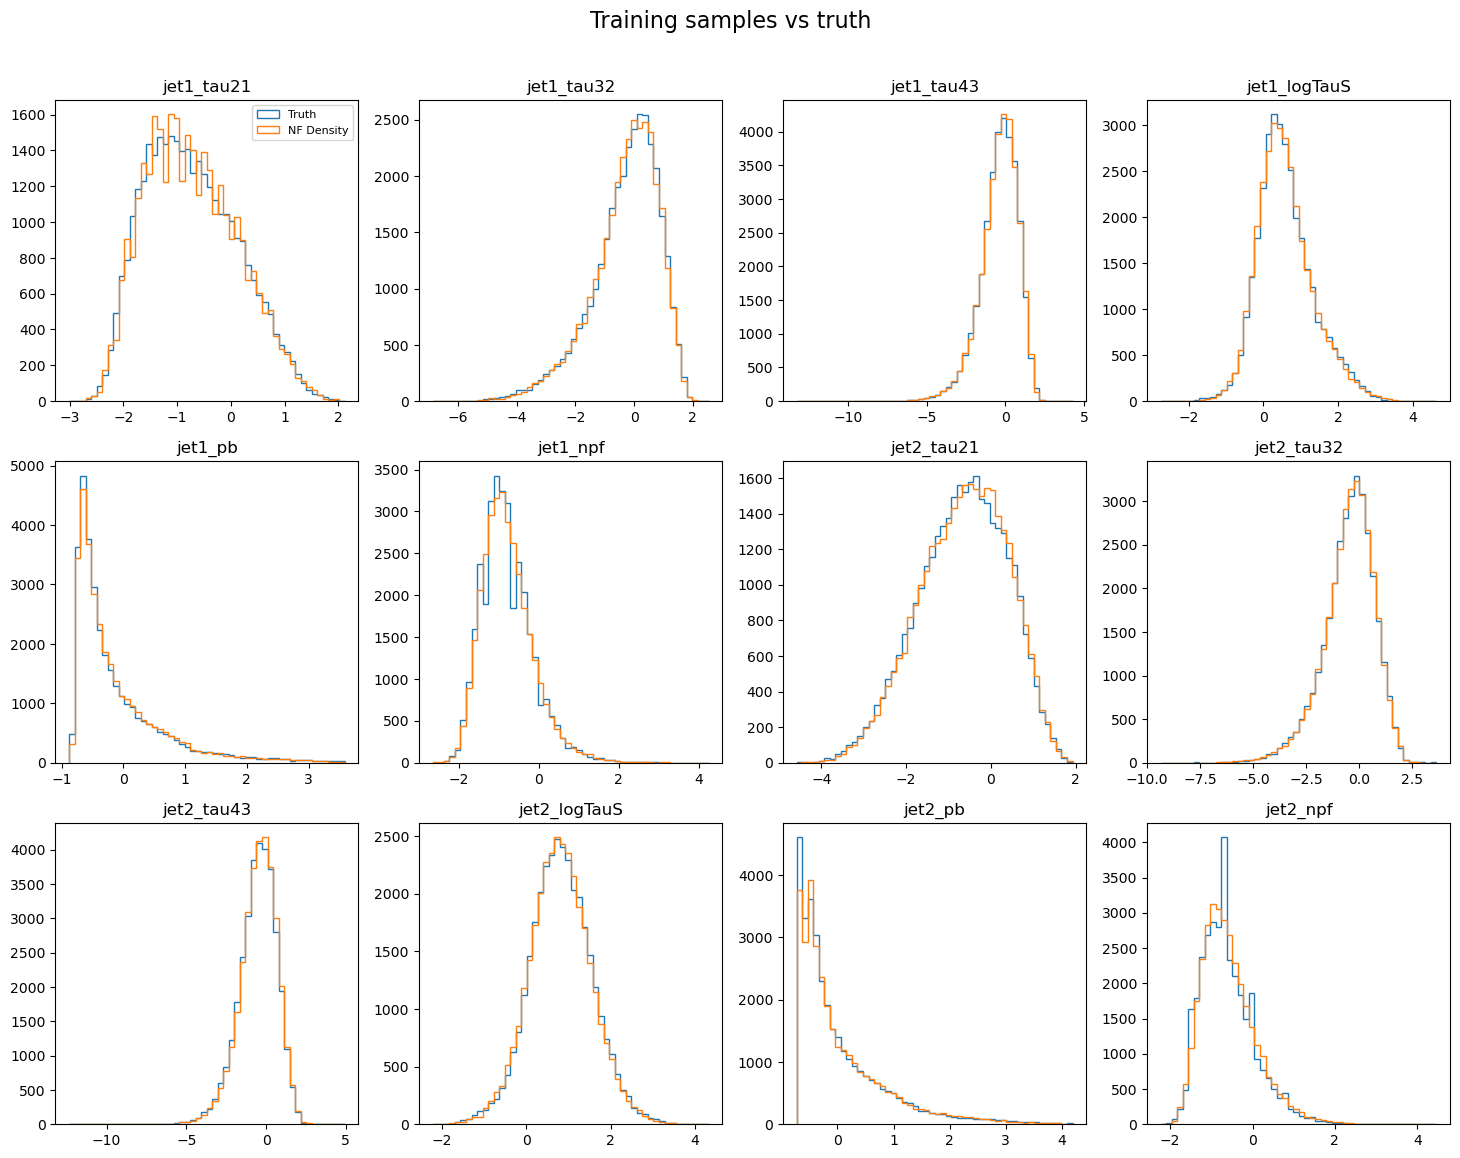

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 80.53it/s]


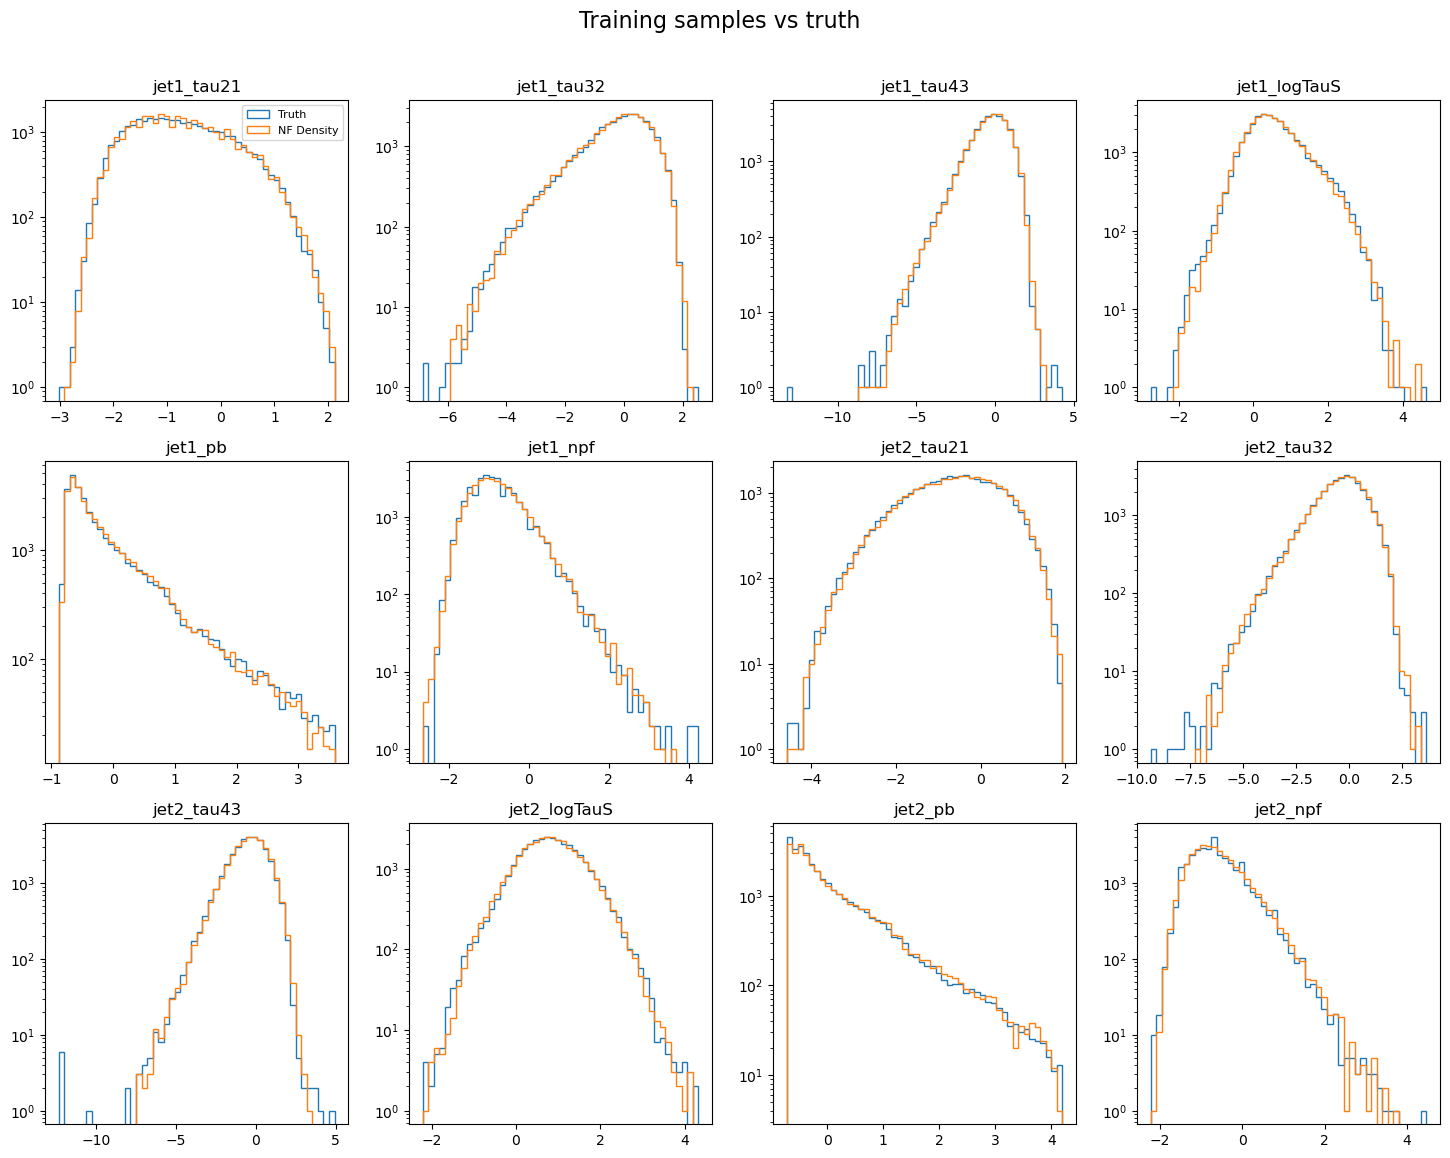

In [12]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M25-80"
modelName = "M25-80_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


99999 training events
Training flow M25-170_noRho
Iteration 10 Complete
Loss:  17.32504653930664
Iteration 20 Complete
Loss:  16.261926651000977
Iteration 30 Complete
Loss:  15.830596923828125
Iteration 40 Complete
Loss:  15.63284683227539
Iteration 50 Complete
Loss:  15.538984298706055
Iteration 60 Complete
Loss:  15.485771179199219
Iteration 70 Complete
Loss:  15.406742095947266
Iteration 80 Complete
Loss:  15.239462852478027
Iteration 90 Complete
Loss:  15.078105926513672
Iteration 100 Complete
Loss:  14.935293197631836
Iteration 110 Complete
Loss:  14.845282554626465
Iteration 120 Complete
Loss:  14.750494956970215
Iteration 130 Complete
Loss:  14.679971694946289
Iteration 140 Complete
Loss:  14.645232200622559
Iteration 150 Complete
Loss:  14.632271766662598
Iteration 160 Complete
Loss:  14.629040718078613
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 10.97it/s]


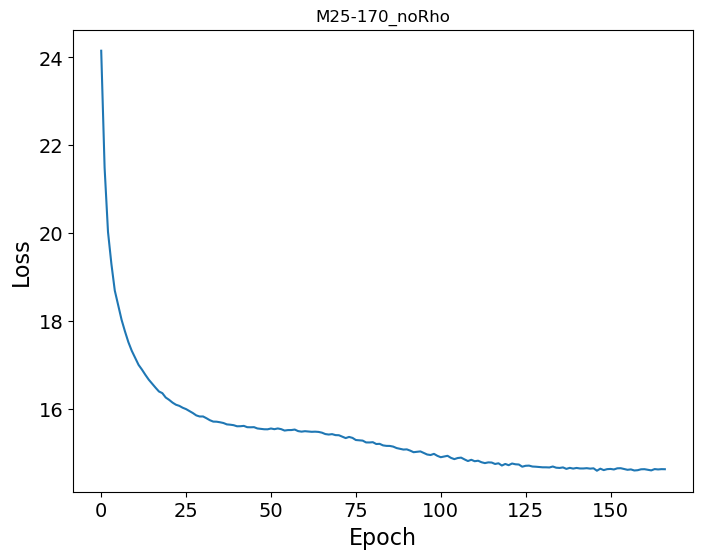

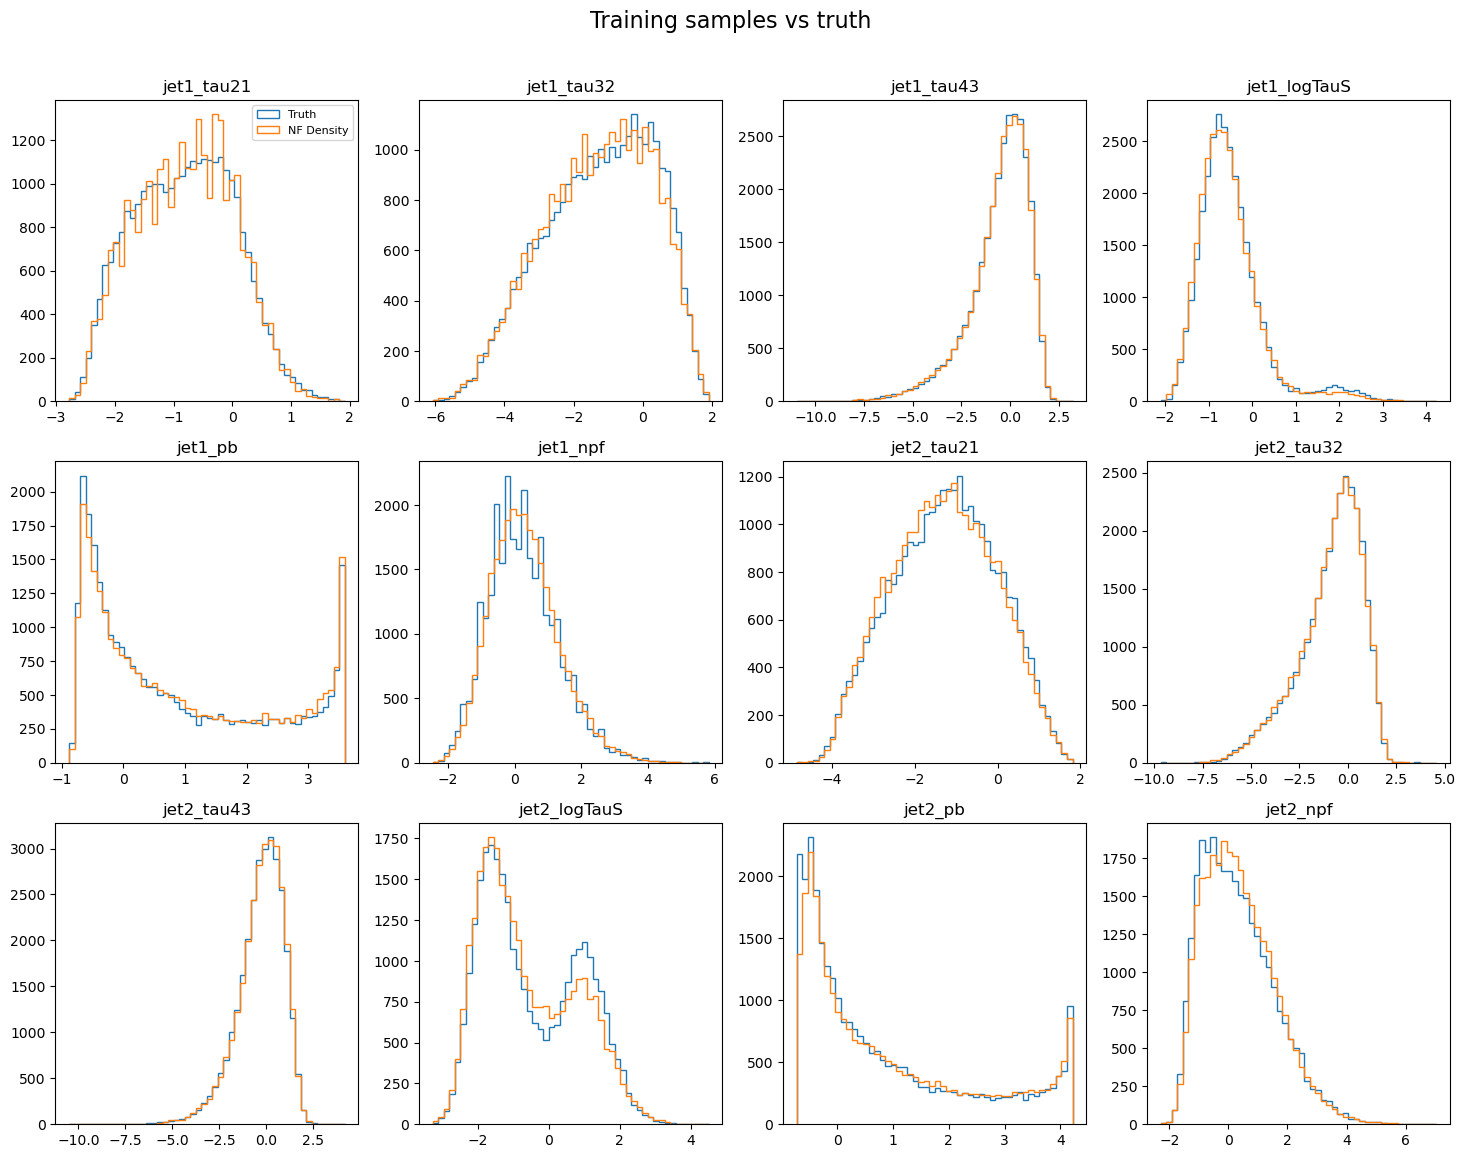

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 80.34it/s]


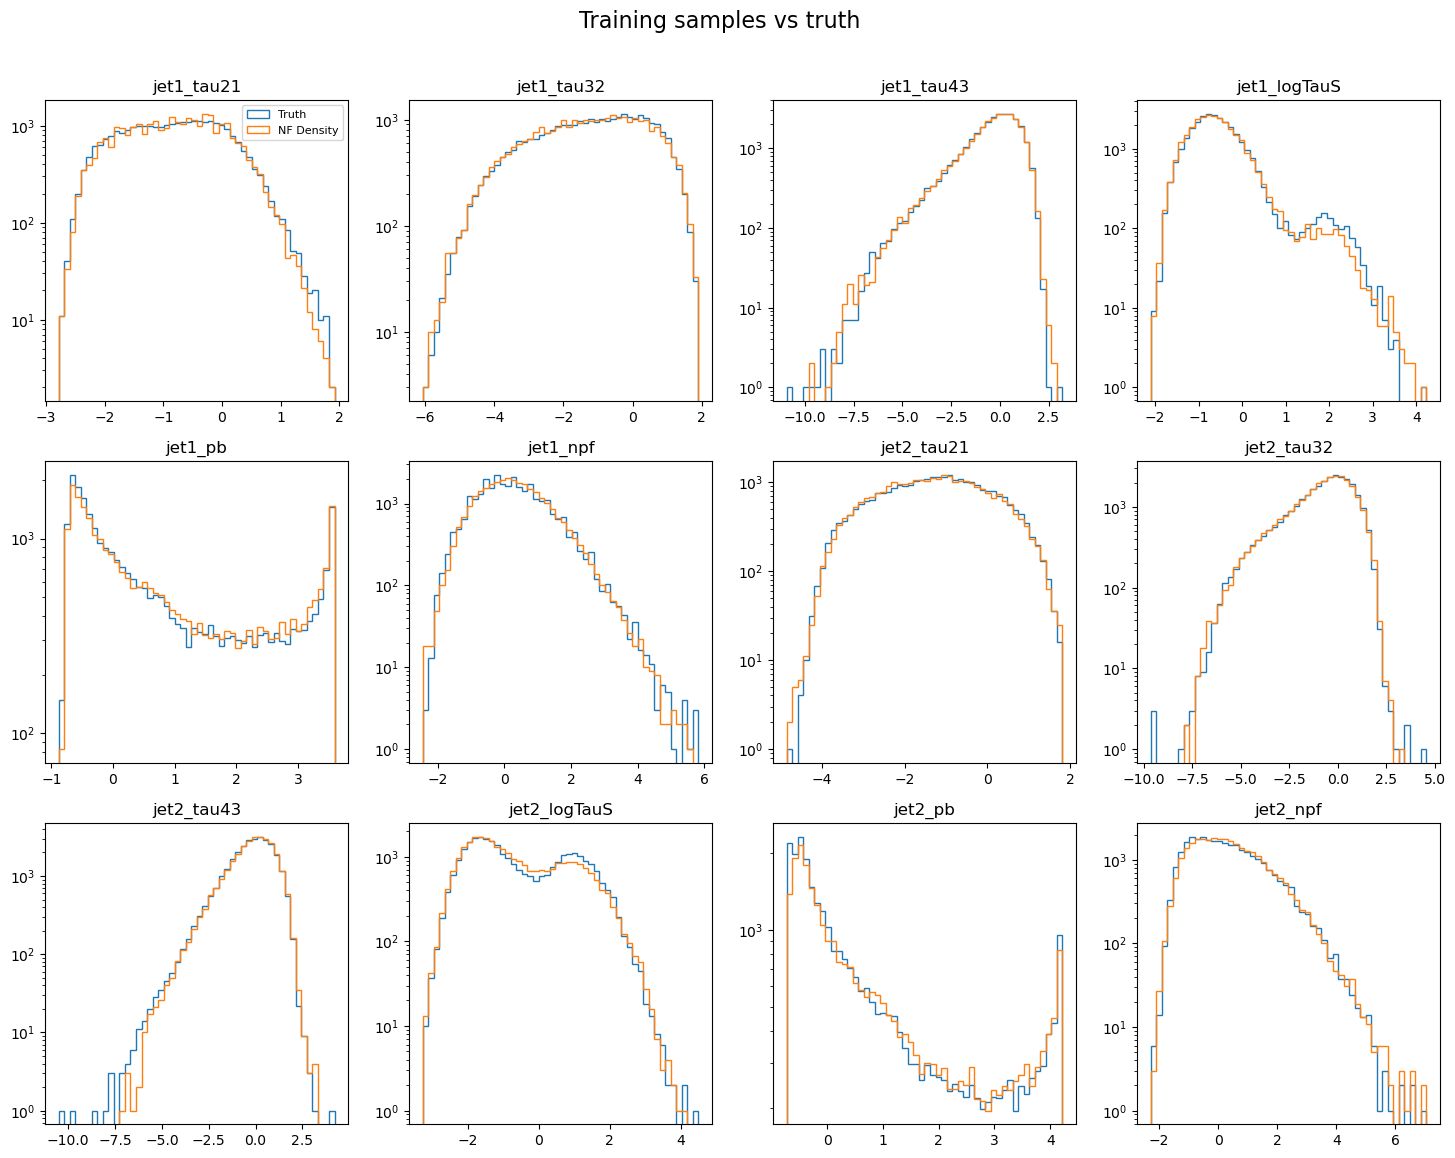

In [13]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M25-170"
modelName = "M25-170_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


99999 training events
Training flow M25-400_noRho
Iteration 10 Complete
Loss:  14.921009063720703
Iteration 20 Complete
Loss:  13.875664710998535
Iteration 30 Complete
Loss:  13.440329551696777
Iteration 40 Complete
Loss:  13.304134368896484
Iteration 50 Complete
Loss:  13.210090637207031
Iteration 60 Complete
Loss:  13.103924751281738
Iteration 70 Complete
Loss:  13.021419525146484
Iteration 80 Complete
Loss:  12.986750602722168
Iteration 90 Complete
Loss:  12.821678161621094
Iteration 100 Complete
Loss:  12.755526542663574
Iteration 110 Complete
Loss:  12.649213790893555
Iteration 120 Complete
Loss:  12.545095443725586
Iteration 130 Complete
Loss:  12.442057609558105
Iteration 140 Complete
Loss:  12.41425895690918
Iteration 150 Complete
Loss:  12.378453254699707
Iteration 160 Complete
Loss:  12.304178237915039
Iteration 170 Complete
Loss:  12.393678665161133
Iteration 180 Complete
Loss:  12.381682395935059
Loading test sample


100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


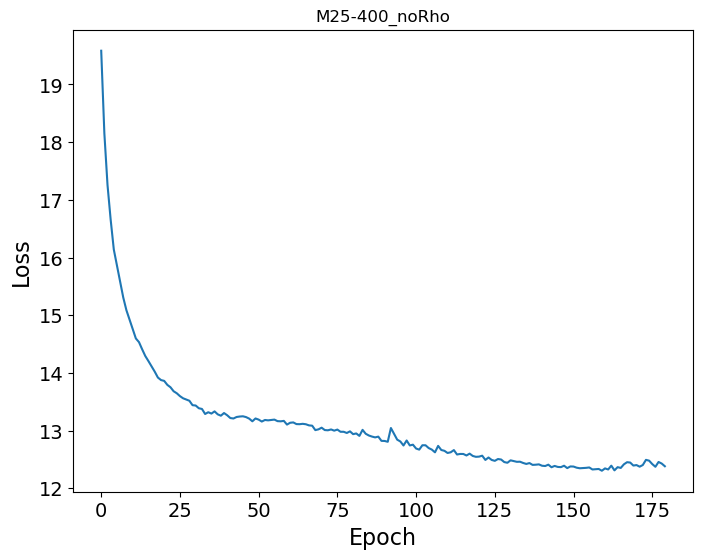

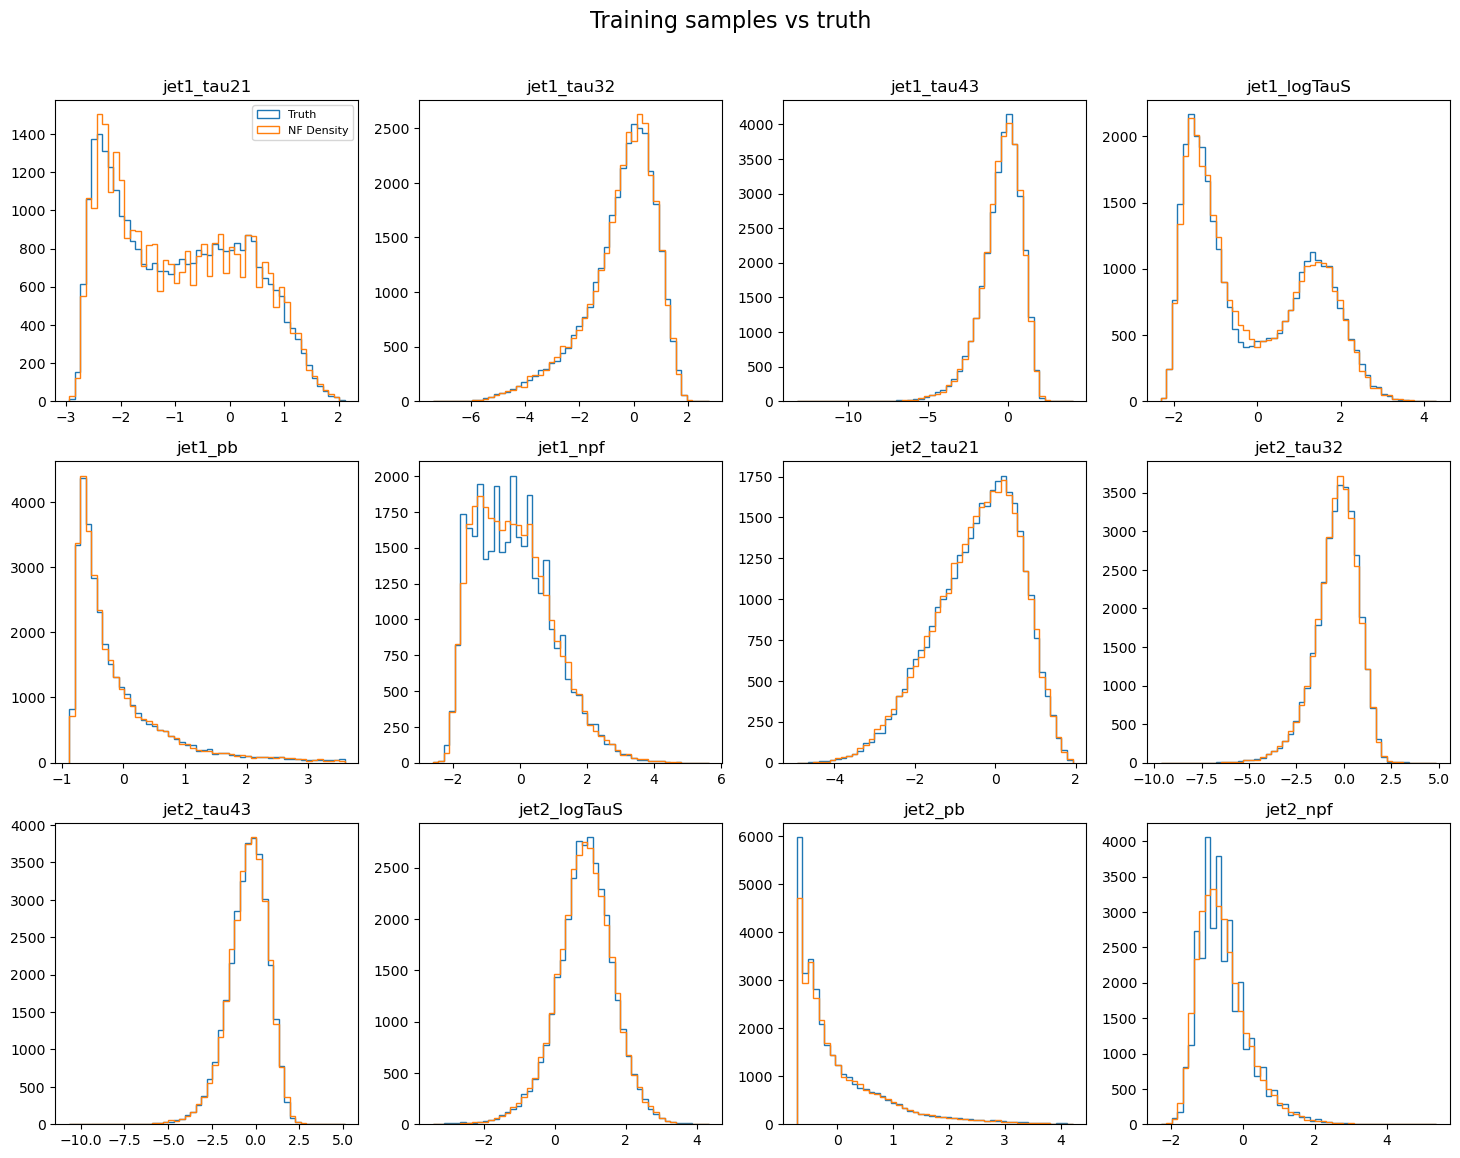

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 73.54it/s]


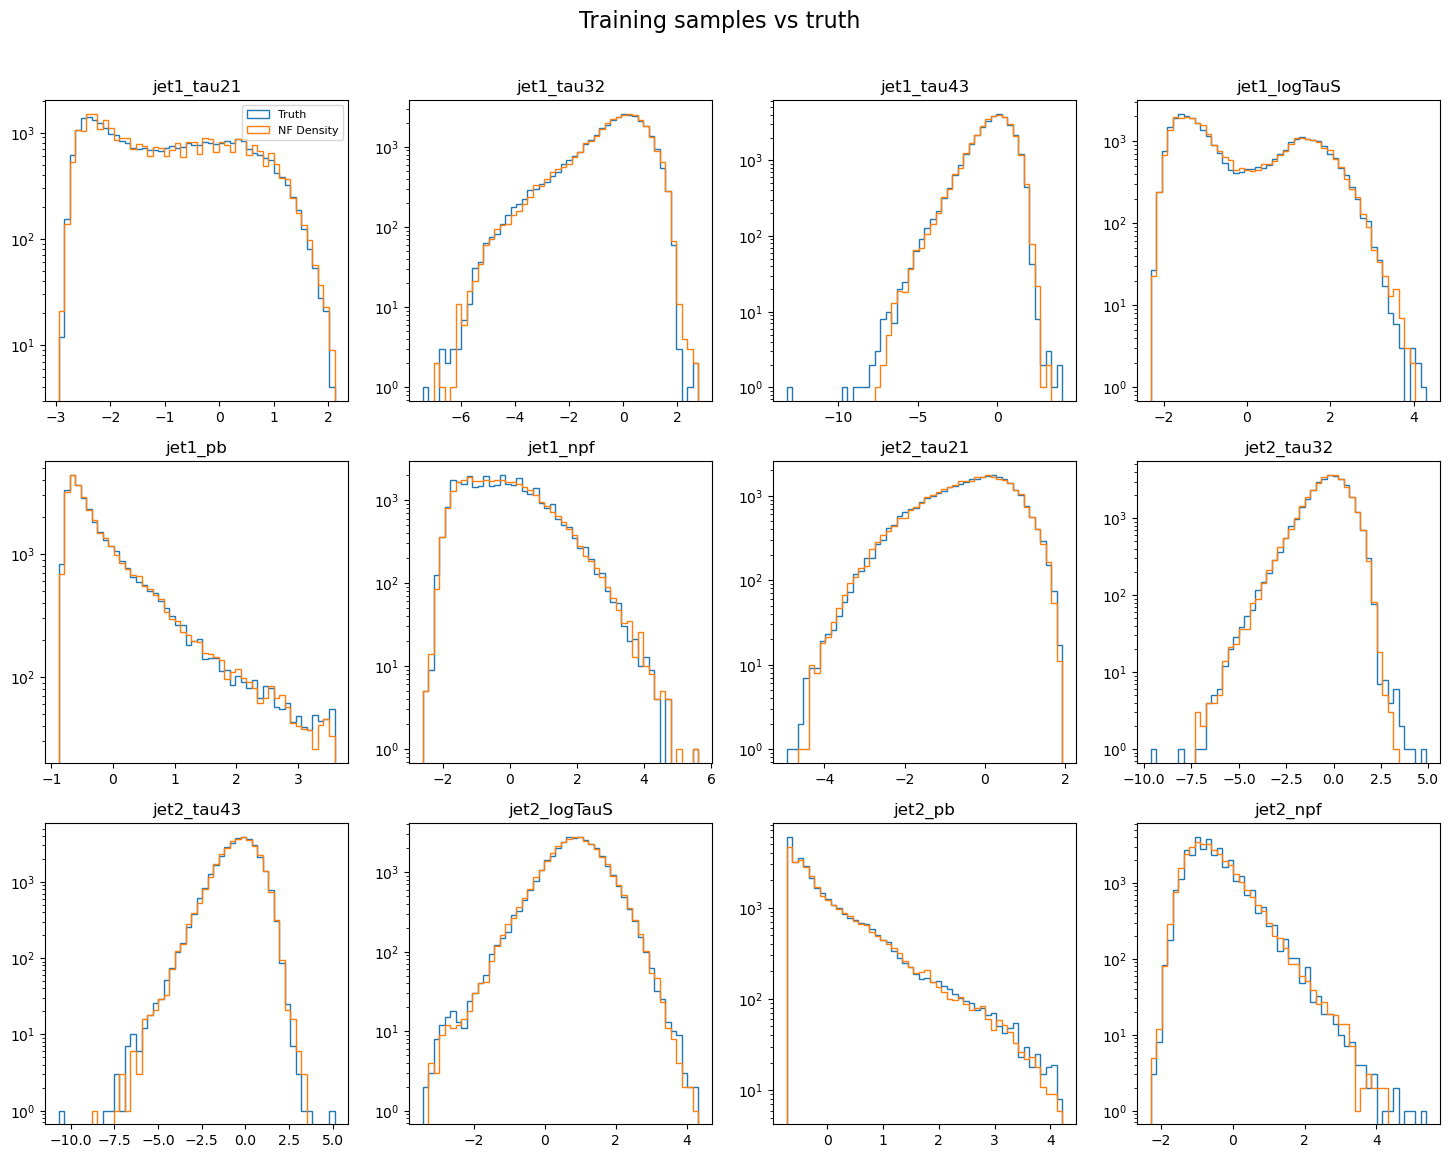

In [14]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M25-400"
modelName = "M25-400_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


98862 training events
Training flow M80-80_noRho
Iteration 10 Complete
Loss:  13.267398834228516
Iteration 20 Complete
Loss:  12.268540382385254
Iteration 30 Complete
Loss:  11.939221382141113
Iteration 40 Complete
Loss:  11.779047966003418
Iteration 50 Complete
Loss:  11.716229438781738
Iteration 60 Complete
Loss:  11.680663108825684
Iteration 70 Complete
Loss:  11.640124320983887
Iteration 80 Complete
Loss:  11.529054641723633
Iteration 90 Complete
Loss:  11.404922485351562
Iteration 100 Complete
Loss:  11.350172996520996
Iteration 110 Complete
Loss:  11.234915733337402
Iteration 120 Complete
Loss:  11.174190521240234
Iteration 130 Complete
Loss:  11.111220359802246
Iteration 140 Complete
Loss:  11.040644645690918
Iteration 150 Complete
Loss:  11.04854679107666
Iteration 160 Complete
Loss:  11.0429048538208
Iteration 170 Complete
Loss:  11.063243865966797
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 17.13it/s]


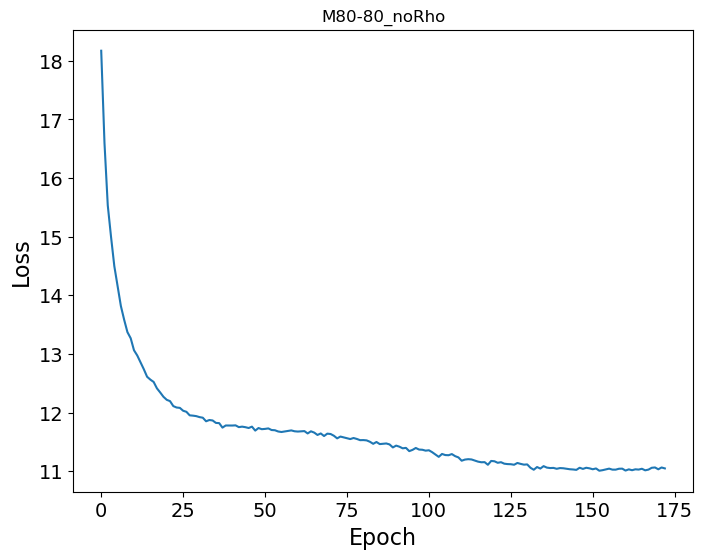

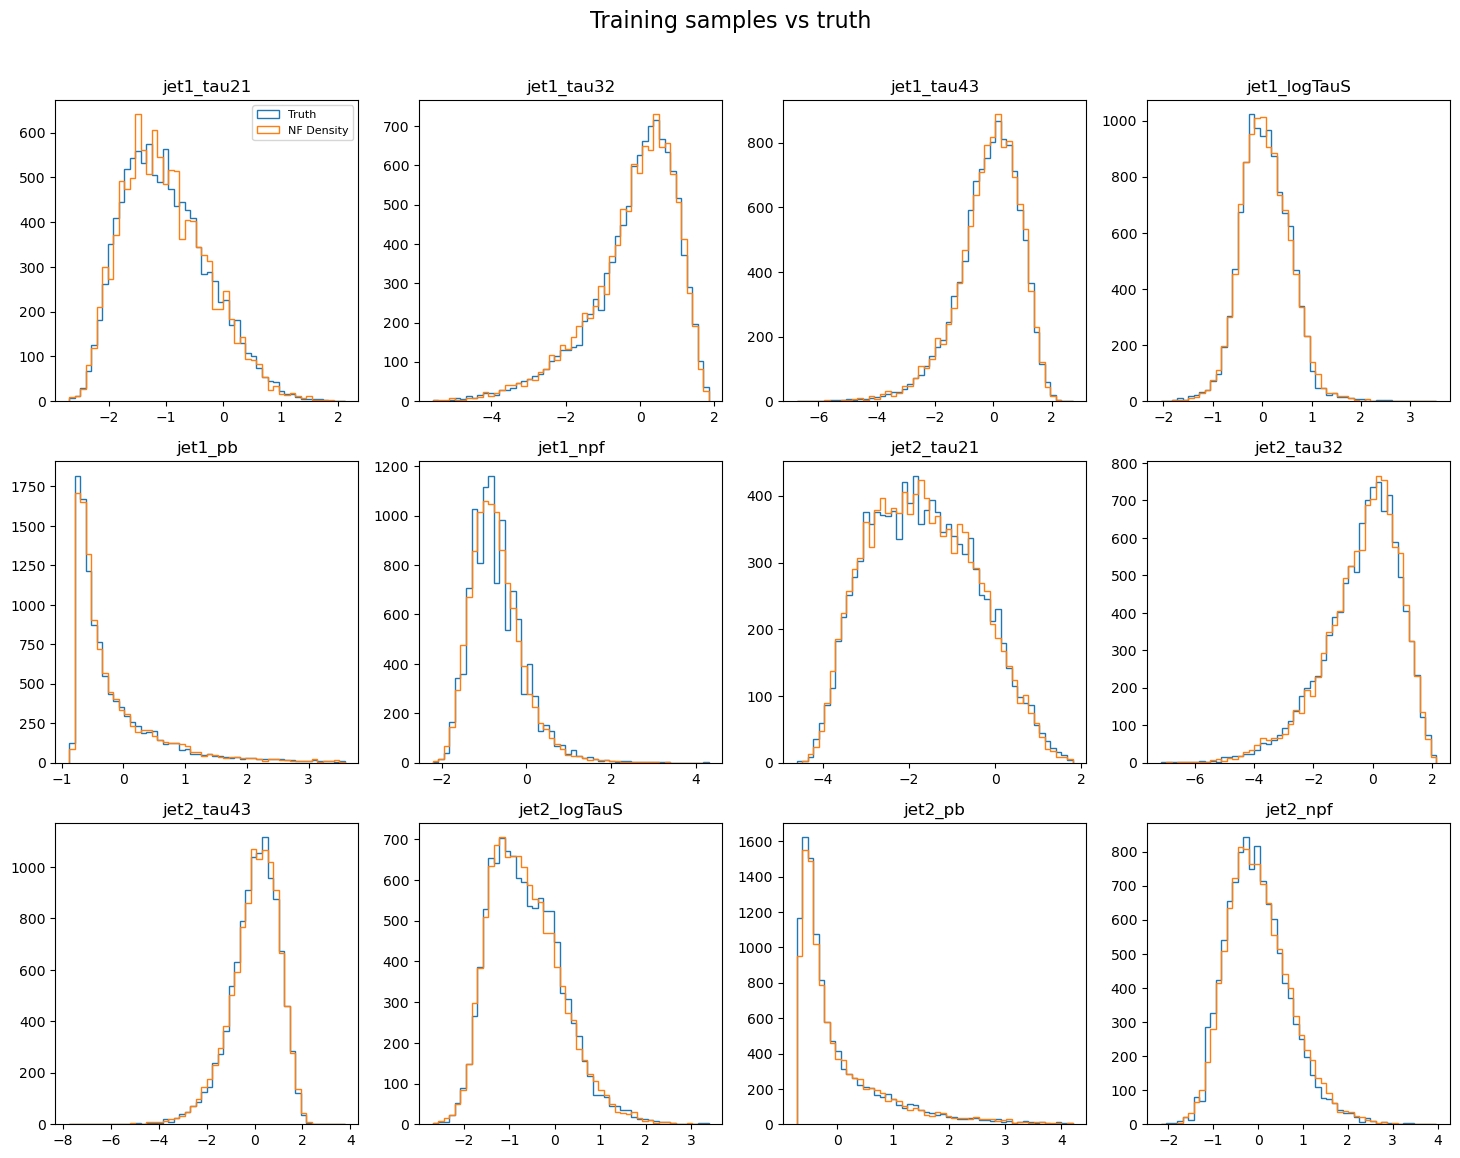

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 75.14it/s]


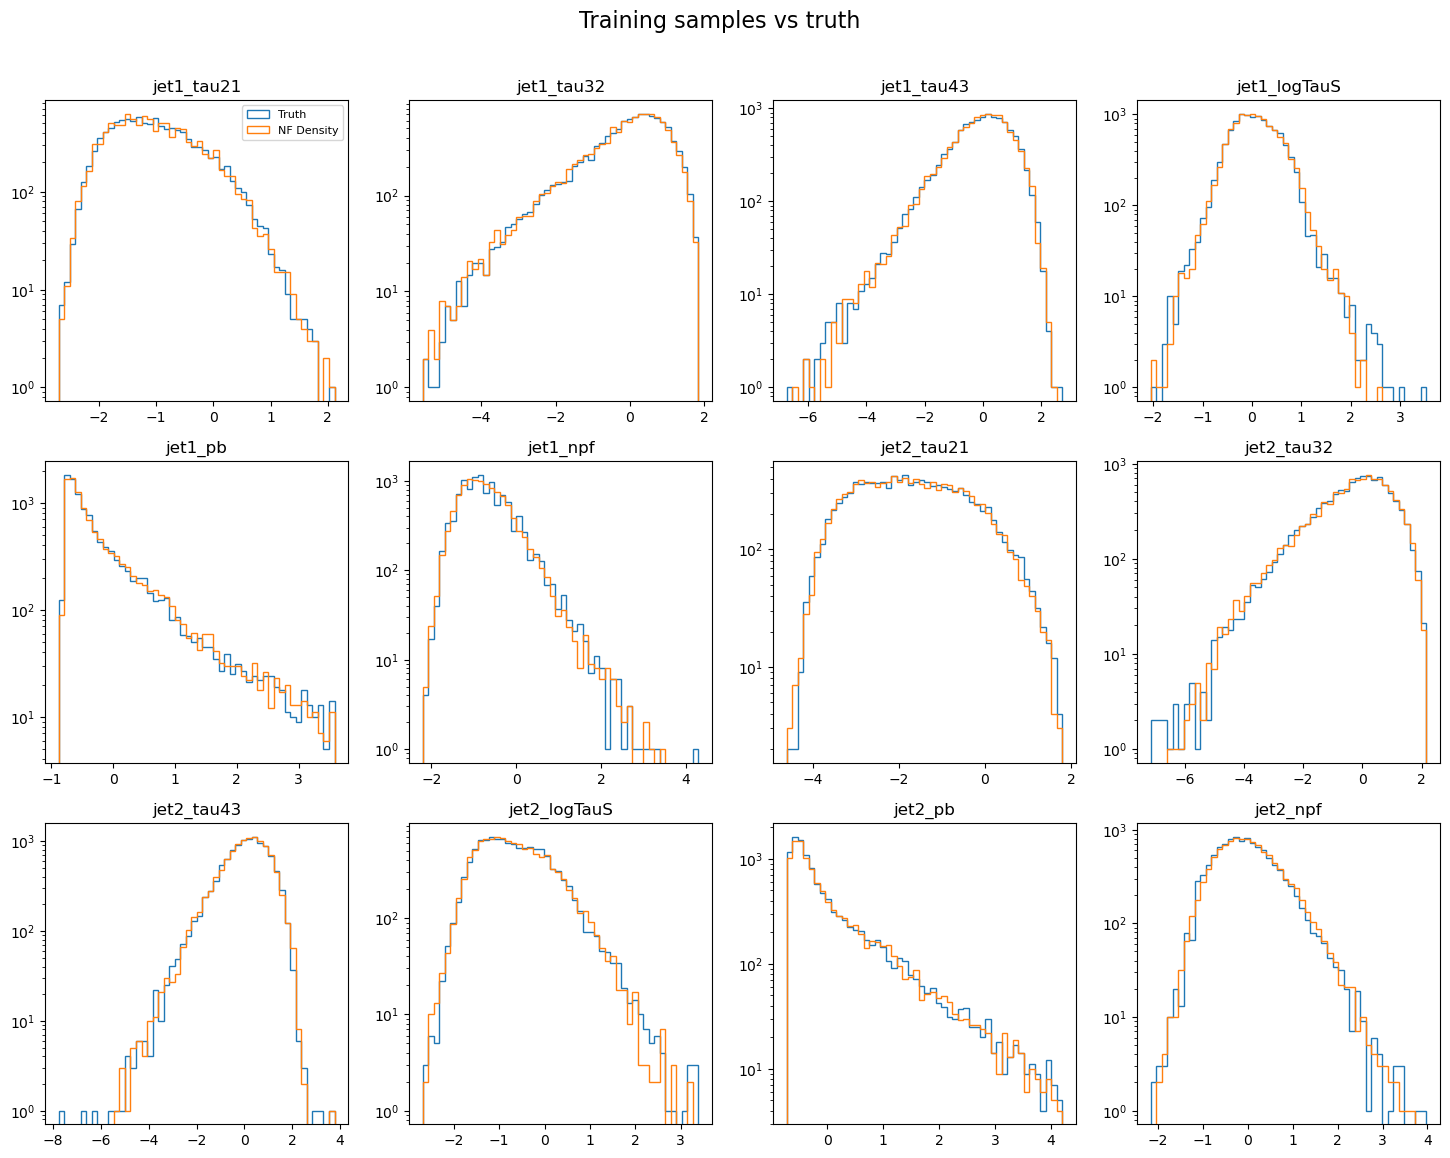

In [15]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M80-80"
modelName = "M80-80_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


100000 training events
Training flow M80-170_noRho
Iteration 10 Complete
Loss:  17.74260902404785
Iteration 20 Complete
Loss:  16.508180618286133
Iteration 30 Complete
Loss:  15.971846580505371
Iteration 40 Complete
Loss:  15.737936973571777
Iteration 50 Complete
Loss:  15.695484161376953
Iteration 60 Complete
Loss:  15.634201049804688
Iteration 70 Complete
Loss:  15.53515911102295
Iteration 80 Complete
Loss:  15.40228271484375
Iteration 90 Complete
Loss:  15.173089981079102
Iteration 100 Complete
Loss:  15.041265487670898
Iteration 110 Complete
Loss:  14.89361572265625
Iteration 120 Complete
Loss:  14.750282287597656
Iteration 130 Complete
Loss:  14.617643356323242
Iteration 140 Complete
Loss:  14.60752010345459
Iteration 150 Complete
Loss:  14.606688499450684
Iteration 160 Complete
Loss:  14.636731147766113
Iteration 170 Complete
Loss:  14.587837219238281
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 72.03it/s]


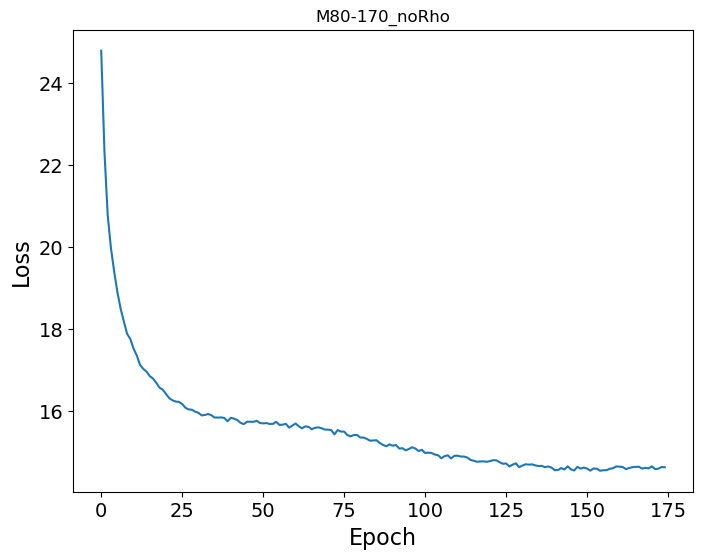

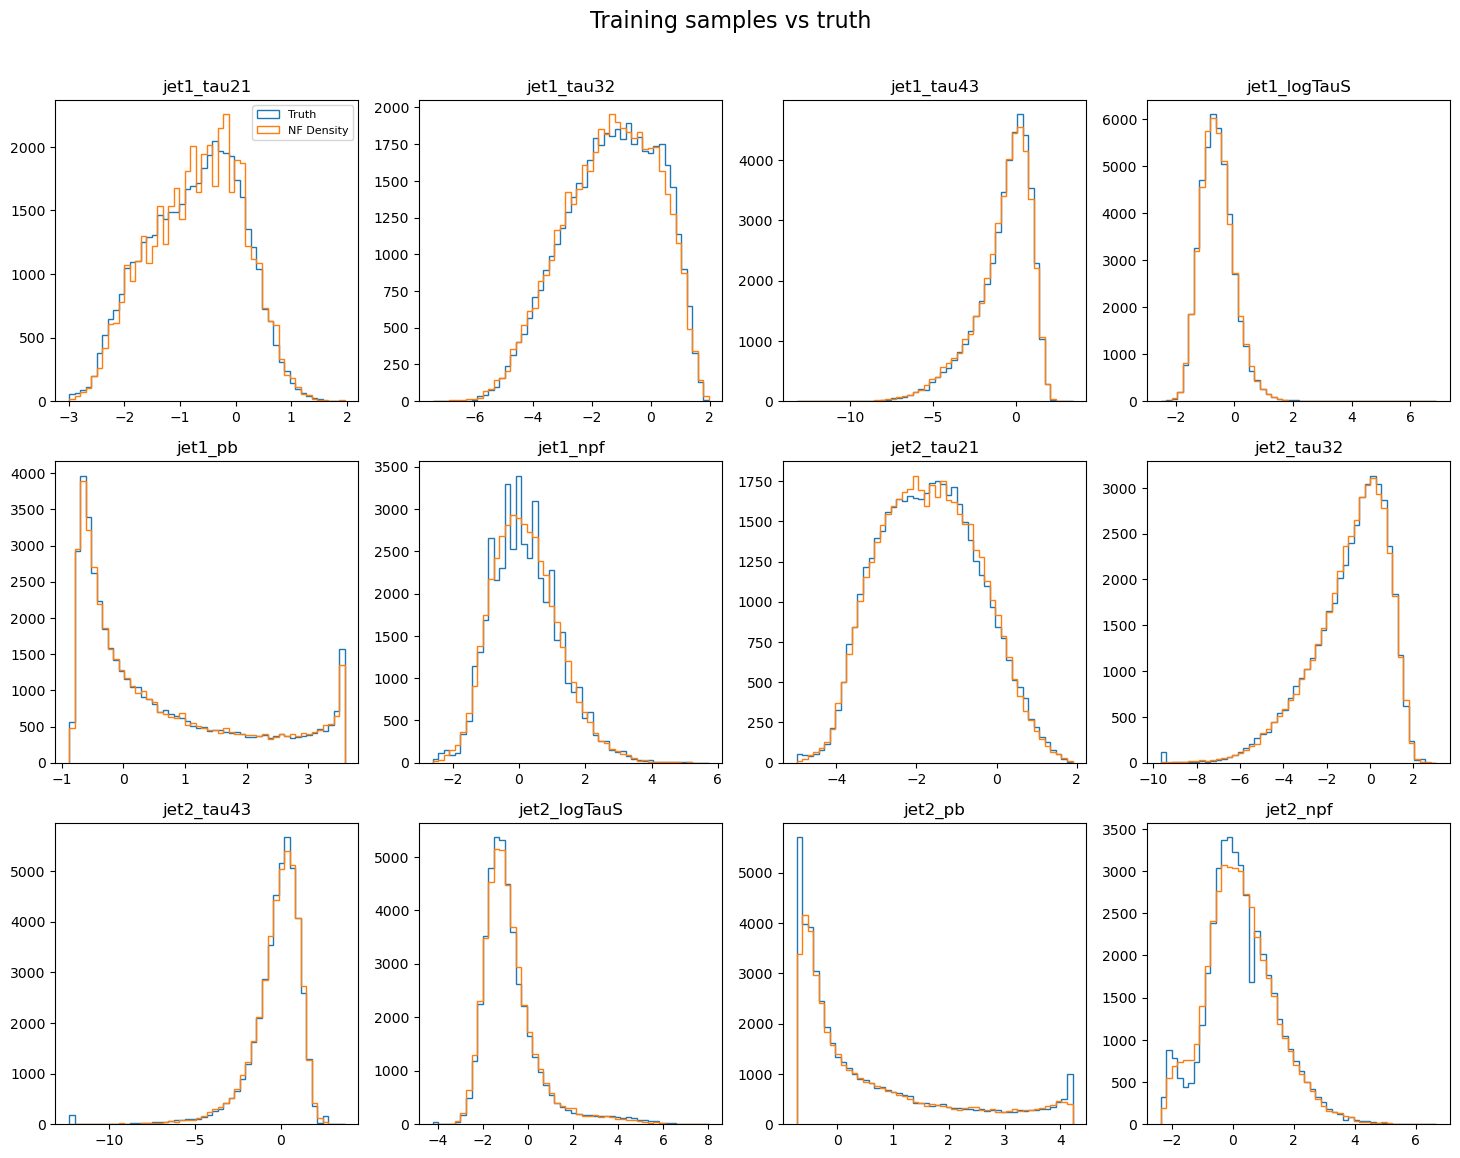

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 73.06it/s]


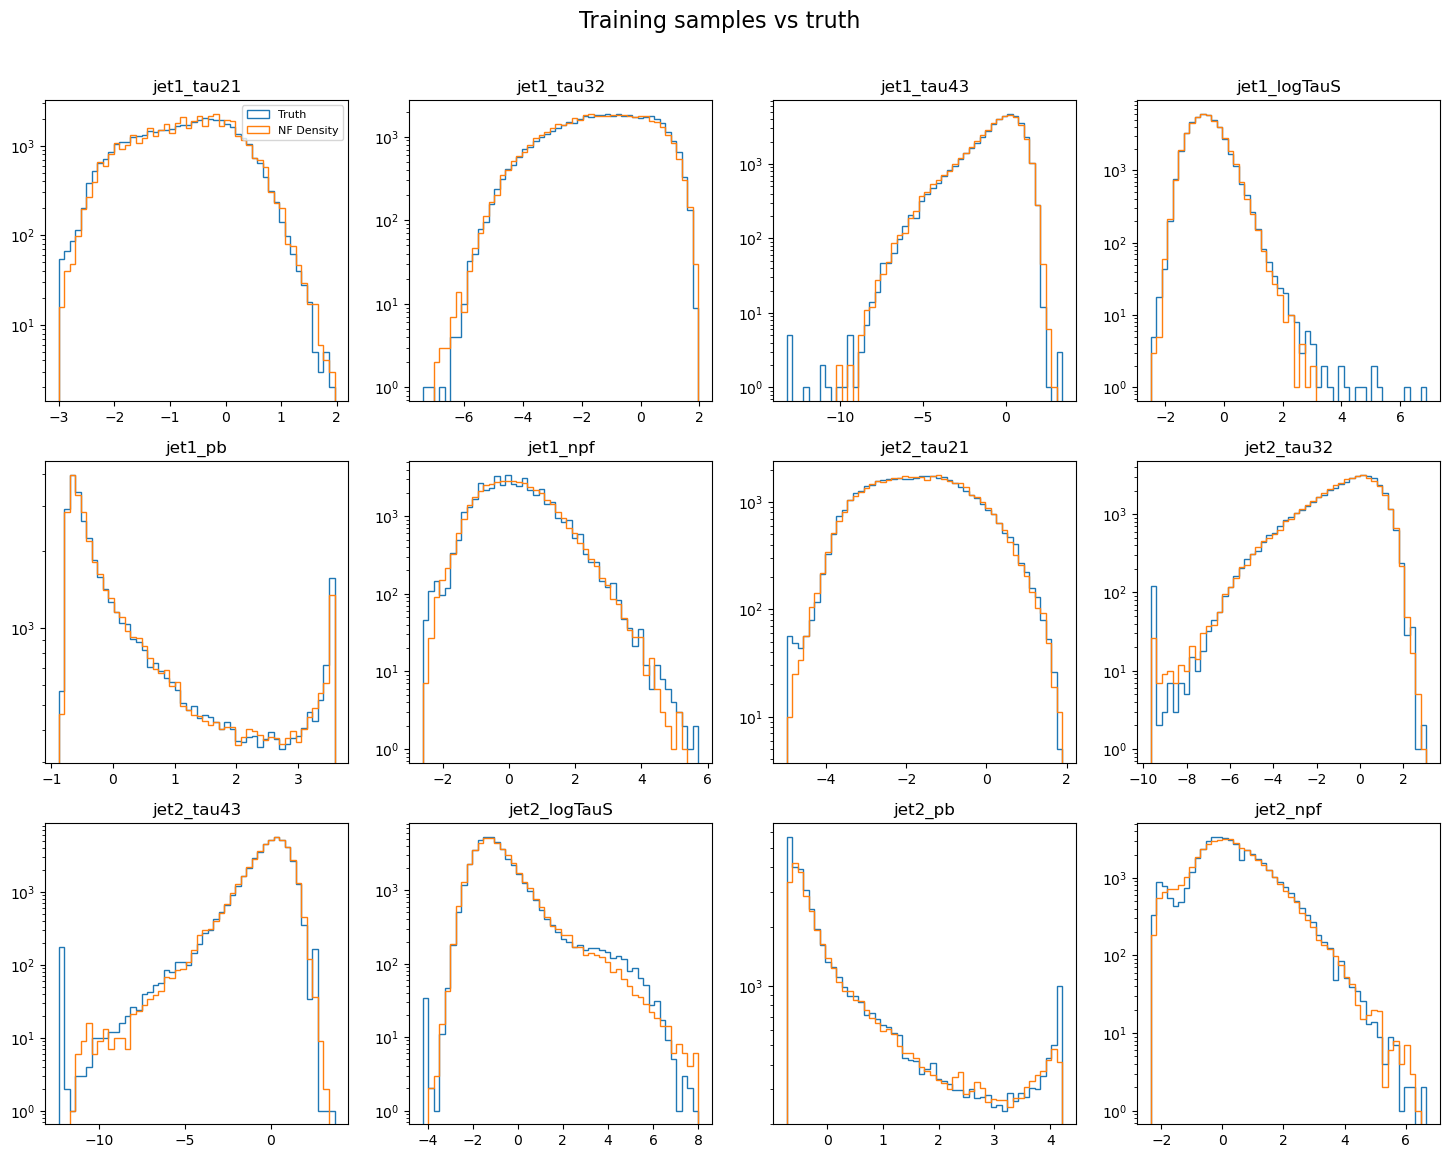

In [16]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M80-170"
modelName = "M80-170_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


100000 training events
Training flow M80-400_noRho
Iteration 10 Complete
Loss:  16.78167152404785
Iteration 20 Complete
Loss:  15.379493713378906
Iteration 30 Complete
Loss:  14.79722785949707
Iteration 40 Complete
Loss:  14.579466819763184
Iteration 50 Complete
Loss:  14.48177433013916
Iteration 60 Complete
Loss:  14.441610336303711
Iteration 70 Complete
Loss:  14.338902473449707
Iteration 80 Complete
Loss:  14.104899406433105
Iteration 90 Complete
Loss:  13.955674171447754
Iteration 100 Complete
Loss:  13.842362403869629
Iteration 110 Complete
Loss:  13.741840362548828
Iteration 120 Complete
Loss:  13.707049369812012
Iteration 130 Complete
Loss:  13.530524253845215
Iteration 140 Complete
Loss:  13.445926666259766
Iteration 150 Complete
Loss:  13.402009010314941
Iteration 160 Complete
Loss:  13.383196830749512
Iteration 170 Complete
Loss:  13.388442039489746
Iteration 180 Complete
Loss:  13.4426851272583
Iteration 190 Complete
Loss:  13.462237358093262
Loading test sample


100%|██████████| 1/1 [00:00<00:00,  9.50it/s]


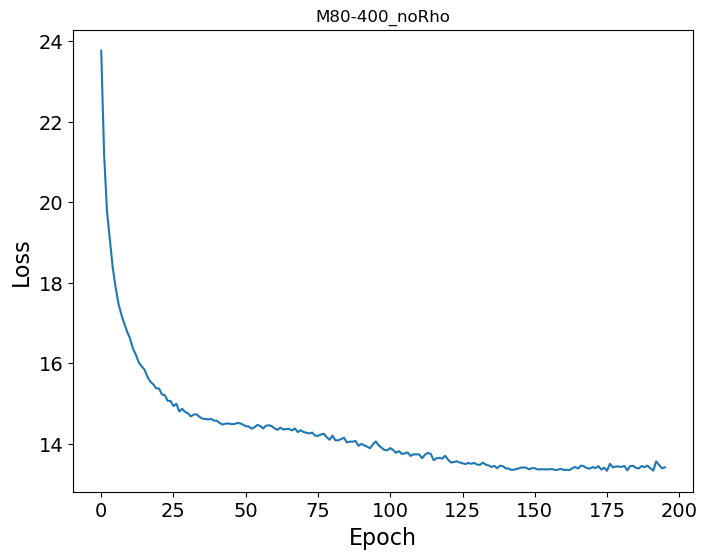

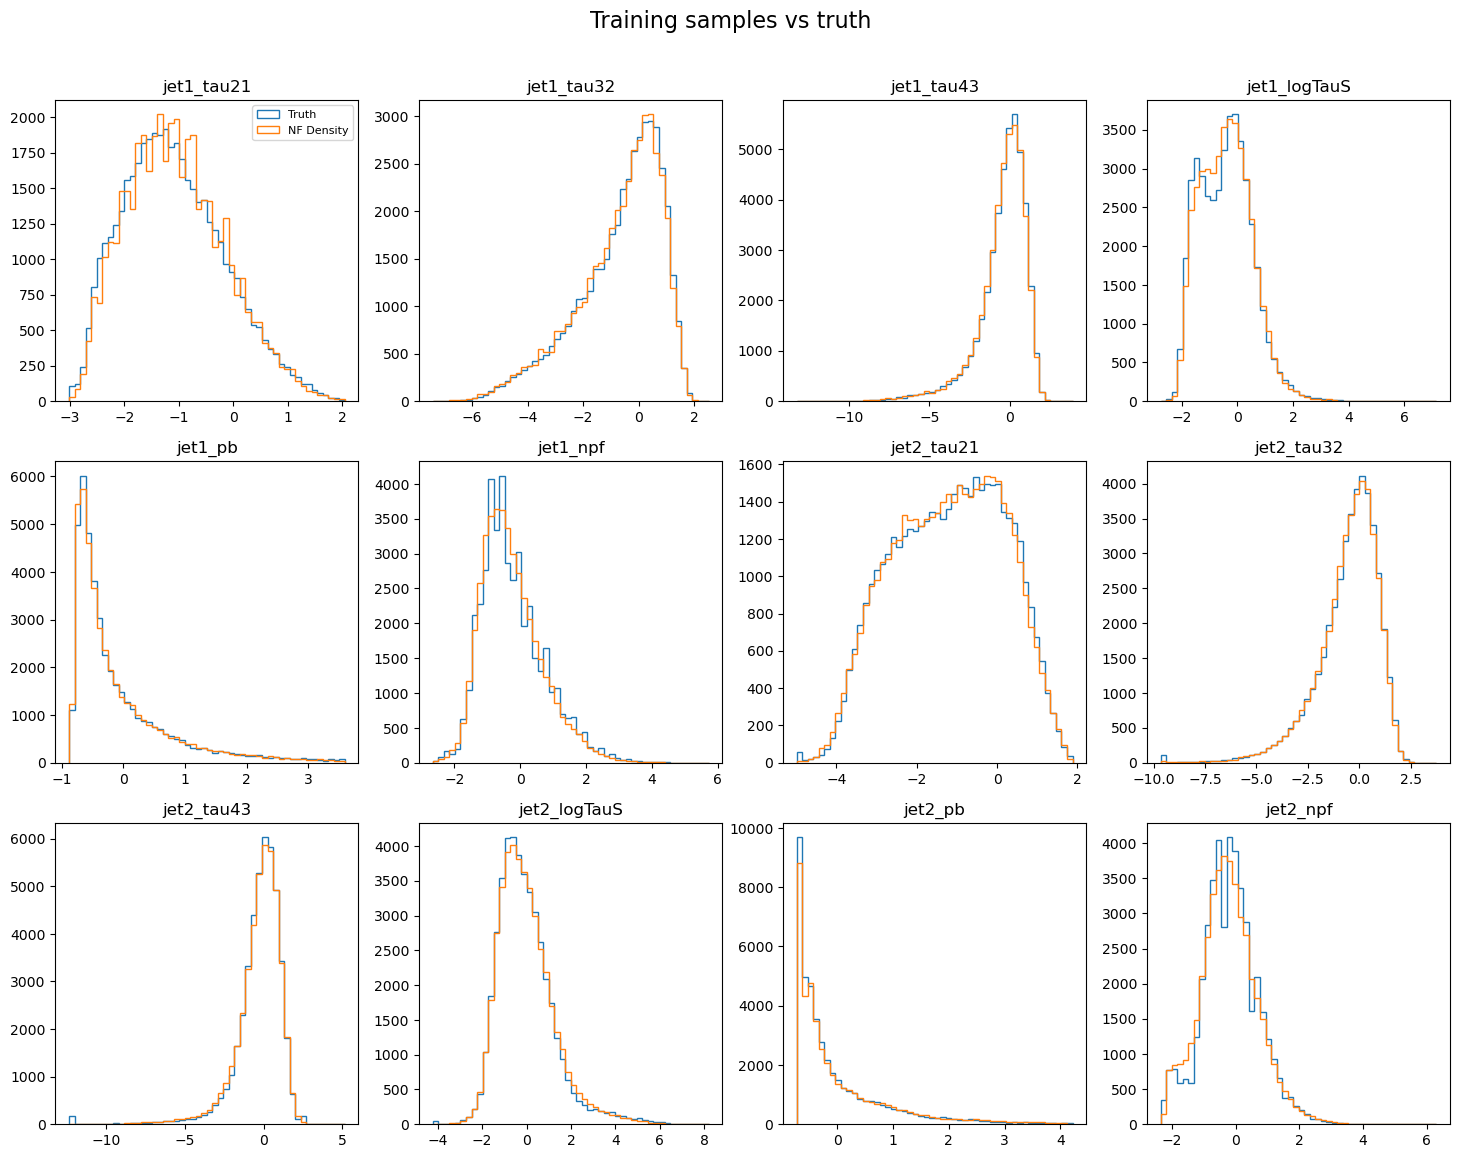

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 73.16it/s]


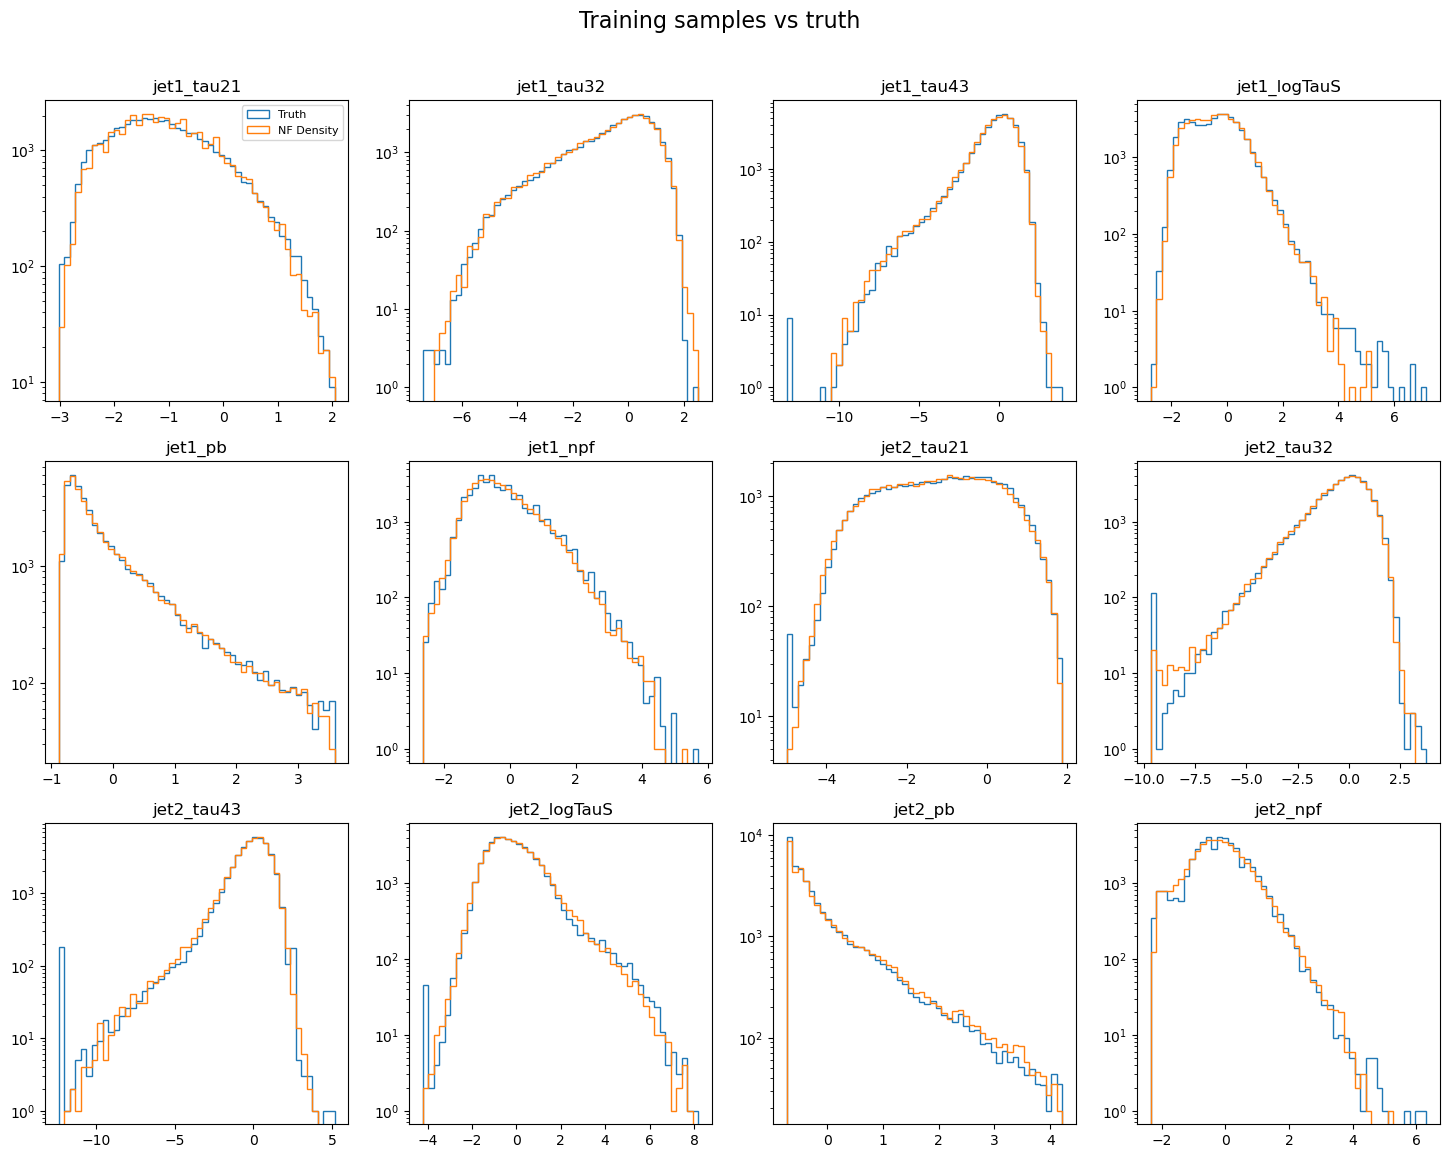

In [17]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M80-400"
modelName = "M80-400_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


99999 training events
Training flow M170-170_noRho
Iteration 10 Complete
Loss:  17.23346519470215
Iteration 20 Complete
Loss:  15.99006175994873
Iteration 30 Complete
Loss:  15.516036987304688
Iteration 40 Complete
Loss:  15.333855628967285
Iteration 50 Complete
Loss:  15.248554229736328
Iteration 60 Complete
Loss:  15.194263458251953
Iteration 70 Complete
Loss:  15.1079683303833
Iteration 80 Complete
Loss:  14.94688892364502
Iteration 90 Complete
Loss:  14.797037124633789
Iteration 100 Complete
Loss:  14.645843505859375
Iteration 110 Complete
Loss:  14.56593132019043
Iteration 120 Complete
Loss:  14.479534149169922
Iteration 130 Complete
Loss:  14.425027847290039
Iteration 140 Complete
Loss:  14.391205787658691
Iteration 150 Complete
Loss:  14.37043571472168
Iteration 160 Complete
Loss:  14.391988754272461
Iteration 170 Complete
Loss:  14.372010231018066
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 12.69it/s]


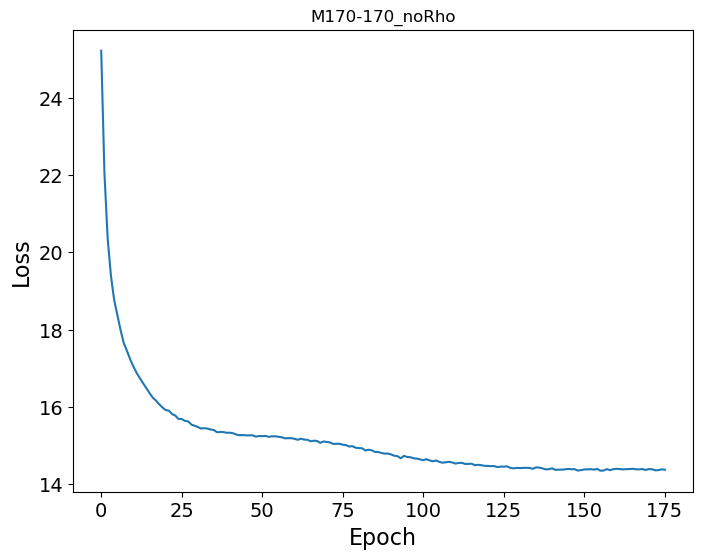

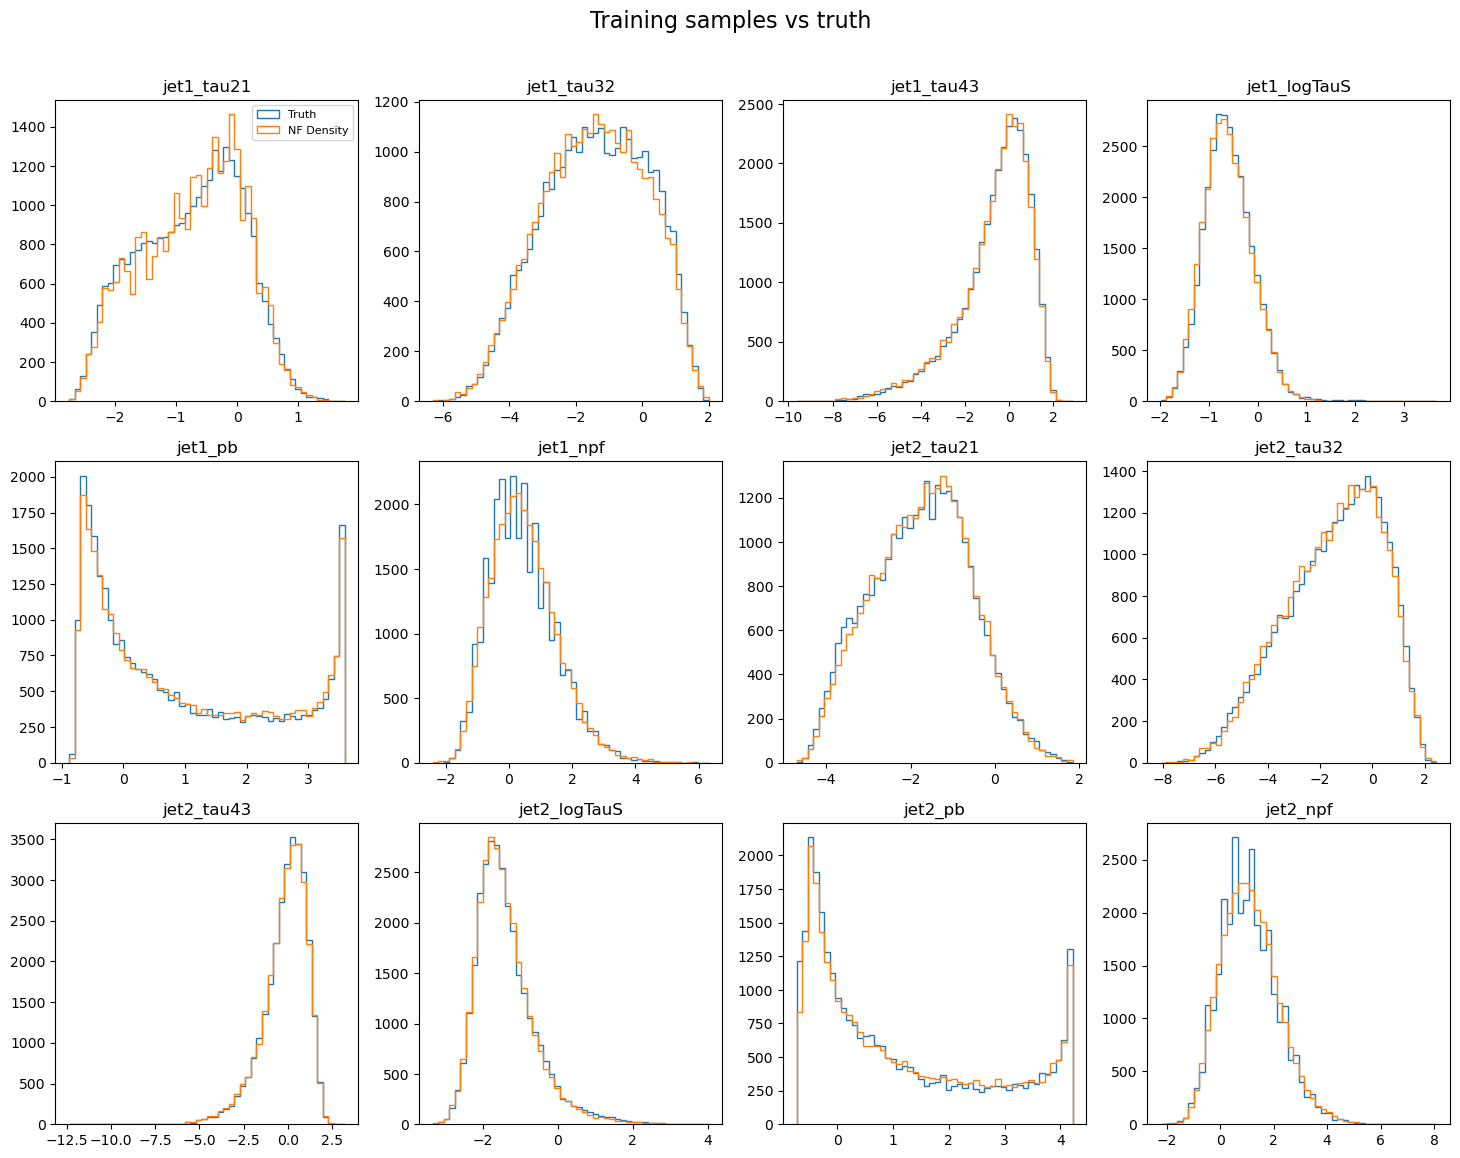

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 67.97it/s]


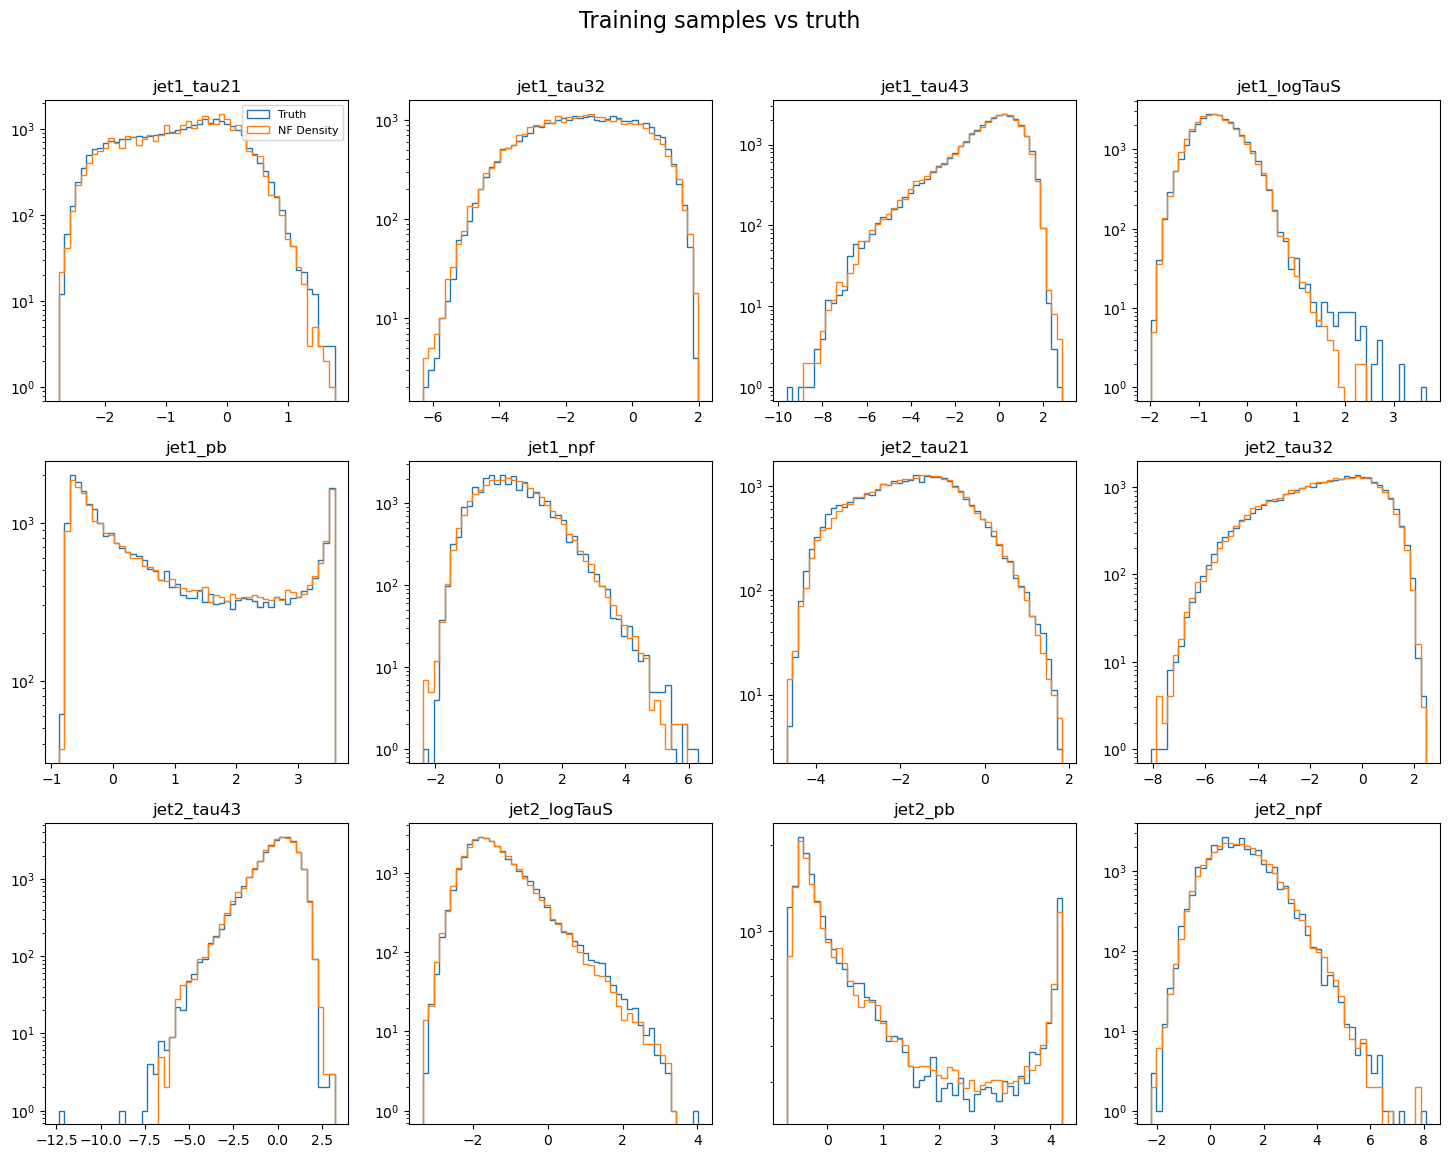

In [18]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M170-170"
modelName = "M170-170_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


100000 training events
Training flow M170-400_noRho
Iteration 10 Complete
Loss:  16.54621124267578
Iteration 20 Complete
Loss:  15.444799423217773
Iteration 30 Complete
Loss:  15.004822731018066
Iteration 40 Complete
Loss:  14.774527549743652
Iteration 50 Complete
Loss:  14.713699340820312
Iteration 60 Complete
Loss:  14.666633605957031
Iteration 70 Complete
Loss:  14.553471565246582
Iteration 80 Complete
Loss:  14.42128849029541
Iteration 90 Complete
Loss:  14.233438491821289
Iteration 100 Complete
Loss:  14.157038688659668
Iteration 110 Complete
Loss:  14.015409469604492
Iteration 120 Complete
Loss:  13.93514633178711
Iteration 130 Complete
Loss:  13.876838684082031
Iteration 140 Complete
Loss:  13.814390182495117
Iteration 150 Complete
Loss:  13.793313980102539
Iteration 160 Complete
Loss:  13.796029090881348
Iteration 170 Complete
Loss:  13.8135404586792
Iteration 180 Complete
Loss:  13.829028129577637
Iteration 190 Complete
Loss:  13.82768440246582
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 13.01it/s]


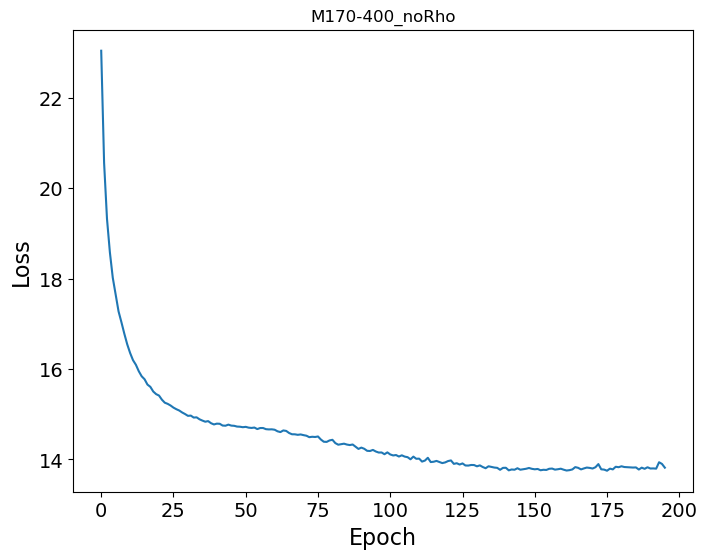

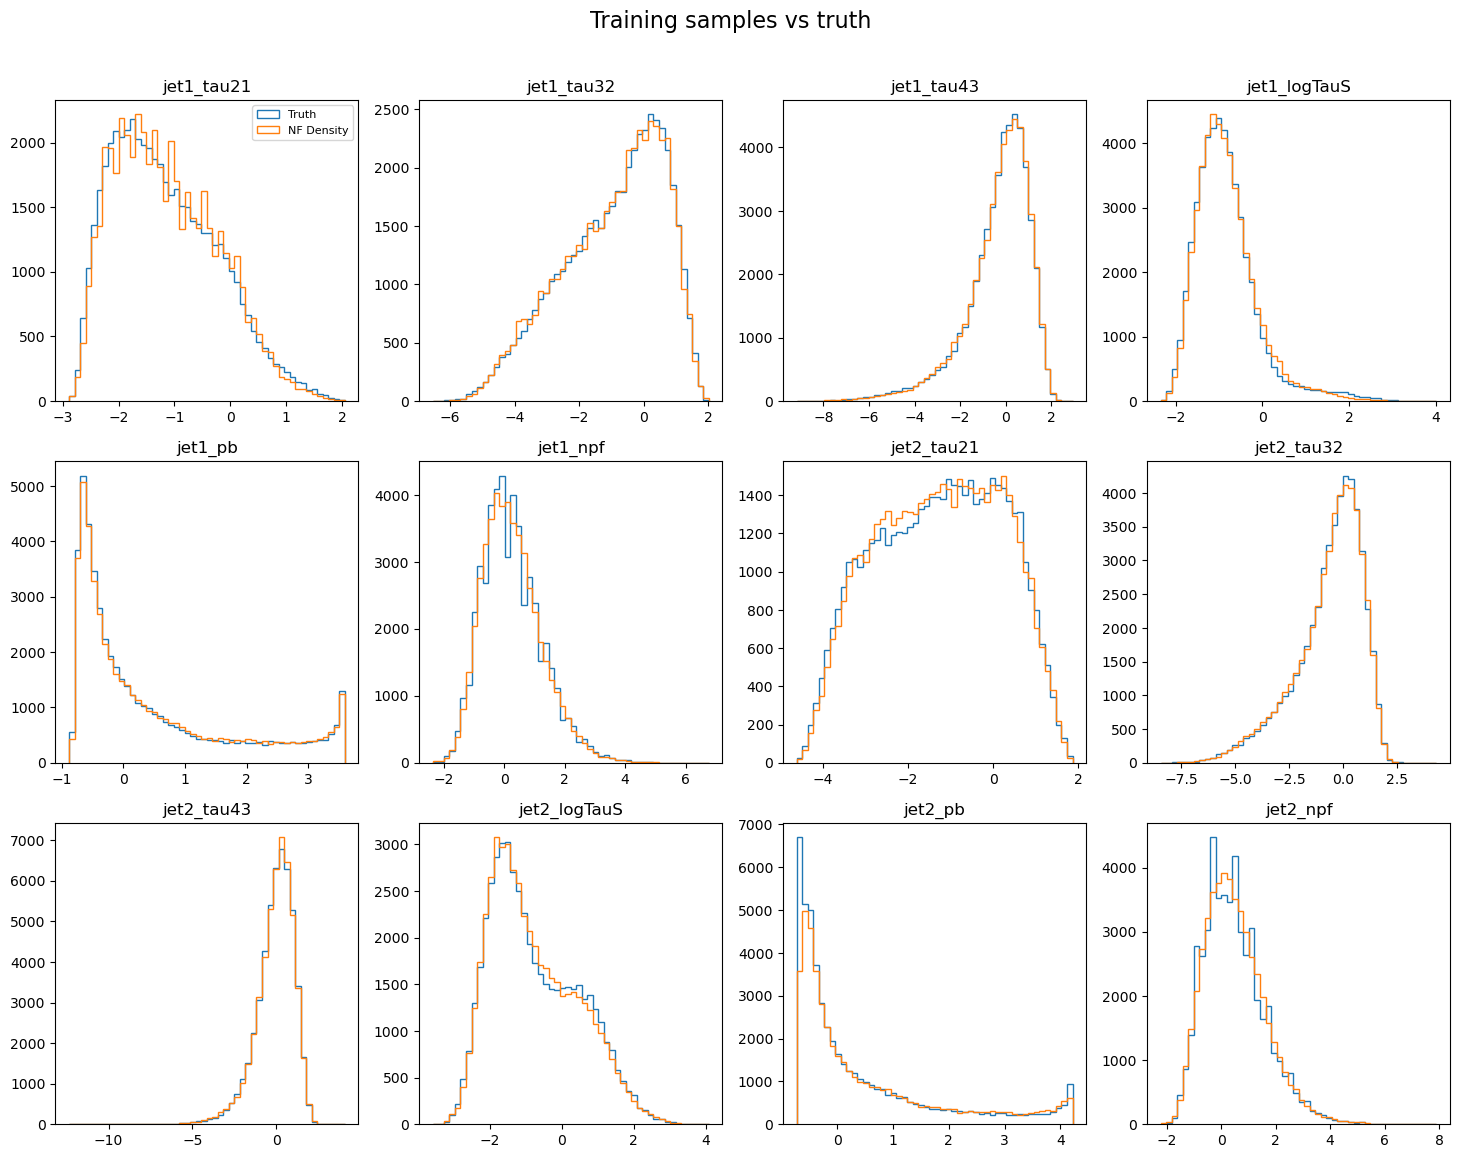

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 73.93it/s]


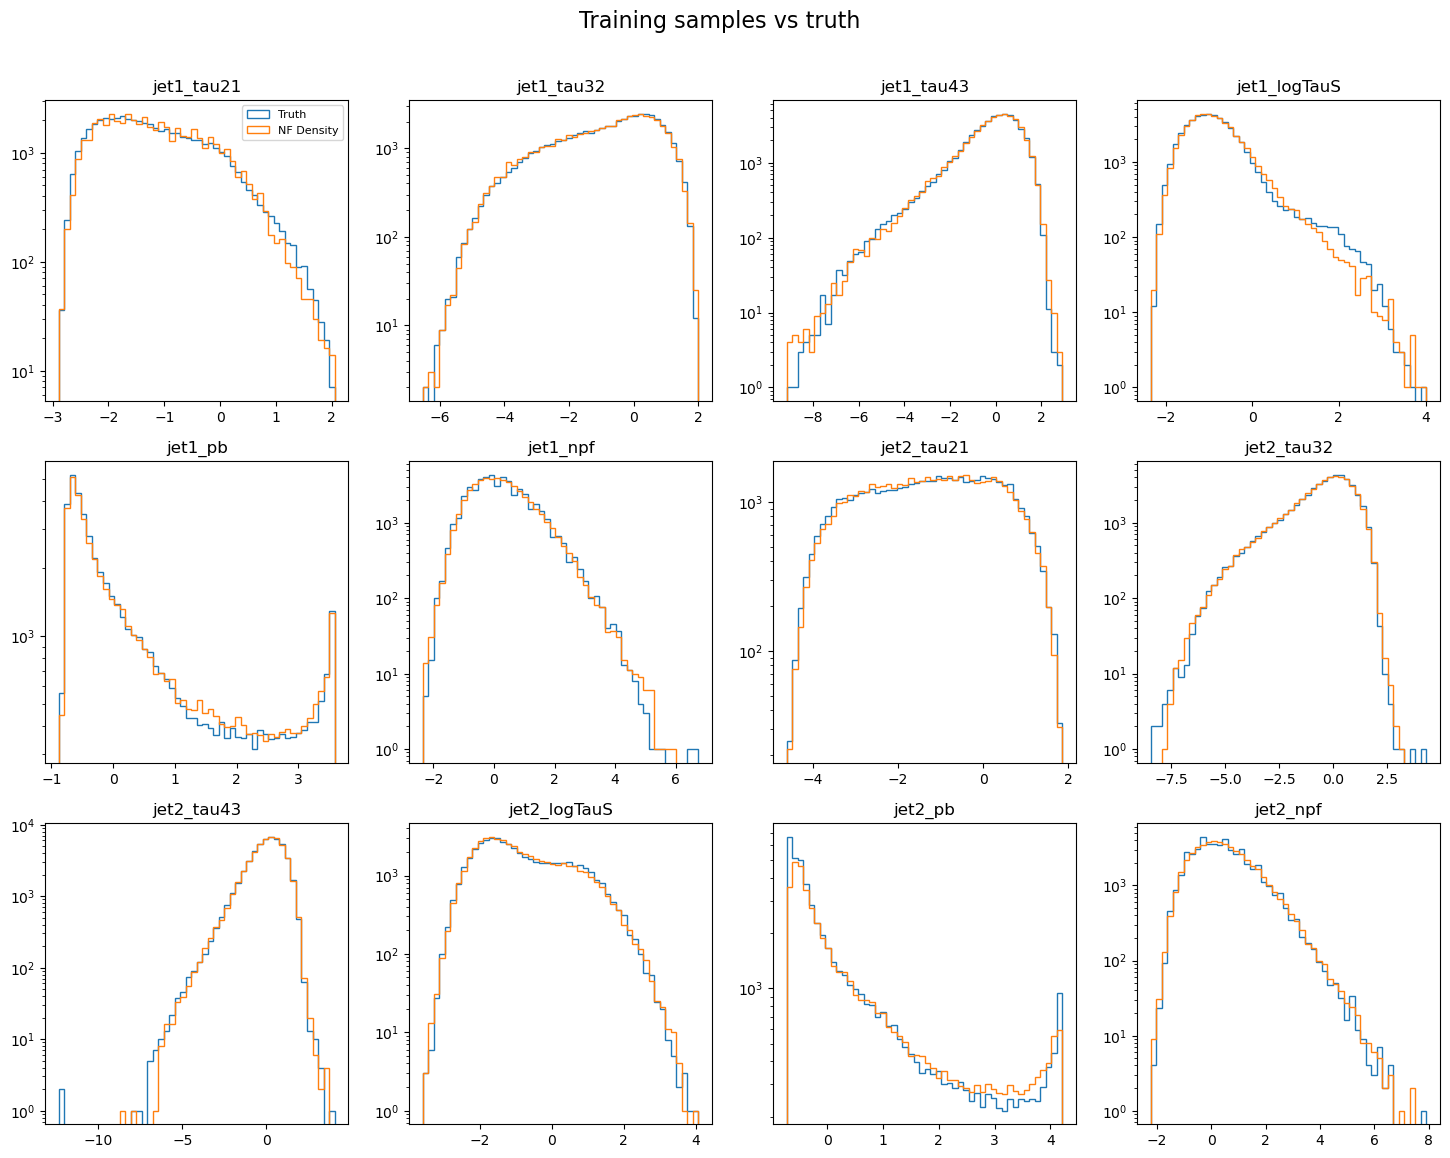

In [19]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M170-400"
modelName = "M170-400_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)

Loading train sample


  0%|          | 0/1 [00:00<?, ?it/s]


100000 training events
Training flow M400-400_noRho
Iteration 10 Complete
Loss:  18.787540435791016
Iteration 20 Complete
Loss:  17.33668327331543
Iteration 30 Complete
Loss:  16.75562858581543
Iteration 40 Complete
Loss:  16.514986038208008
Iteration 50 Complete
Loss:  16.443511962890625
Iteration 60 Complete
Loss:  16.36794662475586
Iteration 70 Complete
Loss:  16.245237350463867
Iteration 80 Complete
Loss:  16.04340362548828
Iteration 90 Complete
Loss:  15.904921531677246
Iteration 100 Complete
Loss:  15.733880996704102
Iteration 110 Complete
Loss:  15.65625286102295
Iteration 120 Complete
Loss:  15.538867950439453
Iteration 130 Complete
Loss:  15.504449844360352
Iteration 140 Complete
Loss:  15.47175407409668
Iteration 150 Complete
Loss:  15.465059280395508
Iteration 160 Complete
Loss:  15.4592866897583
Iteration 170 Complete
Loss:  15.464099884033203
Iteration 180 Complete
Loss:  15.453487396240234
Loading test sample


100%|██████████| 1/1 [00:00<00:00, 11.58it/s]


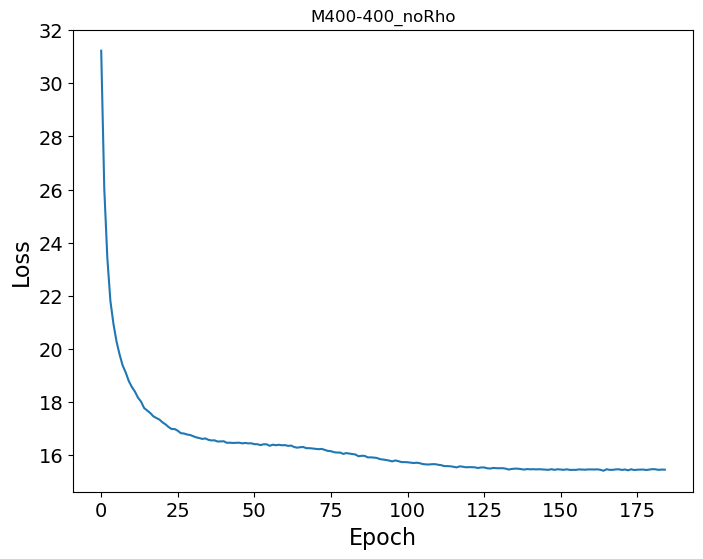

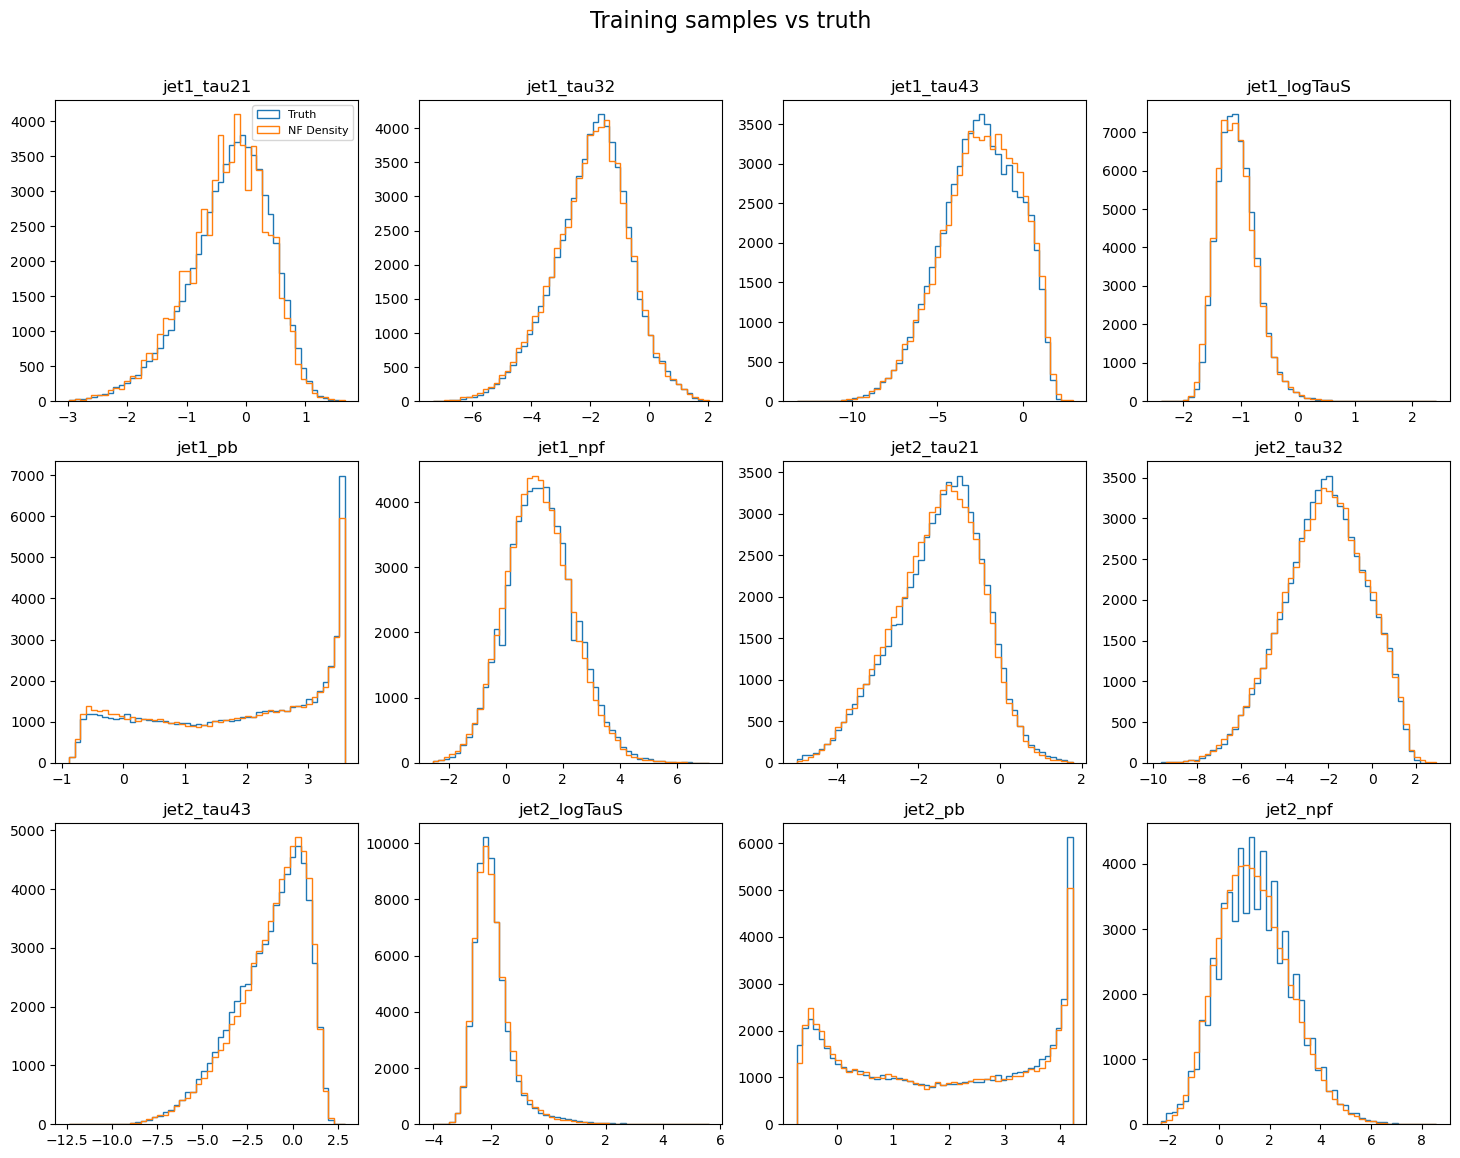

Loading test sample


100%|██████████| 1/1 [00:00<00:00, 53.83it/s]


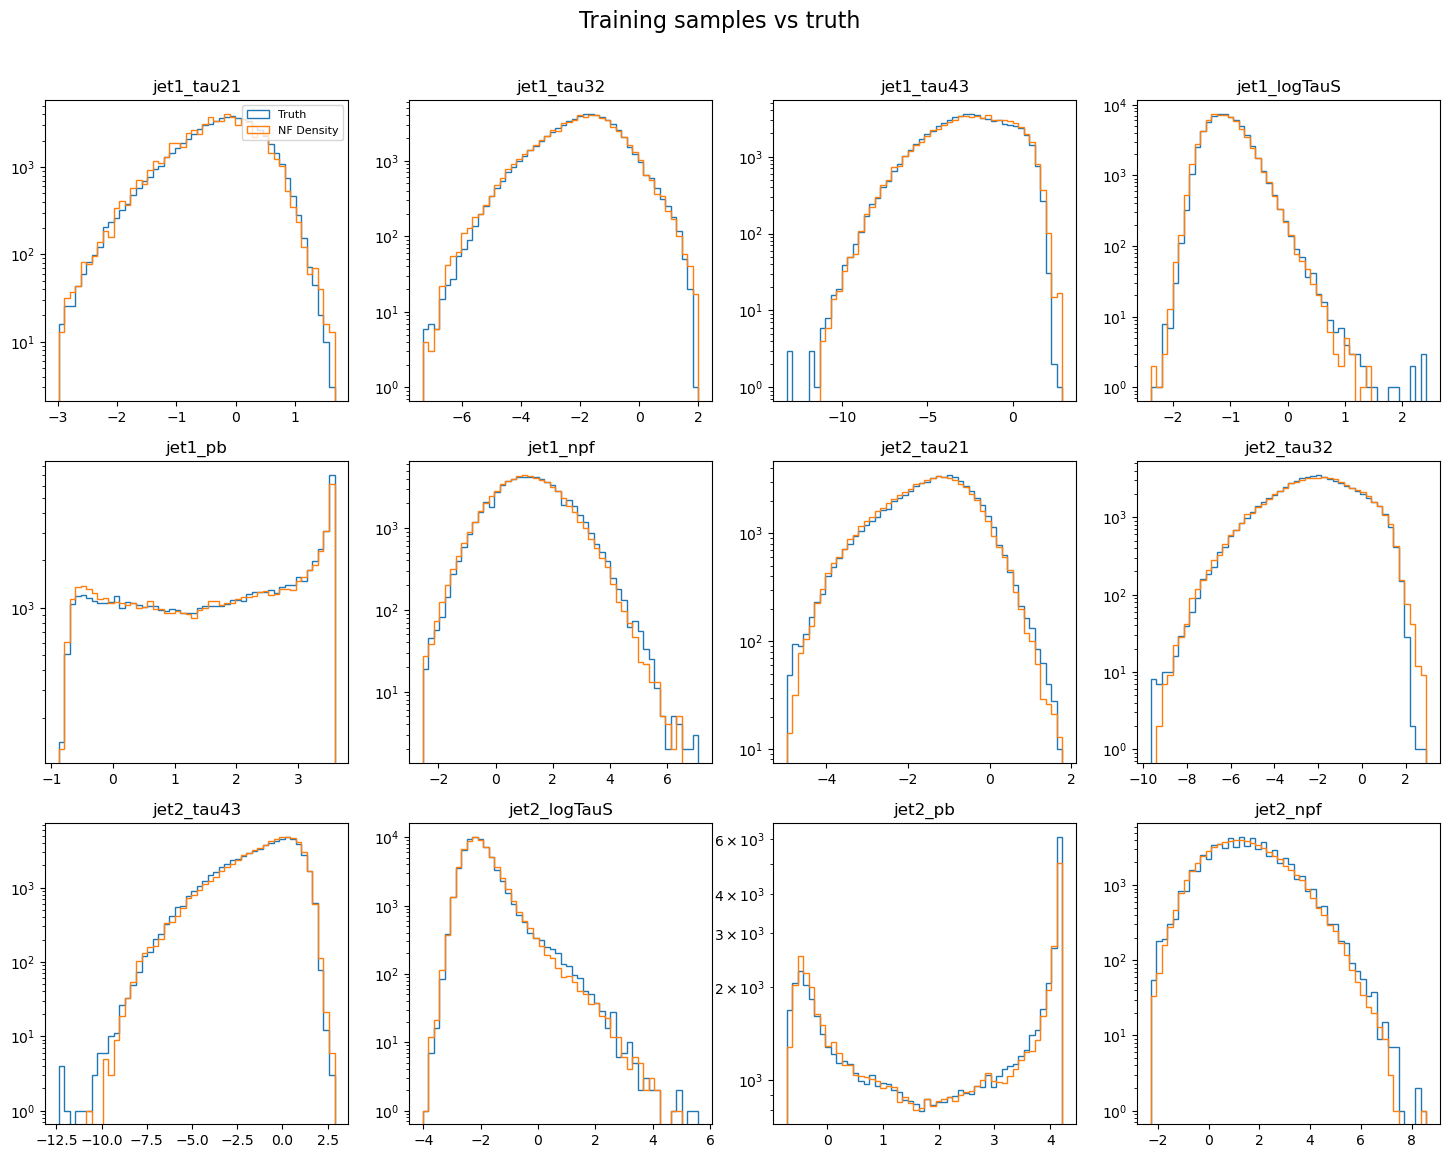

In [20]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":12,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}

flowName = "M400-400"
modelName = "M400-400_noRho"
sample = daughterGroups_2and3TeV[flowName]
reference = "BKG"
variables = ['jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    dEta_cut=-1,sideband=False,
                    modelName=modelName)
trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
              print_interval=10,T_max=50,eta_min=1e-5)
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)